# Bitcoin OTC İşaretli Güven Ağında Kenar Ağırlığı Tahmini

| Teslim alanı | Bilgi |
|---|---|
| Ders | BİL403 Sosyal Ağlar (Social Networks) |
| Öğrenci | Hüseyin Arda Tuz |
| Öğrenci numarası | 221404032 |
| Bölüm | Department of Artificial Intelligence |
| Üniversite | TOBB University of Economics and Technology |
| Konum | Ankara, Türkiye |
| E-posta | h.tuz@etu.edu.tr |
| Sınıf | 4 |

Bu not defteri, P0 kapsamının tek ve bağımsız yürütülebilir çekirdeğidir. Amaç,
gözlendiği bilinen yönlü bir Bitcoin OTC güven kenarının normalize ağırlığını
tahmin etmektir; bağlantı tahmini, kripto para fiyat tahmini, yatırım tavsiyesi
veya doğrulanmış sahtekârlık tespiti değildir.

Kaynak kodu iki değişmez çalışma kipini destekler:

- `pretest`: G8 test öncesi prova; yalnız eğitim/doğrulama varlıkları, test hücreleri atlanır.
- `verification_rerun`: G10 temiz çekirdek yeniden üretimi; G9 kilidiyle aynı bilimsel hesaplar tekrarlanır, yeni karar üretilmez.

Doğrudan **Run All** ortam değişkeni verilmeden çalıştırılırsa güvenli `pretest`
kipi seçilir. Eksik ara varlıklar kanonik CSV'den yeniden üretilir; kilitli test
hücresi açıklayıcı bir iletiyle atlanır ve test hedefleri okunmaz.


In [1]:
from __future__ import annotations
# Bu hücre, not defterinin ortak kütüphanelerini ve çalışma ayarlarını hazırlar.

import ast
from hashlib import sha256
import json
import os
from pathlib import Path
import platform
import sys
import time

# Sayısal hesaplama, tablo işleme ve sonuçları gösterme araçları burada yüklenir.
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# Çalışma kipi, test verisine erişilip erişilemeyeceğini güvenli biçimde belirler.
MODE_WAS_EXPLICIT = "BITCOIN_OTC_NOTEBOOK_MODE" in os.environ
MODE = os.environ.get("BITCOIN_OTC_NOTEBOOK_MODE", "pretest")
if MODE not in {"pretest", "verification_rerun"}:
    raise ValueError(f"Desteklenmeyen not defteri kipi: {MODE}")
TEST_ACCESS_ALLOWED = MODE == "verification_rerun"
ORCHESTRATED_RUN = os.environ.get("BITCOIN_OTC_NOTEBOOK_ORCHESTRATED") == "1"
SAFE_DIRECT_RUN = not ORCHESTRATED_RUN
# Sabit tohum, aynı işlemlerin her çalıştırmada aynı sonucu vermesine yardımcı olur.
np.random.seed(403)

# Proje kökü, not defteri farklı bir klasörden açılsa da gerekli dosyaları bulmak için aranır.
def locate_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "soc-sign-bitcoinotc.csv").is_file()
        ):
            return candidate
    raise RuntimeError("Proje kökü bulunamadı.")

PROJECT_ROOT = locate_project_root(Path.cwd())
NOTEBOOK_RELATIVE_PATH = Path("projekod_221404032_Hüseyin_Arda_Tuz.ipynb")
RUN_STARTED = time.perf_counter()
# Bu sözlük, kullanılan ortamın kısa ve denetlenebilir bir özetini saklar.
environment = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "mode": MODE,
    "mode_was_explicit": MODE_WAS_EXPLICIT,
    "orchestrated_run": ORCHESTRATED_RUN,
    "safe_direct_run": SAFE_DIRECT_RUN,
    "seed": 403,
    "project_root_display": ".",
    "test_access_allowed": TEST_ACCESS_ALLOWED,
}
environment


{'python': '3.13.1',
 'platform': 'Linux-7.0.0-28-generic-x86_64-with-glibc2.39',
 'mode': 'verification_rerun',
 'mode_was_explicit': True,
 'orchestrated_run': True,
 'safe_direct_run': False,
 'seed': 403,
 'project_root_display': '.',
 'test_access_allowed': True}

## 2. Veri kaynağı, anlam ve akademik bağlam

SNAP Bitcoin OTC verisinde her kayıt `SOURCE,TARGET,RATING,TIME` biçiminde
yönlü, işaretli, ağırlıklı ve zaman damgalı bir güven değerlendirmesidir.
Hedef `rating / 10` ile `[-1,1]` aralığına taşınır. Kumar ve arkadaşlarının FGA
yöntemi tam graf üzerinde doğrudan yeniden üretilir; rastgele deney kısmi
yeniden üretim, zamansal deney ise yeni uzantıdır.


## 3–5. Gömülü bilimsel çekirdek ve veri sözleşmesi

Aşağıdaki hücrelerde veri doğrulama, FGA, 28 özellik, bölmeler, sabit modeller,
metrikler ve görseller fiziksel olarak bu not defterine gömülüdür. Çalışma
zamanında proje-yerel `src` paketi veya `%run` kullanılmaz.


In [2]:
# Gömülü çekirdek: src/bitcoin_otc/config.py
# Bu hücre, proje boyunca değiştirilmeden kullanılan kuralları ve sabitleri bir arada tutar.
from dataclasses import dataclass
from enum import Enum
from hashlib import sha256
import json
from pathlib import Path
from types import MappingProxyType
from typing import Any, Final, Mapping
# Sürüm, kapsam, rastgelelik tohumu ve veri kaynağı burada sabitlenir.
SPECIFICATION_VERSION: Final = '1.0'
PROJECT_SCOPE: Final = 'P0'
SEED: Final = 403
OFFICIAL_DATA_URL: Final = 'https://snap.stanford.edu/data/soc-sign-bitcoinotc.csv.gz'
COMPRESSED_DATA_SHA256: Final = '6424ac981dad3a019f697fc1b9fcd85c19d8d9f039797758e9ffb6fea100c373'
CSV_DATA_SHA256: Final = '76bd9d8f1d3ff9a1813d9fc8e6902a0ee4d0a2f8c1003842dbc9ec79149ab60c'
# Beklenen kayıt ve düğüm sayıları, yanlış veri dosyası kullanılmasını önler.
CANONICAL_RECORD_COUNT: Final = 35592
CANONICAL_NODE_COUNT: Final = 5881
CANONICAL_POSITIVE_EDGE_COUNT: Final = 32029
CANONICAL_NEGATIVE_EDGE_COUNT: Final = 3563
FIRST_TIMESTAMP_US: Final = 1289241911728360
# Bu sınırlar, eğitim, doğrulama ve test kayıtlarının sayılarını belirler.
Q_0_0: Final = 0
Q_0_1: Final = 3559
Q_0_2: Final = 7118
Q_0_3: Final = 10677
Q_0_4: Final = 14236
Q_0_5: Final = 17796
Q_0_6: Final = 21355
Q_0_7: Final = 24914
Q_0_8: Final = 28473
Q_1_0: Final = 35592
SPLIT_BOUNDARIES: Final[Mapping[str, int]] = MappingProxyType({'q_0_0': Q_0_0, 'q_0_1': Q_0_1, 'q_0_2': Q_0_2, 'q_0_3': Q_0_3, 'q_0_4': Q_0_4, 'q_0_5': Q_0_5, 'q_0_6': Q_0_6, 'q_0_7': Q_0_7, 'q_0_8': Q_0_8, 'q_1_0': Q_1_0})
OUTER_SPLIT_SIZES: Final[Mapping[str, int]] = MappingProxyType({'train': Q_0_7, 'validation': Q_0_8 - Q_0_7, 'test': Q_1_0 - Q_0_8})
RANDOM_CROSS_FIT_FOLDS: Final = 5
TEMPORAL_BURN_IN_SIZE: Final = Q_0_1
TEMPORAL_VALIDATION_TRAIN_LABELS: Final = Q_0_7 - Q_0_1
TEMPORAL_FINAL_TRAIN_LABELS: Final = Q_0_8 - Q_0_1
SPLIT_SCHEMA_VERSION: Final = 'p0-v1'
# Modelin göreceği 28 özelliğin adı ve sırası burada açıkça tanımlanır.
FEATURE_COLUMNS: Final[tuple[str, ...]] = ('f_source', 'g_source', 'f_target', 'g_target', 'fxg', 'source_out_log_degree', 'source_out_log_positive_degree', 'source_out_log_negative_degree', 'source_out_mean_rating', 'source_in_log_degree', 'source_in_log_positive_degree', 'source_in_log_negative_degree', 'source_in_mean_rating', 'target_out_log_degree', 'target_out_log_positive_degree', 'target_out_log_negative_degree', 'target_out_mean_rating', 'target_in_log_degree', 'target_in_log_positive_degree', 'target_in_log_negative_degree', 'target_in_mean_rating', 'reciprocal_exists', 'reciprocal_rating', 'log_two_path_count', 'mean_path_product', 'positive_path_product_ratio', 'source_has_out_history', 'target_has_in_history')
FEATURE_SCHEMA_VERSION: Final = 'p0-28-v1'
# FGA hesabının başlangıç değerleri ve durma koşulları bu bölümde sabitlenir.
FGA_INITIAL_FAIRNESS: Final = 1.0
FGA_INITIAL_GOODNESS: Final = 1.0
FGA_COLD_SOURCE_FAIRNESS: Final = 1.0
FGA_COLD_TARGET_GOODNESS: Final = 0.0
FGA_TOLERANCE: Final = 0.001
FGA_MAX_ITERATIONS: Final = 100
FGA_PARAMETERS: Final[Mapping[str, Any]] = MappingProxyType({'initial_fairness': FGA_INITIAL_FAIRNESS, 'initial_goodness': FGA_INITIAL_GOODNESS, 'cold_source_fairness': FGA_COLD_SOURCE_FAIRNESS, 'cold_target_goodness': FGA_COLD_TARGET_GOODNESS, 'tolerance_l1': FGA_TOLERANCE, 'max_iterations': FGA_MAX_ITERATIONS, 'dtype': 'float64', 'update_order': 'new_goodness_then_fairness_with_new_goodness'})
# Ridge ve HGB modelleri için kullanılacak ayarlar deney başlamadan önce belirlenmiştir.
RIDGE_SCALER_PARAMETERS: Final[Mapping[str, Any]] = MappingProxyType({'with_mean': True, 'with_std': True})
RIDGE_PARAMETERS: Final[Mapping[str, Any]] = MappingProxyType({'alpha': 1.0, 'fit_intercept': True, 'solver': 'lsqr', 'tol': 1e-08, 'max_iter': 10000})
HGB_PARAMETERS: Final[Mapping[str, Any]] = MappingProxyType({'loss': 'squared_error', 'learning_rate': 0.05, 'max_iter': 200, 'max_leaf_nodes': 15, 'min_samples_leaf': 30, 'l2_regularization': 1.0, 'early_stopping': False, 'random_state': SEED})
# Tahmin aralığı, model seçim kuralı ve toplam model uyumu bütçesi burada korunur.
PREDICTION_CLIP_MIN: Final = -1.0
PREDICTION_CLIP_MAX: Final = 1.0
MODEL_SELECTION_RMSE_TIE_TOLERANCE: Final = 0.005
P0_VALIDATION_FIT_BUDGET: Final = 4
P0_FINAL_FIT_BUDGET: Final = 4
P0_SUPERVISED_FIT_BUDGET: Final = 8

# Çalışma profili, hızlı deneme çıktılarını standart sonuçlardan ayrı tutar.
class RunProfile(str, Enum):
    """Artifact namespace; smoke outputs can never overwrite standard ones."""
    SMOKE = 'smoke'
    STANDARD = 'standard'

class RunMode(str, Enum):
    """Permitted test-access modes from the binding execution contract."""
    PRETEST = 'pretest'
    CANONICAL_TEST = 'canonical_test'
    VERIFICATION_RERUN = 'verification_rerun'

def _coerce_profile(value: RunProfile | str) -> RunProfile:
    return value if isinstance(value, RunProfile) else RunProfile(value)

def _coerce_mode(value: RunMode | str) -> RunMode:
    return value if isinstance(value, RunMode) else RunMode(value)

# Projede kullanılan bütün klasör yolları tek bir kök dizine göre oluşturulur.
@dataclass(frozen=True, slots=True)
class ProjectPaths:
    """Project-root-relative path layout for a single run profile."""
    root: Path
    profile: RunProfile

    @classmethod
    def from_root(cls, root: str | Path='.', profile: RunProfile | str=RunProfile.SMOKE) -> 'ProjectPaths':
        return cls(Path(root).expanduser().resolve(), _coerce_profile(profile))

    @property
    def data(self) -> Path:
        return self.root / 'data'

    @property
    def raw_data(self) -> Path:
        return self.data / 'raw'

    @property
    def quarantine_data(self) -> Path:
        return self.data / 'quarantine'

    @property
    def processed_data(self) -> Path:
        return self.data / 'processed'

    @property
    def artifacts(self) -> Path:
        return self.root / 'artifacts'

    @property
    def profile_artifacts(self) -> Path:
        return self.artifacts / self.profile.value

    @property
    def cache(self) -> Path:
        return self.profile_artifacts / 'cache'

    @property
    def features(self) -> Path:
        return self.profile_artifacts / 'features'

    @property
    def models(self) -> Path:
        return self.profile_artifacts / 'models'

    @property
    def metrics(self) -> Path:
        return self.profile_artifacts / 'metrics'

    @property
    def figures(self) -> Path:
        return self.profile_artifacts / 'figures'

    @property
    def tables(self) -> Path:
        return self.profile_artifacts / 'tables'

    @property
    def manifests(self) -> Path:
        return self.profile_artifacts / 'manifests'

    @property
    def logs(self) -> Path:
        return self.profile_artifacts / 'logs'

    @property
    def notebooks(self) -> Path:
        return self.root / 'notebooks'

    def gate_dir(self, gate: str) -> Path:
        """Return the isolated artifact directory for a gate such as ``G1``."""
        normalized = gate.strip().lower()
        if not normalized or not normalized.startswith('g'):
            raise ValueError(f'Invalid gate identifier: {gate!r}')
        if not normalized[1:].isdigit() or not 0 <= int(normalized[1:]) <= 11:
            raise ValueError(f'Gate must be in G0..G11, got {gate!r}')
        return self.profile_artifacts / normalized

    def relative_layout(self) -> dict[str, str]:
        """Return a deterministic, machine-independent path summary."""
        return {'data': 'data', 'raw_data': 'data/raw', 'quarantine_data': 'data/quarantine', 'processed_data': 'data/processed', 'profile_artifacts': f'artifacts/{self.profile.value}', 'cache': f'artifacts/{self.profile.value}/cache', 'features': f'artifacts/{self.profile.value}/features', 'models': f'artifacts/{self.profile.value}/models', 'metrics': f'artifacts/{self.profile.value}/metrics', 'figures': f'artifacts/{self.profile.value}/figures', 'tables': f'artifacts/{self.profile.value}/tables', 'manifests': f'artifacts/{self.profile.value}/manifests', 'logs': f'artifacts/{self.profile.value}/logs', 'notebooks': 'notebooks'}

# Proje yapılandırması, yolları ve sabit kuralları tek bir nesnede birleştirir.
@dataclass(frozen=True, slots=True)
class ProjectConfig:
    """Runtime choices layered over the unchangeable P0 constants."""
    paths: ProjectPaths
    profile: RunProfile
    mode: RunMode

    def __post_init__(self) -> None:
        if self.paths.profile is not self.profile:
            raise ValueError('ProjectPaths profile must match ProjectConfig profile')

    @classmethod
    def create(cls, root: str | Path='.', profile: RunProfile | str=RunProfile.SMOKE, mode: RunMode | str=RunMode.PRETEST) -> 'ProjectConfig':
        run_profile = _coerce_profile(profile)
        run_mode = _coerce_mode(mode)
        return cls(paths=ProjectPaths.from_root(root, run_profile), profile=run_profile, mode=run_mode)

    def summary(self) -> dict[str, Any]:
        """Return the complete deterministic theory/configuration summary."""
        summary: dict[str, Any] = {'specification_version': SPECIFICATION_VERSION, 'scope': PROJECT_SCOPE, 'seed': SEED, 'profile': self.profile.value, 'mode': self.mode.value, 'paths': self.paths.relative_layout(), 'canonical_data': {'official_url': OFFICIAL_DATA_URL, 'compressed_sha256': COMPRESSED_DATA_SHA256, 'csv_sha256': CSV_DATA_SHA256, 'records': CANONICAL_RECORD_COUNT, 'nodes': CANONICAL_NODE_COUNT, 'positive_edges': CANONICAL_POSITIVE_EDGE_COUNT, 'negative_edges': CANONICAL_NEGATIVE_EDGE_COUNT, 'first_timestamp_us': FIRST_TIMESTAMP_US}, 'splits': {'schema_version': SPLIT_SCHEMA_VERSION, 'boundaries': dict(SPLIT_BOUNDARIES), 'outer_sizes': dict(OUTER_SPLIT_SIZES), 'random_generator': 'numpy.random.Generator(numpy.random.PCG64(403))', 'random_cross_fit_folds': RANDOM_CROSS_FIT_FOLDS, 'random_cross_fit_shuffle': True, 'random_cross_fit_random_state': SEED, 'temporal_burn_in_size': TEMPORAL_BURN_IN_SIZE, 'temporal_validation_train_labels': TEMPORAL_VALIDATION_TRAIN_LABELS, 'temporal_final_train_labels': TEMPORAL_FINAL_TRAIN_LABELS}, 'features': {'schema_version': FEATURE_SCHEMA_VERSION, 'count': len(FEATURE_COLUMNS), 'ordered_columns': list(FEATURE_COLUMNS)}, 'fga': dict(FGA_PARAMETERS), 'models': {'ridge': {'pipeline': ['StandardScaler', 'Ridge'], 'scaler_parameters': dict(RIDGE_SCALER_PARAMETERS), 'parameters': dict(RIDGE_PARAMETERS)}, 'hist_gradient_boosting': {'parameters': dict(HGB_PARAMETERS)}}, 'prediction': {'clip_min': PREDICTION_CLIP_MIN, 'clip_max': PREDICTION_CLIP_MAX, 'preserve_raw': True}, 'model_selection': {'source': 'temporal_validation_rmse', 'ridge_tie_tolerance': MODEL_SELECTION_RMSE_TIE_TOLERANCE, 'tie_winner': 'ridge'}, 'experiment_budget': {'validation_supervised_fits': P0_VALIDATION_FIT_BUDGET, 'final_supervised_fits': P0_FINAL_FIT_BUDGET, 'total_supervised_fits': P0_SUPERVISED_FIT_BUDGET}}
        if summary['features']['count'] != 28:
            raise AssertionError('Binding feature contract must contain exactly 28 columns')
        return summary

    def binding_summary(self) -> dict[str, Any]:
        """Profil, kip ve yollardan bagimsiz bilimsel P0 sozlesmesini dondur."""
        summary = self.summary()
        return {key: value for key, value in summary.items() if key not in {'profile', 'mode', 'paths'}}

    @property
    def config_hash(self) -> str:
        return _summary_hash(self.summary())

    @property
    def binding_hash(self) -> str:
        return _summary_hash(self.binding_summary())

# Son özetin parmak izi, ayarların sonradan sessizce değişmediğini denetlemek için kullanılır.
def _canonical_json_bytes(value: Any) -> bytes:
    return json.dumps(value, ensure_ascii=False, allow_nan=False, sort_keys=True, separators=(',', ':')).encode('utf-8')

def _summary_hash(summary: Mapping[str, Any]) -> str:
    return sha256(_canonical_json_bytes(summary)).hexdigest()

def config_summary(config: ProjectConfig | None=None, *, root: str | Path='.', profile: RunProfile | str=RunProfile.SMOKE, mode: RunMode | str=RunMode.PRETEST) -> dict[str, Any]:
    """Build a deterministic summary without including the machine root path."""
    selected = config or ProjectConfig.create(root=root, profile=profile, mode=mode)
    return selected.summary()

def config_hash(config: ProjectConfig | None=None, *, root: str | Path='.', profile: RunProfile | str=RunProfile.SMOKE, mode: RunMode | str=RunMode.PRETEST) -> str:
    """SHA-256 of :func:`config_summary` using canonical JSON encoding."""
    return _summary_hash(config_summary(config, root=root, profile=profile, mode=mode))
FEATURE_SCHEMA_SHA256: Final = _summary_hash({'schema_version': FEATURE_SCHEMA_VERSION, 'ordered_columns': list(FEATURE_COLUMNS)})


In [3]:
# Gömülü çekirdek: src/bitcoin_otc/manifest.py
# Bu hücre, her proje aşamasının ne zaman ve hangi sonuçla tamamlandığını kaydeder.
from contextlib import contextmanager
from dataclasses import asdict, dataclass, field, is_dataclass
from datetime import datetime, timezone
from enum import Enum
from hashlib import sha256
import json
import os
from pathlib import Path
import tempfile
from typing import Any, Iterator, Mapping, MutableMapping, Sequence
# Kayıt dosyasının biçimi sürümlenerek eski ve yeni sonuçların karışması önlenir.
MANIFEST_SCHEMA_VERSION = '1.0'

# Her aşama bekliyor, çalışıyor, geçti veya başarısız durumlarından birini alır.
class GateStatus(str, Enum):
    """Lifecycle states used by every G0--G11 manifest."""
    PENDING = 'pending'
    RUNNING = 'running'
    PASSED = 'passed'
    FAILED = 'failed'
    INVALIDATED = 'invalidated'

class GateManifestError(RuntimeError):
    """Base error for an invalid manifest operation."""

class GateNotFinalizedError(GateManifestError):
    """Raised when a gate scope exits without an explicit pass/fail decision."""

# Zaman ve aşama adları herkes için aynı biçime getirilir.
def utc_now_iso() -> str:
    """Return a microsecond-precision UTC timestamp with an explicit ``Z``."""
    return datetime.now(timezone.utc).isoformat(timespec='microseconds').replace('+00:00', 'Z')

def _normalize_gate(gate: str) -> str:
    normalized = gate.strip().upper()
    if not normalized.startswith('G') or not normalized[1:].isdigit():
        raise ValueError(f'Invalid gate identifier: {gate!r}')
    number = int(normalized[1:])
    if not 0 <= number <= 11:
        raise ValueError(f'Gate must be in G0..G11, got {gate!r}')
    return f'G{number}'

# Karmaşık Python değerleri, kayıt dosyasına yazılabilecek sade değerlere dönüştürülür.
def _jsonable(value: Any) -> Any:
    """Convert supported Python values to strict, deterministic JSON values."""
    if value is None or isinstance(value, (str, int, bool)):
        return value
    if isinstance(value, float):
        if not float('-inf') < value < float('inf'):
            raise ValueError('Manifest JSON cannot contain NaN or infinity')
        return value
    if isinstance(value, Enum):
        return _jsonable(value.value)
    if isinstance(value, Path):
        return value.as_posix()
    if is_dataclass(value) and (not isinstance(value, type)):
        return _jsonable(asdict(value))
    if isinstance(value, Mapping):
        return {str(key): _jsonable(item) for key, item in sorted(value.items(), key=lambda pair: str(pair[0]))}
    if isinstance(value, (list, tuple)):
        return [_jsonable(item) for item in value]
    if isinstance(value, (set, frozenset)):
        normalized = [_jsonable(item) for item in value]
        return sorted(normalized, key=lambda item: canonical_json_bytes(item))
    raise TypeError(f'Unsupported manifest value type: {type(value).__name__}')

def canonical_json_bytes(value: Any) -> bytes:
    """Encode JSON with stable keys, separators, UTF-8, and no non-finite values."""
    return json.dumps(_jsonable(value), ensure_ascii=False, allow_nan=False, sort_keys=True, separators=(',', ':')).encode('utf-8')

def canonical_json_sha256(value: Any) -> str:
    return sha256(canonical_json_bytes(value)).hexdigest()

def file_sha256(path: str | Path, *, chunk_size: int=1024 * 1024) -> str:
    """Calculate SHA-256 without loading an artifact into memory."""
    digest = sha256()
    with Path(path).open('rb') as handle:
        while (chunk := handle.read(chunk_size)):
            digest.update(chunk)
    return digest.hexdigest()

# JSON dosyası önce geçici bir konuma yazılır; böylece yarım dosya oluşma riski azaltılır.
def atomic_write_json(path: str | Path, payload: Any) -> Path:
    """Durably publish a strict JSON document by same-directory replacement."""
    destination = Path(path)
    destination.parent.mkdir(parents=True, exist_ok=True)
    encoded = (json.dumps(_jsonable(payload), ensure_ascii=False, allow_nan=False, sort_keys=True, indent=2) + '\n').encode('utf-8')
    temporary_name: str | None = None
    try:
        with tempfile.NamedTemporaryFile(mode='wb', prefix=f'.{destination.name}.', suffix='.tmp', dir=destination.parent, delete=False) as temporary:
            temporary_name = temporary.name
            temporary.write(encoded)
            temporary.flush()
            os.fsync(temporary.fileno())
        os.replace(temporary_name, destination)
        temporary_name = None
        try:
            directory_fd = os.open(destination.parent, os.O_RDONLY)
            try:
                os.fsync(directory_fd)
            finally:
                os.close(directory_fd)
        except OSError:
            pass
    finally:
        if temporary_name is not None:
            try:
                Path(temporary_name).unlink()
            except FileNotFoundError:
                pass
    return destination

def _run_id(config: ProjectConfig, gate: str, started_at: str) -> str:
    fingerprint = canonical_json_sha256({'config_hash': config.config_hash, 'gate': gate, 'specification_version': SPECIFICATION_VERSION})[:12]
    timestamp = started_at.replace('-', '').replace(':', '').replace('.', '').replace('Z', 'Z-')
    return f'{timestamp}{gate.lower()}-{fingerprint}'

def _error_record(error: BaseException | str) -> dict[str, str]:
    if isinstance(error, BaseException):
        return {'type': type(error).__name__, 'message': str(error)}
    return {'type': 'GateFailure', 'message': str(error)}

# Bu nesne, tek bir aşamanın kanıtlarını, dosyalarını ve uyarılarını birlikte saklar.
@dataclass(slots=True)
class GateManifest:
    """Machine-readable evidence and state for one acceptance gate."""
    gate: str
    run_id: str
    profile: RunProfile
    mode: RunMode
    config_hash: str
    status: GateStatus = GateStatus.PENDING
    started_at: str | None = None
    completed_at: str | None = None
    specification_version: str = SPECIFICATION_VERSION
    manifest_schema_version: str = MANIFEST_SCHEMA_VERSION
    evidence: MutableMapping[str, Any] = field(default_factory=dict)
    artifacts: list[dict[str, Any]] = field(default_factory=list)
    warnings: list[str] = field(default_factory=list)
    deviations: list[str] = field(default_factory=list)
    error: dict[str, str] | None = None

    def __post_init__(self) -> None:
        self.gate = _normalize_gate(self.gate)
        if not isinstance(self.profile, RunProfile):
            self.profile = RunProfile(self.profile)
        if not isinstance(self.mode, RunMode):
            self.mode = RunMode(self.mode)
        if not isinstance(self.status, GateStatus):
            self.status = GateStatus(self.status)

    @classmethod
    def pending(cls, gate: str, config: ProjectConfig, *, run_id: str | None=None) -> 'GateManifest':
        normalized_gate = _normalize_gate(gate)
        identity_time = utc_now_iso()
        return cls(gate=normalized_gate, run_id=run_id or _run_id(config, normalized_gate, identity_time), profile=config.profile, mode=config.mode, config_hash=config.config_hash)

    @classmethod
    def start(cls, gate: str, config: ProjectConfig, *, run_id: str | None=None) -> 'GateManifest':
        manifest = cls.pending(gate, config, run_id=run_id)
        manifest.status = GateStatus.RUNNING
        manifest.started_at = utc_now_iso()
        return manifest

    def add_evidence(self, **items: Any) -> None:
        if self.status not in (GateStatus.PENDING, GateStatus.RUNNING):
            raise GateManifestError('Evidence cannot change after gate finalization')
        for key, value in items.items():
            self.evidence[str(key)] = _jsonable(value)

    def add_warning(self, message: str) -> None:
        if self.status not in (GateStatus.PENDING, GateStatus.RUNNING):
            raise GateManifestError('Warnings cannot change after gate finalization')
        self.warnings.append(str(message))

    def add_deviation(self, message: str) -> None:
        if self.status not in (GateStatus.PENDING, GateStatus.RUNNING):
            raise GateManifestError('Deviations cannot change after gate finalization')
        self.deviations.append(str(message))

    def record_artifact(self, path: str | Path, *, project_root: str | Path, kind: str | None=None) -> dict[str, Any]:
        """Record a project-relative artifact path, size, and content digest."""
        if self.status not in (GateStatus.PENDING, GateStatus.RUNNING):
            raise GateManifestError('Artifacts cannot change after gate finalization')
        artifact = Path(path).resolve()
        root = Path(project_root).resolve()
        try:
            relative = artifact.relative_to(root)
        except ValueError as exc:
            raise ValueError('Artifact must be inside the project root') from exc
        if not artifact.is_file():
            raise FileNotFoundError(artifact)
        record: dict[str, Any] = {'path': relative.as_posix(), 'size_bytes': artifact.stat().st_size, 'sha256': file_sha256(artifact)}
        if kind is not None:
            record['kind'] = str(kind)
        self.artifacts.append(record)
        return record

    def pass_gate(self, *, evidence: Mapping[str, Any] | None=None) -> None:
        """Finalize as passed only from a clean, running state."""
        if self.status is not GateStatus.RUNNING:
            raise GateManifestError(f'Only a running gate can pass; current status is {self.status.value}')
        if self.error is not None:
            raise GateManifestError('A gate with an error record cannot pass')
        if evidence:
            for key, value in evidence.items():
                self.evidence[str(key)] = _jsonable(value)
        self.status = GateStatus.PASSED
        self.completed_at = utc_now_iso()

    def fail_gate(self, error: BaseException | str, *, evidence: Mapping[str, Any] | None=None) -> None:
        """Force a failed terminal state, including after a premature pass."""
        if evidence:
            for key, value in evidence.items():
                self.evidence[str(key)] = _jsonable(value)
        self.status = GateStatus.FAILED
        self.error = _error_record(error)
        self.completed_at = utc_now_iso()

    def invalidate(self, reason: str) -> None:
        if self.status is not GateStatus.PASSED:
            raise GateManifestError('Only a passed gate can be invalidated')
        self.status = GateStatus.INVALIDATED
        self.error = {'type': 'Invalidation', 'message': str(reason)}
        self.completed_at = utc_now_iso()

    def to_dict(self) -> dict[str, Any]:
        payload = {'manifest_schema_version': self.manifest_schema_version, 'specification_version': self.specification_version, 'gate': self.gate, 'run_id': self.run_id, 'profile': self.profile.value, 'mode': self.mode.value, 'config_hash': self.config_hash, 'status': self.status.value, 'started_at': self.started_at, 'completed_at': self.completed_at, 'evidence': dict(self.evidence), 'artifacts': list(self.artifacts), 'warnings': list(self.warnings), 'deviations': list(self.deviations), 'error': self.error}
        return _jsonable(payload)

    @property
    def content_hash(self) -> str:
        return canonical_json_sha256(self.to_dict())

    def write(self, path: str | Path) -> Path:
        return atomic_write_json(path, self.to_dict())

# Aşama çalışırken oluşan hata veya başarı durumu otomatik olarak kayda geçirilir.
@contextmanager
def gate_manifest_session(path: str | Path, *, gate: str, config: ProjectConfig, run_id: str | None=None) -> Iterator[GateManifest]:
    """Persist running/final states and make exceptions impossible to pass.

    The caller must invoke :meth:`GateManifest.pass_gate` inside the context.
    An exception, even one raised after a premature ``pass_gate`` call, rewrites
    the manifest as ``failed`` before the exception is propagated.
    """
    manifest = GateManifest.start(gate, config, run_id=run_id)
    manifest.write(path)
    try:
        yield manifest
    except BaseException as error:
        manifest.fail_gate(error)
        manifest.write(path)
        raise
    if manifest.status is GateStatus.RUNNING:
        error = GateNotFinalizedError(f'{manifest.gate} exited without an explicit pass_gate() call')
        manifest.fail_gate(error)
        manifest.write(path)
        raise error
    if manifest.status not in (GateStatus.PASSED, GateStatus.FAILED, GateStatus.INVALIDATED):
        error = GateNotFinalizedError(f'{manifest.gate} exited in non-terminal state {manifest.status.value}')
        manifest.fail_gate(error)
        manifest.write(path)
        raise error
    manifest.write(path)

# Son kayıt yalnız aşama tamamlandıktan sonra kalıcı dosyaya yazılır.
def write_gate_manifest(path: str | Path, manifest: GateManifest) -> Path:
    """Compatibility helper for explicit gate runners."""
    return manifest.write(path)


In [4]:
# Gömülü çekirdek: src/bitcoin_otc/data.py
# Bu hücre, ham Bitcoin OTC verisini okur, denetler ve temiz tablolara dönüştürür.
from dataclasses import dataclass
from decimal import Decimal, InvalidOperation
import gzip
from hashlib import sha256
import json
import math
import os
from pathlib import Path
import shutil
import tempfile
from typing import Final, Iterable, Sequence
from urllib.error import URLError
from urllib.request import urlopen
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
# Beklenen sütunlar ve tablo biçimleri açıkça tanımlanır.
REASON_ORDER: Final[tuple[str, ...]] = ('wrong_field_count', 'null_or_nonfinite', 'non_integer_node_id', 'invalid_rating', 'invalid_timestamp', 'self_loop', 'exact_duplicate', 'duplicate_directed_pair')
EDGE_COLUMNS: Final[tuple[str, ...]] = ('row_id', 'source_id_raw', 'target_id_raw', 'rating_int', 'timestamp_raw', 'timestamp_us', 'timestamp_utc', 'weight_norm', 'sign')
EDGE_SCHEMA: Final = pa.schema([pa.field('row_id', pa.int64(), nullable=False), pa.field('source_id_raw', pa.int64(), nullable=False), pa.field('target_id_raw', pa.int64(), nullable=False), pa.field('rating_int', pa.int64(), nullable=False), pa.field('timestamp_raw', pa.string(), nullable=False), pa.field('timestamp_us', pa.int64(), nullable=False), pa.field('timestamp_utc', pa.timestamp('us', tz='UTC'), nullable=False), pa.field('weight_norm', pa.float64(), nullable=False), pa.field('sign', pa.int8(), nullable=False)])
QUARANTINE_SCHEMA: Final = pa.schema([pa.field('row_id', pa.int64(), nullable=False), pa.field('raw_line', pa.string(), nullable=False), pa.field('primary_reason', pa.string(), nullable=False), pa.field('all_reasons', pa.list_(pa.string()), nullable=False)])
NODE_MAPPING_SCHEMA: Final = pa.schema([pa.field('node_id_raw', pa.int64(), nullable=False), pa.field('node_id', pa.int64(), nullable=False)])

# Bu veri sınıfları, ham kaydı, doğrulama sonucunu ve genel veri denetimini düzenli tutar.
@dataclass(frozen=True, slots=True)
class RawRecord:
    """Ayrıştırmadan önce kimliği atanmış fiziksel CSV satırı."""
    row_id: int
    raw_line: str
    fields: tuple[str, ...]

@dataclass(frozen=True, slots=True)
class ValidationResult:
    """Ayrıştırma/kalite denetiminin bellekteki sonucu."""
    clean_edges: pd.DataFrame
    quarantine: pd.DataFrame
    node_mapping: pd.DataFrame

@dataclass(frozen=True, slots=True)
class DataAudit:
    """Yayımlanmış G2 varlıkları ve denetim özeti."""
    project_root: Path
    compressed_path: Path
    raw_csv_path: Path
    edges_clean_path: Path
    quarantine_path: Path
    node_mapping_path: Path
    audit_path: Path
    audit: dict[str, object]

def _sha256_bytes(payload: bytes) -> str:
    return sha256(payload).hexdigest()

def sha256_file(path: str | Path, *, chunk_size: int=1 << 20) -> str:
    digest = sha256()
    with Path(path).open('rb') as handle:
        while (chunk := handle.read(chunk_size)):
            digest.update(chunk)
    return digest.hexdigest()

# CSV satırları dört alana ayrılır ve her satıra değişmez bir kimlik verilir.
def parse_csv_lines(lines: Iterable[str]) -> list[RawRecord]:
    """Fiziksel satırlara bölmeden önce değişmez sıfır tabanlı kimlik ata."""
    records: list[RawRecord] = []
    for row_id, line in enumerate(lines):
        raw_line = line.rstrip('\r\n')
        records.append(RawRecord(row_id, raw_line, tuple(raw_line.split(','))))
    return records

def _is_null_or_nonfinite_token(value: str) -> bool:
    stripped = value.strip()
    if not stripped:
        return True
    lowered = stripped.casefold()
    if lowered in {'na', 'nan', 'null', 'none', 'inf', '+inf', '-inf', 'infinity', '+infinity', '-infinity'}:
        return True
    try:
        numeric = float(stripped)
    except ValueError:
        return False
    return not math.isfinite(numeric)

def _parse_positive_integer(value: str) -> int | None:
    stripped = value.strip()
    if not stripped or any((character in stripped for character in '.eE')):
        return None
    try:
        parsed = int(stripped, 10)
    except ValueError:
        return None
    return parsed if 0 < parsed <= 9223372036854775807 else None

def _parse_rating(value: str) -> int | None:
    stripped = value.strip()
    if not stripped or any((character in stripped for character in '.eE')):
        return None
    try:
        parsed = int(stripped, 10)
    except ValueError:
        return None
    return parsed if -10 <= parsed <= 10 and parsed != 0 else None

def _parse_timestamp_us(value: str) -> int | None:
    stripped = value.strip()
    try:
        parsed = Decimal(stripped)
    except (InvalidOperation, ValueError):
        return None
    if not parsed.is_finite() or parsed <= 0:
        return None
    microseconds = parsed * Decimal(1000000)
    integral = microseconds.to_integral_value()
    if microseconds != integral:
        return None
    try:
        integer = int(integral)
    except (OverflowError, ValueError):
        return None
    return integer if 0 < integer <= 9223372036854775807 else None

def _empty_edges() -> pd.DataFrame:
    return pd.DataFrame({'row_id': pd.Series(dtype='int64'), 'source_id_raw': pd.Series(dtype='int64'), 'target_id_raw': pd.Series(dtype='int64'), 'rating_int': pd.Series(dtype='int64'), 'timestamp_raw': pd.Series(dtype='string'), 'timestamp_us': pd.Series(dtype='int64'), 'timestamp_utc': pd.Series(dtype='datetime64[us, UTC]'), 'weight_norm': pd.Series(dtype='float64'), 'sign': pd.Series(dtype='int8')}, columns=list(EDGE_COLUMNS))

def _empty_quarantine() -> pd.DataFrame:
    return pd.DataFrame({'row_id': pd.Series(dtype='int64'), 'raw_line': pd.Series(dtype='string'), 'primary_reason': pd.Series(dtype='string'), 'all_reasons': pd.Series(dtype='object')})

# Her kayıt; kimlik, puan, zaman, tekrar ve kendi kendine bağlantı kurallarına göre denetlenir.
def validate_records(records: Sequence[RawRecord]) -> ValidationResult:
    """Kayıtları sabit neden önceliğiyle doğrula ve grupları birlikte karantinaya al."""
    reasons: dict[int, set[str]] = {record.row_id: set() for record in records}
    parsed_rows: dict[int, tuple[int, int, int, str, int]] = {}
    for record in records:
        fields = record.fields
        if len(fields) != 4:
            reasons[record.row_id].add('wrong_field_count')
            continue
        if any((_is_null_or_nonfinite_token(value) for value in fields)):
            reasons[record.row_id].add('null_or_nonfinite')
        source = _parse_positive_integer(fields[0])
        target = _parse_positive_integer(fields[1])
        rating = _parse_rating(fields[2])
        timestamp_us = _parse_timestamp_us(fields[3])
        if source is None or target is None:
            reasons[record.row_id].add('non_integer_node_id')
        if rating is None:
            reasons[record.row_id].add('invalid_rating')
        if timestamp_us is None:
            reasons[record.row_id].add('invalid_timestamp')
        if source is not None and target is not None and (source == target):
            reasons[record.row_id].add('self_loop')
        if source is not None and target is not None and (rating is not None) and (timestamp_us is not None):
            parsed_rows[record.row_id] = (source, target, rating, fields[3], timestamp_us)
    exact_groups: dict[tuple[str, str, str, str], list[int]] = {}
    pair_groups: dict[tuple[int, int], list[int]] = {}
    for record in records:
        if len(record.fields) != 4:
            continue
        exact_groups.setdefault(record.fields, []).append(record.row_id)
        source = _parse_positive_integer(record.fields[0])
        target = _parse_positive_integer(record.fields[1])
        if source is not None and target is not None:
            pair_groups.setdefault((source, target), []).append(record.row_id)
    for row_ids in exact_groups.values():
        if len(row_ids) > 1:
            for row_id in row_ids:
                reasons[row_id].add('exact_duplicate')
    for row_ids in pair_groups.values():
        if len(row_ids) > 1:
            for row_id in row_ids:
                reasons[row_id].add('duplicate_directed_pair')
    record_by_id = {record.row_id: record for record in records}
    clean_payload: list[dict[str, object]] = []
    quarantine_payload: list[dict[str, object]] = []
    for row_id in sorted(record_by_id):
        ordered_reasons = [reason for reason in REASON_ORDER if reason in reasons[row_id]]
        if ordered_reasons:
            quarantine_payload.append({'row_id': row_id, 'raw_line': record_by_id[row_id].raw_line, 'primary_reason': ordered_reasons[0], 'all_reasons': ordered_reasons})
            continue
        source, target, rating, timestamp_raw, timestamp_us = parsed_rows[row_id]
        clean_payload.append({'row_id': row_id, 'source_id_raw': source, 'target_id_raw': target, 'rating_int': rating, 'timestamp_raw': timestamp_raw, 'timestamp_us': timestamp_us, 'timestamp_utc': pd.Timestamp(timestamp_us, unit='us', tz='UTC'), 'weight_norm': float(rating) / 10.0, 'sign': 1 if rating > 0 else -1})
    clean = pd.DataFrame(clean_payload, columns=list(EDGE_COLUMNS)) if clean_payload else _empty_edges()
    if not clean.empty:
        clean = clean.astype({'row_id': 'int64', 'source_id_raw': 'int64', 'target_id_raw': 'int64', 'rating_int': 'int64', 'timestamp_raw': 'string', 'timestamp_us': 'int64', 'weight_norm': 'float64', 'sign': 'int8'})
        clean['timestamp_utc'] = pd.to_datetime(clean['timestamp_us'], unit='us', utc=True).astype('datetime64[us, UTC]')
    quarantine = pd.DataFrame(quarantine_payload, columns=['row_id', 'raw_line', 'primary_reason', 'all_reasons']) if quarantine_payload else _empty_quarantine()
    quarantine = quarantine.astype({'row_id': 'int64', 'raw_line': 'string', 'primary_reason': 'string'})
    nodes = sorted(set(clean['source_id_raw'].astype(int).tolist()) | set(clean['target_id_raw'].astype(int).tolist()))
    node_mapping = pd.DataFrame({'node_id_raw': pd.Series(nodes, dtype='int64'), 'node_id': pd.Series(range(len(nodes)), dtype='int64')})
    return ValidationResult(clean, quarantine, node_mapping)

# Temiz tablolar geçici dosya üzerinden yazılarak yarım çıktı bırakılması engellenir.
def atomic_write_parquet(frame: pd.DataFrame, destination: str | Path, *, schema: pa.Schema) -> None:
    """Parquet dosyasını aynı dizinde geçici dosya üzerinden atomik yayımla."""
    target = Path(destination)
    target.parent.mkdir(parents=True, exist_ok=True)
    file_descriptor, temporary_name = tempfile.mkstemp(prefix=f'.{target.name}.', suffix='.tmp', dir=target.parent)
    os.close(file_descriptor)
    temporary = Path(temporary_name)
    try:
        table = pa.Table.from_pandas(frame, schema=schema, preserve_index=False, safe=True)
        pq.write_table(table, temporary, compression='zstd')
        os.replace(temporary, target)
    finally:
        temporary.unlink(missing_ok=True)

def _atomic_write_bytes(payload: bytes, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(prefix=f'.{destination.name}.', suffix='.tmp', dir=destination.parent)
    temporary = Path(temporary_name)
    try:
        with os.fdopen(descriptor, 'wb') as handle:
            handle.write(payload)
            handle.flush()
            os.fsync(handle.fileno())
        os.replace(temporary, destination)
    finally:
        temporary.unlink(missing_ok=True)

def _atomic_write_json(payload: dict[str, object], destination: Path) -> None:
    encoded = (json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True) + '\n').encode('utf-8')
    _atomic_write_bytes(encoded, destination)

def _publish_immutable(payload: bytes, destination: Path) -> None:
    if destination.exists():
        if destination.read_bytes() != payload:
            raise ValueError(f'Değiştirilemez ham dosya farklı içerikle zaten var: {destination}')
        destination.chmod(292)
        return
    _atomic_write_bytes(payload, destination)
    destination.chmod(292)

# Gerekirse resmi veri indirilir; yerel ve sıkıştırılmış kopyalar da güvenli yedek olarak kullanılabilir.
def _download_bytes(url: str, timeout_s: int) -> bytes:
    with urlopen(url, timeout=timeout_s) as response:
        return response.read()

def _gzip_fallback(csv_bytes: bytes) -> bytes:
    return gzip.compress(csv_bytes, compresslevel=9, mtime=0)

def _canonical_deviations(*, compressed_hash: str, csv_hash: str, download_error: str | None) -> list[str]:
    deviations: list[str] = []
    if compressed_hash != COMPRESSED_DATA_SHA256 and csv_hash == CSV_DATA_SHA256:
        deviations.append('compressed_sha256_differs_but_decompressed_csv_is_canonical')
    if download_error:
        deviations.append(f'official_download_unavailable_local_canonical_csv_used: {download_error}')
    return deviations

# Temizlenen verinin beklenen kayıt sayıları ve benzersizlik kurallarıyla uyuştuğu kontrol edilir.
def _canonical_checks(result: ValidationResult, csv_hash: str) -> dict[str, bool]:
    clean = result.clean_edges.sort_values('row_id', kind='stable')
    timestamps = clean['timestamp_us'].to_numpy(dtype='int64', copy=False)
    node_count = len(result.node_mapping)
    positive_count = int((clean['sign'] == 1).sum())
    negative_count = int((clean['sign'] == -1).sum())
    strict_time = bool(len(timestamps) <= 1 or (timestamps[1:] > timestamps[:-1]).all())
    return {'csv_sha256': csv_hash == CSV_DATA_SHA256, 'raw_record_count': len(clean) + len(result.quarantine) == CANONICAL_RECORD_COUNT, 'valid_record_count': len(clean) == CANONICAL_RECORD_COUNT, 'quarantine_empty': result.quarantine.empty, 'node_count': node_count == CANONICAL_NODE_COUNT, 'positive_edge_count': positive_count == CANONICAL_POSITIVE_EDGE_COUNT, 'negative_edge_count': negative_count == CANONICAL_NEGATIVE_EDGE_COUNT, 'first_timestamp_us': bool(len(clean) and int(clean.iloc[0]['timestamp_us']) == FIRST_TIMESTAMP_US), 'timestamps_unique': clean['timestamp_us'].nunique(dropna=False) == CANONICAL_RECORD_COUNT, 'timestamps_strictly_increasing': strict_time, 'directed_pairs_unique': clean[['source_id_raw', 'target_id_raw']].drop_duplicates().shape[0] == CANONICAL_RECORD_COUNT, 'self_loops_zero': int((clean['source_id_raw'] == clean['target_id_raw']).sum()) == 0}

# Ana veri hazırlama işlemi, kaynağı doğrular ve bütün işlenmiş dosyaları tek adımda üretir.
def ingest_and_validate(project_root: str | Path, *, source_csv: str | Path | None=None, official_url: str=OFFICIAL_DATA_URL, download_timeout_s: int=60, canonical: bool=True) -> DataAudit:
    """Ham veriyi kimlik doğrulamasından geçirip G2 varlıklarını yayımla.

    ``source_csv`` yalnız test ve denetimli yerel kullanım içindir. Kanonik koşumda
    proje kökündeki doğru özetli CSV kontrollü çevrimdışı geri dönüş olarak
    kullanılabilir; başka bir veri aynasına sessiz geçiş yapılmaz.
    """
    root = Path(project_root).resolve()
    source = Path(source_csv).resolve() if source_csv is not None else root / 'soc-sign-bitcoinotc.csv'
    if not source.is_file():
        raise FileNotFoundError(f'Kaynak CSV bulunamadı: {source}')
    source_bytes = source.read_bytes()
    source_hash_before = _sha256_bytes(source_bytes)
    if canonical and source_hash_before != CSV_DATA_SHA256:
        raise ValueError(f'Açılmış CSV SHA-256 sapması: {source_hash_before}; beklenen {CSV_DATA_SHA256}')
    download_error: str | None = None
    compressed_bytes: bytes
    if canonical:
        cached_gz = root / 'data/raw/soc-sign-bitcoinotc.csv.gz'
        if cached_gz.is_file():
            candidate = cached_gz.read_bytes()
            try:
                candidate_csv = gzip.decompress(candidate)
            except (gzip.BadGzipFile, OSError):
                candidate_csv = b''
            if _sha256_bytes(candidate_csv) == CSV_DATA_SHA256:
                compressed_bytes = candidate
            else:
                try:
                    compressed_bytes = _download_bytes(official_url, download_timeout_s)
                except (OSError, URLError) as exc:
                    download_error = f'{type(exc).__name__}: {exc}'
                    compressed_bytes = _gzip_fallback(source_bytes)
        else:
            try:
                compressed_bytes = _download_bytes(official_url, download_timeout_s)
            except (OSError, URLError) as exc:
                download_error = f'{type(exc).__name__}: {exc}'
                compressed_bytes = _gzip_fallback(source_bytes)
        try:
            decompressed = gzip.decompress(compressed_bytes)
        except (gzip.BadGzipFile, OSError) as exc:
            raise ValueError(f'Sıkıştırılmış veri açılamadı: {exc}') from exc
        decompressed_hash = _sha256_bytes(decompressed)
        if decompressed_hash != CSV_DATA_SHA256:
            raise ValueError(f'İndirilen verinin açılmış SHA-256 sapması: {decompressed_hash}; beklenen {CSV_DATA_SHA256}')
        csv_bytes = decompressed
    else:
        csv_bytes = source_bytes
        compressed_bytes = _gzip_fallback(csv_bytes)
    compressed_hash = _sha256_bytes(compressed_bytes)
    csv_hash = _sha256_bytes(csv_bytes)
    raw_dir = root / 'data/raw'
    compressed_path = raw_dir / 'soc-sign-bitcoinotc.csv.gz'
    raw_csv_path = raw_dir / 'soc-sign-bitcoinotc.csv'
    _publish_immutable(compressed_bytes, compressed_path)
    _publish_immutable(csv_bytes, raw_csv_path)
    text = csv_bytes.decode('utf-8')
    result = validate_records(parse_csv_lines(text.splitlines(keepends=True)))
    processed_dir = root / 'data/processed'
    quarantine_dir = root / 'data/quarantine'
    edges_path = processed_dir / 'edges_clean.parquet'
    quarantine_path = quarantine_dir / 'quarantine.parquet'
    mapping_path = processed_dir / 'node_id_map.parquet'
    audit_path = processed_dir / 'data_audit.json'
    atomic_write_parquet(result.clean_edges, edges_path, schema=EDGE_SCHEMA)
    atomic_write_parquet(result.quarantine, quarantine_path, schema=QUARANTINE_SCHEMA)
    atomic_write_parquet(result.node_mapping, mapping_path, schema=NODE_MAPPING_SCHEMA)
    reason_counts = {reason: int(result.quarantine['all_reasons'].map(lambda values: reason in values).sum()) for reason in REASON_ORDER}
    timestamps = result.clean_edges['timestamp_us']
    source_unchanged = sha256_file(source) == source_hash_before
    checks = _canonical_checks(result, csv_hash) if canonical else {'source_unchanged': source_unchanged, 'all_clean_outputs_finite': bool(result.clean_edges['weight_norm'].map(math.isfinite).all())}
    if canonical:
        checks['source_unchanged'] = source_unchanged
    audit: dict[str, object] = {'status': 'passed' if all(checks.values()) else 'failed', 'canonical': canonical, 'official_url': official_url, 'compressed_sha256': compressed_hash, 'expected_compressed_sha256': COMPRESSED_DATA_SHA256 if canonical else None, 'csv_sha256': csv_hash, 'expected_csv_sha256': CSV_DATA_SHA256 if canonical else None, 'compressed_size_bytes': len(compressed_bytes), 'csv_size_bytes': len(csv_bytes), 'raw_record_count': len(result.clean_edges) + len(result.quarantine), 'valid_record_count': len(result.clean_edges), 'quarantine_count': len(result.quarantine), 'quarantine_reason_counts': reason_counts, 'node_count': len(result.node_mapping), 'positive_edge_count': int((result.clean_edges['sign'] == 1).sum()), 'negative_edge_count': int((result.clean_edges['sign'] == -1).sum()), 'first_timestamp_us': int(timestamps.iloc[0]) if len(timestamps) else None, 'last_timestamp_us': int(timestamps.iloc[-1]) if len(timestamps) else None, 'unique_timestamp_count': int(timestamps.nunique(dropna=False)), 'checks': checks, 'conditional_deviations': _canonical_deviations(compressed_hash=compressed_hash, csv_hash=csv_hash, download_error=download_error) if canonical else [], 'artifacts': {'compressed': compressed_path.relative_to(root).as_posix(), 'raw_csv': raw_csv_path.relative_to(root).as_posix(), 'edges_clean': edges_path.relative_to(root).as_posix(), 'quarantine': quarantine_path.relative_to(root).as_posix(), 'node_mapping': mapping_path.relative_to(root).as_posix()}}
    _atomic_write_json(audit, audit_path)
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise ValueError(f'Veri sözleşmesi denetimleri başarısız: {', '.join(failed)}')
    return DataAudit(project_root=root, compressed_path=compressed_path, raw_csv_path=raw_csv_path, edges_clean_path=edges_path, quarantine_path=quarantine_path, node_mapping_path=mapping_path, audit_path=audit_path, audit=audit)


In [5]:
# Gömülü çekirdek: src/bitcoin_otc/math_core.py
# Bu hücre, ağ puanlarını, özellikleri ve başarı ölçülerini hesaplayan temel matematiği içerir.
from dataclasses import dataclass
import math
from typing import Final, Iterable, Mapping, Sequence
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import balanced_accuracy_score

# FGA sonucu, yakınsama bilgisiyle birlikte düzenli bir nesnede tutulur.
class FGAConvergenceError(RuntimeError):
    """FGA iki toplam L1 koşulunu yineleme bütçesinde sağlayamadığında."""

@dataclass(frozen=True, slots=True)
class FGAResult:
    """Bir referans anlık görüntüsünün FGA skorları ve yakınsama izi."""
    node_ids: np.ndarray
    fairness: np.ndarray
    goodness: np.ndarray
    iterations: int
    delta_f: np.ndarray
    delta_g: np.ndarray
    converged: bool

    def __post_init__(self) -> None:
        for value in (self.node_ids, self.fairness, self.goodness, self.delta_f, self.delta_g):
            value.setflags(write=False)

    @property
    def final_delta_f(self) -> float:
        return float(self.delta_f[-1]) if len(self.delta_f) else 0.0

    @property
    def final_delta_g(self) -> float:
        return float(self.delta_g[-1]) if len(self.delta_g) else 0.0

    def score_maps(self) -> tuple[dict[int, float], dict[int, float]]:
        fairness = dict(zip(self.node_ids.astype(int), self.fairness.astype(float), strict=True))
        goodness = dict(zip(self.node_ids.astype(int), self.goodness.astype(float), strict=True))
        return (fairness, goodness)

    def trace_frame(self) -> pd.DataFrame:
        return pd.DataFrame({'iteration': np.arange(1, self.iterations + 1, dtype=np.int64), 'delta_f': self.delta_f, 'delta_g': self.delta_g})

# Referans ağ, yalnız tahmin anında bilinmesine izin verilen geçmiş bilgiyi saklar.
@dataclass(frozen=True, slots=True)
class ReferenceSnapshot:
    """Tekil yönlü kenarlardan türetilmiş değiştirilemez hesap görünümü."""
    node_ids: np.ndarray
    node_index: Mapping[int, int]
    sources_raw: np.ndarray
    targets_raw: np.ndarray
    source_index: np.ndarray
    target_index: np.ndarray
    weights: np.ndarray
    row_ids: np.ndarray
    out_degree: np.ndarray
    in_degree: np.ndarray
    out_positive_degree: np.ndarray
    out_negative_degree: np.ndarray
    in_positive_degree: np.ndarray
    in_negative_degree: np.ndarray
    out_weight_sum: np.ndarray
    in_weight_sum: np.ndarray
    edge_weights: Mapping[tuple[int, int], float]
    out_neighbors: Mapping[int, Mapping[int, float]]
    in_neighbors: Mapping[int, Mapping[int, float]]

    @classmethod
    def from_frame(cls, edges: pd.DataFrame, *, all_nodes: Iterable[int] | None=None) -> 'ReferenceSnapshot':
        required = {'source_id_raw', 'target_id_raw', 'weight_norm'}
        missing = required - set(edges.columns)
        if missing:
            raise ValueError(f'Referans kenar sütunları eksik: {sorted(missing)}')
        sources = edges['source_id_raw'].to_numpy(dtype=np.int64, copy=True)
        targets = edges['target_id_raw'].to_numpy(dtype=np.int64, copy=True)
        weights = edges['weight_norm'].to_numpy(dtype=np.float64, copy=True)
        if not np.isfinite(weights).all() or np.any(weights < -1.0) or np.any(weights > 1.0):
            raise ValueError('Referans ağırlıkları sonlu ve [-1,1] içinde olmalıdır.')
        pairs = list(zip(sources.astype(int), targets.astype(int), strict=True))
        if len(pairs) != len(set(pairs)):
            raise ValueError('Referans grafta yinelenen yönlü çift bulunamaz.')
        observed = set(sources.astype(int)) | set(targets.astype(int))
        if all_nodes is not None:
            observed |= {int(node) for node in all_nodes}
        node_ids = np.asarray(sorted(observed), dtype=np.int64)
        node_index = {int(node): index for index, node in enumerate(node_ids)}
        source_index = np.fromiter((node_index[int(node)] for node in sources), dtype=np.int64, count=len(sources))
        target_index = np.fromiter((node_index[int(node)] for node in targets), dtype=np.int64, count=len(targets))
        node_count = len(node_ids)
        out_degree = np.bincount(source_index, minlength=node_count).astype(np.int64)
        in_degree = np.bincount(target_index, minlength=node_count).astype(np.int64)
        positive = weights > 0
        negative = weights < 0
        out_positive = np.bincount(source_index[positive], minlength=node_count).astype(np.int64)
        out_negative = np.bincount(source_index[negative], minlength=node_count).astype(np.int64)
        in_positive = np.bincount(target_index[positive], minlength=node_count).astype(np.int64)
        in_negative = np.bincount(target_index[negative], minlength=node_count).astype(np.int64)
        out_sum = np.bincount(source_index, weights=weights, minlength=node_count).astype(np.float64)
        in_sum = np.bincount(target_index, weights=weights, minlength=node_count).astype(np.float64)
        edge_weights: dict[tuple[int, int], float] = {}
        out_neighbors: dict[int, dict[int, float]] = {}
        in_neighbors: dict[int, dict[int, float]] = {}
        for source, target, weight in zip(sources, targets, weights, strict=True):
            u, v, w = (int(source), int(target), float(weight))
            edge_weights[u, v] = w
            out_neighbors.setdefault(u, {})[v] = w
            in_neighbors.setdefault(v, {})[u] = w
        row_ids = edges['row_id'].to_numpy(dtype=np.int64, copy=True) if 'row_id' in edges.columns else np.arange(len(edges), dtype=np.int64)
        arrays = [node_ids, sources, targets, source_index, target_index, weights, row_ids, out_degree, in_degree, out_positive, out_negative, in_positive, in_negative, out_sum, in_sum]
        for array in arrays:
            array.setflags(write=False)
        return cls(node_ids=node_ids, node_index=node_index, sources_raw=sources, targets_raw=targets, source_index=source_index, target_index=target_index, weights=weights, row_ids=row_ids, out_degree=out_degree, in_degree=in_degree, out_positive_degree=out_positive, out_negative_degree=out_negative, in_positive_degree=in_positive, in_negative_degree=in_negative, out_weight_sum=out_sum, in_weight_sum=in_sum, edge_weights=edge_weights, out_neighbors=out_neighbors, in_neighbors=in_neighbors)

    @property
    def mean_weight(self) -> float:
        if not len(self.weights):
            raise ValueError('T0 için referans graf boş olamaz.')
        return float(np.mean(self.weights, dtype=np.float64))

    def contains_edge(self, source: int, target: int) -> bool:
        return (int(source), int(target)) in self.edge_weights

# FGA, değerlendirenlerin tutarlılığını ve hedeflerin aldığı puanları dönüşümlü olarak hesaplar.
def compute_fga(snapshot: ReferenceSnapshot, *, tolerance: float=FGA_TOLERANCE, max_iterations: int=FGA_MAX_ITERATIONS) -> FGAResult:
    """Yeni iyilikten yeni adilliğe sabit sırada FGA güncellemelerini yürüt."""
    if tolerance < 0 or max_iterations < 1:
        raise ValueError('FGA toleransı negatif olamaz ve yineleme bütçesi pozitif olmalıdır.')
    node_count = len(snapshot.node_ids)
    fairness = np.ones(node_count, dtype=np.float64)
    goodness = np.ones(node_count, dtype=np.float64)
    delta_f_values: list[float] = []
    delta_g_values: list[float] = []
    converged = False
    for _iteration in range(1, max_iterations + 1):
        goodness_sum = np.bincount(snapshot.target_index, weights=fairness[snapshot.source_index] * snapshot.weights, minlength=node_count).astype(np.float64)
        new_goodness = np.zeros(node_count, dtype=np.float64)
        np.divide(goodness_sum, snapshot.in_degree, out=new_goodness, where=snapshot.in_degree > 0)
        deviations = np.abs(snapshot.weights - new_goodness[snapshot.target_index])
        deviation_sum = np.bincount(snapshot.source_index, weights=deviations, minlength=node_count).astype(np.float64)
        new_fairness = np.ones(node_count, dtype=np.float64)
        has_out = snapshot.out_degree > 0
        new_fairness[has_out] = 1.0 - deviation_sum[has_out] / (2.0 * snapshot.out_degree[has_out])
        delta_f = float(np.sum(np.abs(new_fairness - fairness), dtype=np.float64))
        delta_g = float(np.sum(np.abs(new_goodness - goodness), dtype=np.float64))
        delta_f_values.append(delta_f)
        delta_g_values.append(delta_g)
        fairness, goodness = (new_fairness, new_goodness)
        if delta_f <= tolerance and delta_g <= tolerance:
            converged = True
            break
    if np.any(fairness < -1e-12) or np.any(fairness > 1.0 + 1e-12):
        raise AssertionError('FGA adillik sınırı [0,1] ihlal edildi.')
    if np.any(goodness < -1.0 - 1e-12) or np.any(goodness > 1.0 + 1e-12):
        raise AssertionError('FGA iyilik sınırı [-1,1] ihlal edildi.')
    result = FGAResult(node_ids=snapshot.node_ids.copy(), fairness=fairness, goodness=goodness, iterations=len(delta_f_values), delta_f=np.asarray(delta_f_values, dtype=np.float64), delta_g=np.asarray(delta_g_values, dtype=np.float64), converged=converged)
    if not converged:
        raise FGAConvergenceError(f'FGA {max_iterations} yinelemede yakınsamadı: delta_f={result.final_delta_f}, delta_g={result.final_delta_g}')
    return result

def _role_values(snapshot: ReferenceSnapshot, node: int, *, direction: str) -> tuple[float, float, float, float]:
    index = snapshot.node_index.get(int(node))
    if index is None:
        return (0.0, 0.0, 0.0, 0.0)
    if direction == 'out':
        degree = int(snapshot.out_degree[index])
        positive = int(snapshot.out_positive_degree[index])
        negative = int(snapshot.out_negative_degree[index])
        total = float(snapshot.out_weight_sum[index])
    elif direction == 'in':
        degree = int(snapshot.in_degree[index])
        positive = int(snapshot.in_positive_degree[index])
        negative = int(snapshot.in_negative_degree[index])
        total = float(snapshot.in_weight_sum[index])
    else:
        raise ValueError(f'Bilinmeyen rol yönü: {direction}')
    return (float(np.log1p(degree)), float(np.log1p(positive)), float(np.log1p(negative)), total / degree if degree else 0.0)

# İki adımlı yollar, kaynak ile hedef arasındaki dolaylı ilişkiyi özetler.
def two_path_features(snapshot: ReferenceSnapshot, source: int, target: int) -> tuple[float, float, float]:
    """Aday yön için yönlü iki-adımlı yol sayısı/ürün özetlerini hesapla."""
    outgoing = snapshot.out_neighbors.get(int(source), {})
    incoming = snapshot.in_neighbors.get(int(target), {})
    if not outgoing or not incoming:
        return (0.0, 0.0, 0.0)
    if len(outgoing) <= len(incoming):
        shared = [node for node in outgoing if node in incoming]
    else:
        shared = [node for node in incoming if node in outgoing]
    if not shared:
        return (0.0, 0.0, 0.0)
    products = np.fromiter((outgoing[node] * incoming[node] for node in shared), dtype=np.float64, count=len(shared))
    return (float(np.log1p(len(shared))), float(np.mean(products, dtype=np.float64)), float(np.mean(products > 0, dtype=np.float64)))

# Her aday kenar, modelin kullanacağı sabit 28 sayısal özelliğe dönüştürülür.
def feature_frame(snapshot: ReferenceSnapshot, candidates: pd.DataFrame, *, fga: FGAResult | None=None) -> pd.DataFrame:
    """Aday kenarlar için metadata + değiştirilemez sıradaki 28 özelliği üret."""
    required = {'source_id_raw', 'target_id_raw'}
    missing = required - set(candidates.columns)
    if missing:
        raise ValueError(f'Aday kenar sütunları eksik: {sorted(missing)}')
    scores = fga or compute_fga(snapshot)
    fairness_map, goodness_map = scores.score_maps()
    payload: list[list[float]] = []
    for source, target in zip(candidates['source_id_raw'].to_numpy(dtype=np.int64), candidates['target_id_raw'].to_numpy(dtype=np.int64), strict=True):
        u, v = (int(source), int(target))
        f_source = fairness_map.get(u, 1.0)
        g_source = goodness_map.get(u, 0.0)
        f_target = fairness_map.get(v, 1.0)
        g_target = goodness_map.get(v, 0.0)
        reciprocal = snapshot.edge_weights.get((v, u), 0.0)
        reciprocal_exists = 1.0 if (v, u) in snapshot.edge_weights else 0.0
        two_path = two_path_features(snapshot, u, v)
        source_index = snapshot.node_index.get(u)
        target_index = snapshot.node_index.get(v)
        source_has_out = float(source_index is not None and snapshot.out_degree[source_index] > 0)
        target_has_in = float(target_index is not None and snapshot.in_degree[target_index] > 0)
        row = [f_source, g_source, f_target, g_target, f_source * g_target, *_role_values(snapshot, u, direction='out'), *_role_values(snapshot, u, direction='in'), *_role_values(snapshot, v, direction='out'), *_role_values(snapshot, v, direction='in'), reciprocal_exists, float(reciprocal), *two_path, source_has_out, target_has_in]
        if len(row) != 28:
            raise AssertionError(f'Özellik sözleşmesi 28 yerine {len(row)} sütun üretti.')
        payload.append(row)
    features = pd.DataFrame(payload, columns=list(FEATURE_COLUMNS), dtype='float64')
    if not np.isfinite(features.to_numpy(dtype=np.float64)).all():
        raise ValueError('28 özellik içinde NaN veya sonsuz değer var.')
    if tuple(features.columns) != FEATURE_COLUMNS:
        raise AssertionError('Özellik sütun sırası bağlayıcı sözleşmeden saptı.')
    metadata = pd.DataFrame(index=candidates.index)
    metadata['row_id'] = candidates['row_id'].to_numpy(dtype=np.int64) if 'row_id' in candidates.columns else np.arange(len(candidates), dtype=np.int64)
    return pd.concat([metadata.reset_index(drop=True), features.reset_index(drop=True)], axis=1)

# Basit karşılaştırma yöntemleri, öğrenen modellerin gerçekten yarar sağlayıp sağlamadığını gösterir.
def baseline_predictions(snapshot: ReferenceSnapshot, candidates: pd.DataFrame, *, fga: FGAResult | None=None) -> dict[str, np.ndarray]:
    """T0–T3 ham tahminlerini sabit yöntem kimlikleriyle döndür."""
    scores = fga or compute_fga(snapshot)
    fairness, goodness = scores.score_maps()
    source = candidates['source_id_raw'].to_numpy(dtype=np.int64)
    target = candidates['target_id_raw'].to_numpy(dtype=np.int64)
    reciprocal = np.fromiter((snapshot.edge_weights.get((int(v), int(u)), 0.0) for u, v in zip(source, target, strict=True)), dtype=np.float64, count=len(candidates))
    g_target = np.fromiter((goodness.get(int(v), 0.0) for v in target), dtype=np.float64, count=len(target))
    f_source = np.fromiter((fairness.get(int(u), 1.0) for u in source), dtype=np.float64, count=len(source))
    return {'T0_mean': np.full(len(candidates), snapshot.mean_weight, dtype=np.float64), 'T1_reciprocal': reciprocal, 'T2_goodness': g_target, 'T3_fxg': f_source * g_target}

def clip_predictions(raw: Sequence[float] | np.ndarray) -> np.ndarray:
    values = np.asarray(raw, dtype=np.float64)
    if not np.isfinite(values).all():
        raise ValueError('Ham tahminler sonlu olmalıdır.')
    return np.clip(values, PREDICTION_CLIP_MIN, PREDICTION_CLIP_MAX)

def assign_role_history_cohort(features: pd.DataFrame) -> np.ndarray:
    """İki bağlayıcı rol-geçmişi göstergesinden ayrık kohortu belirle."""
    source = features['source_has_out_history'].to_numpy(dtype=np.float64) > 0.5
    target = features['target_has_in_history'].to_numpy(dtype=np.float64) > 0.5
    return np.select([source & target, source ^ target], ['warm', 'partial_cold'], default='full_cold').astype(str)

# Tahminler hata, sıralama uyumu ve işaret doğruluğu gibi farklı açılardan ölçülür.
def regression_metrics(y_true: Sequence[float] | np.ndarray, raw_prediction: Sequence[float] | np.ndarray) -> dict[str, float | int | None]:
    """Şartnamedeki ana/ikincil metrikleri geçerlilik koşullarıyla hesapla."""
    y = np.asarray(y_true, dtype=np.float64)
    raw = np.asarray(raw_prediction, dtype=np.float64)
    if y.ndim != 1 or raw.ndim != 1 or len(y) != len(raw):
        raise ValueError('Gerçek ve tahmin dizileri eş uzunlukta tek boyutlu olmalıdır.')
    if not len(y):
        return {'support': 0, 'rmse': None, 'mae': None, 'pearson': None, 'spearman': None, 'rmse_rating_scale': None, 'mae_rating_scale': None, 'balanced_accuracy': None, 'clip_rate': None, 'rmse_unclipped': None, 'mae_unclipped': None}
    if not np.isfinite(y).all() or not np.isfinite(raw).all():
        raise ValueError('Metrik girdileri sonlu olmalıdır.')
    clipped = clip_predictions(raw)
    residual = y - clipped
    raw_residual = y - raw
    rmse = float(np.sqrt(np.mean(np.square(residual), dtype=np.float64)))
    mae = float(np.mean(np.abs(residual), dtype=np.float64))
    pearson: float | None = None
    spearman: float | None = None
    if len(y) >= 30 and np.unique(y).size > 1 and (np.unique(clipped).size > 1):
        pearson = float(pearsonr(y, clipped).statistic)
        spearman = float(spearmanr(y, clipped).statistic)
    true_sign = np.where(y >= 0.0, 1, -1)
    predicted_sign = np.where(clipped >= 0.0, 1, -1)
    balanced: float | None = None
    if len(np.unique(true_sign)) == 2:
        balanced = float(balanced_accuracy_score(true_sign, predicted_sign))
    return {'support': int(len(y)), 'rmse': rmse, 'mae': mae, 'pearson': pearson, 'spearman': spearman, 'rmse_rating_scale': 10.0 * rmse, 'mae_rating_scale': 10.0 * mae, 'balanced_accuracy': balanced, 'clip_rate': float(np.mean((raw < -1.0) | (raw > 1.0), dtype=np.float64)), 'rmse_unclipped': float(np.sqrt(np.mean(np.square(raw_residual), dtype=np.float64))), 'mae_unclipped': float(np.mean(np.abs(raw_residual), dtype=np.float64))}

def cohort_metric_rows(y_true: Sequence[float] | np.ndarray, raw_prediction: Sequence[float] | np.ndarray, cohorts: Sequence[str] | np.ndarray) -> list[dict[str, object]]:
    """Tüm/işaret/rol-geçmişi kohortları için destekli uzun metrik satırları."""
    y = np.asarray(y_true, dtype=np.float64)
    raw = np.asarray(raw_prediction, dtype=np.float64)
    cohort_array = np.asarray(cohorts, dtype=str)
    if not len(y) == len(raw) == len(cohort_array):
        raise ValueError('Kohort dizileri aynı satır sayısını taşımalıdır.')
    masks: list[tuple[str, np.ndarray]] = [('all', np.ones(len(y), dtype=bool)), ('actual_positive', y > 0), ('actual_negative', y < 0), ('warm', cohort_array == 'warm'), ('partial_cold', cohort_array == 'partial_cold'), ('full_cold', cohort_array == 'full_cold')]
    rows: list[dict[str, object]] = []
    for name, mask in masks:
        metrics = regression_metrics(y[mask], raw[mask])
        rows.append({'cohort': name, 'support': int(mask.sum()), 'support_ratio': float(mask.mean()) if len(mask) else 0.0, **{key: value for key, value in metrics.items() if key != 'support'}})
    role_support = sum((int(row['support']) for row in rows if row['cohort'] in {'warm', 'partial_cold', 'full_cold'}))
    if role_support != len(y):
        raise AssertionError('Rol-geçmişi kohort destekleri hedef sayısına eşit değil.')
    return rows

# Rastgele ve zamansal hata arasındaki fark, geleceğe geçildiğinde başarının ne kadar değiştiğini gösterir.
def generalization_gap(random_rmse: float, temporal_rmse: float) -> dict[str, float | None]:
    delta = float(temporal_rmse - random_rmse)
    percent = None if random_rmse == 0 else float(100.0 * delta / random_rmse)
    return {'delta_rmse': delta, 'percent_delta_rmse': percent}


In [6]:
# Gömülü çekirdek: src/bitcoin_otc/modeling.py
# Bu hücre, sabit Ridge ve HGB modellerinin kurulmasını, eğitilmesini ve tahmin üretmesini yönetir.
from dataclasses import dataclass
import time
from typing import Final
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Eğitim ve tahmin sonuçları, süre ve satır sayılarıyla birlikte saklanır.
@dataclass(frozen=True, slots=True)
class FitResult:
    """Tek bir sabit model uydurmasının tahmin ve kapsam kanıtı."""
    method: str
    raw_prediction: np.ndarray
    fit_row_count: int
    predict_row_count: int
    fit_row_ids: tuple[int, ...]
    fit_duration_seconds: float
    predict_duration_seconds: float
    parameters: dict[str, object]

@dataclass(frozen=True, slots=True)
class FittedModelResult:
    """Yalniz gelistirme satirlarinda uydurulmus sabit model ve kapsam kaniti."""
    method: str
    estimator: object
    fit_row_count: int
    fit_row_ids: tuple[int, ...]
    fit_duration_seconds: float
    parameters: dict[str, object]

@dataclass(frozen=True, slots=True)
class PredictionResult:
    """Onceden uydurulmus modelin ayri degerlendirme kapsami kaniti."""
    method: str
    raw_prediction: np.ndarray
    predict_row_count: int
    predict_row_ids: tuple[int, ...]
    predict_duration_seconds: float

# Model kurucuları, şartnamede belirlenen ayarları değiştirmeden uygular.
def build_ridge_pipeline() -> Pipeline:
    return Pipeline([('standard_scaler', StandardScaler(**dict(RIDGE_SCALER_PARAMETERS))), ('ridge', Ridge(**dict(RIDGE_PARAMETERS)))])

def build_hgb() -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(**dict(HGB_PARAMETERS))

# Model girdisi yalnız sözleşmedeki 28 özellikten ve aynı sıradan oluşturulur.
def _model_matrix(features: pd.DataFrame) -> np.ndarray:
    if tuple((column for column in features.columns if column in FEATURE_COLUMNS)) != FEATURE_COLUMNS:
        raise ValueError('Model matrisi sıralı 28 özellik sözleşmesini taşımıyor.')
    matrix = features.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float64, copy=True)
    if matrix.shape[1] != 28 or not np.isfinite(matrix).all():
        raise ValueError('Model matrisi 28 sonlu sütundan oluşmalıdır.')
    return matrix

def _build_fixed_estimator(method: str) -> tuple[str, object, dict[str, object]]:
    normalized = method.strip().lower()
    if normalized == 'm1_ridge':
        estimator = build_ridge_pipeline()
        parameters: dict[str, object] = {'pipeline': ['StandardScaler', 'Ridge'], 'scaler': dict(RIDGE_SCALER_PARAMETERS), 'ridge': dict(RIDGE_PARAMETERS)}
    elif normalized == 'm2_hgb':
        estimator = build_hgb()
        parameters = {'hist_gradient_boosting': dict(HGB_PARAMETERS)}
    else:
        raise ValueError(f'P0 disinda veya bilinmeyen model: {method}')
    return (normalized, estimator, parameters)

# Eğitim işlemi, seçilen sabit modeli yalnız verilen eğitim satırlarına uyarlar.
def fit_fixed_model(method: str, train_features: pd.DataFrame, train_labels: pd.Series | np.ndarray) -> FittedModelResult:
    """Sabit modeli yalniz verilen gelistirme satirlarinda uydur."""
    normalized, estimator, parameters = _build_fixed_estimator(method)
    x_train = _model_matrix(train_features)
    y_train = np.asarray(train_labels, dtype=np.float64)
    if y_train.ndim != 1 or len(y_train) != len(x_train):
        raise ValueError('Egitim etiketi ile ozellik satir sayisi uyusmuyor.')
    if not np.isfinite(y_train).all():
        raise ValueError('Egitim etiketleri sonlu olmalidir.')
    row_ids_array = train_features['row_id'].to_numpy(dtype=np.int64)
    if len(np.unique(row_ids_array)) != len(row_ids_array):
        raise ValueError('Egitim row_id degerleri tekil olmalidir.')
    fit_started = time.perf_counter()
    estimator.fit(x_train, y_train)
    fit_duration = time.perf_counter() - fit_started
    return FittedModelResult(method=normalized, estimator=estimator, fit_row_count=len(x_train), fit_row_ids=tuple((int(value) for value in row_ids_array)), fit_duration_seconds=fit_duration, parameters=parameters)

# Tahmin aşaması, eğitilmiş modeli değiştirmeden ayrı değerlendirme satırlarına uygular.
def predict_fixed_model(fitted: FittedModelResult, evaluation_features: pd.DataFrame) -> PredictionResult:
    """Uydurulmus modele dokunmadan ayri satirlar icin ham tahmin uret."""
    x_evaluation = _model_matrix(evaluation_features)
    row_ids_array = evaluation_features['row_id'].to_numpy(dtype=np.int64)
    if len(np.unique(row_ids_array)) != len(row_ids_array):
        raise ValueError('Degerlendirme row_id degerleri tekil olmalidir.')
    predict_started = time.perf_counter()
    raw_prediction = np.asarray(fitted.estimator.predict(x_evaluation), dtype=np.float64)
    predict_duration = time.perf_counter() - predict_started
    if not np.isfinite(raw_prediction).all():
        raise ValueError('Denetimli model sonlu olmayan tahmin uretti.')
    raw_prediction.setflags(write=False)
    return PredictionResult(method=fitted.method, raw_prediction=raw_prediction, predict_row_count=len(x_evaluation), predict_row_ids=tuple((int(value) for value in row_ids_array)), predict_duration_seconds=predict_duration)

# Bu yardımcı işlem, eğitim ve tahmin adımlarını tek bir düzenli sonuçta birleştirir.
def fit_and_predict(method: str, train_features: pd.DataFrame, train_labels: pd.Series | np.ndarray, evaluation_features: pd.DataFrame) -> FitResult:
    """Yalnız verilen eğitim satırlarına uydurup değerlendirme satırlarını tahmin et."""
    fitted = fit_fixed_model(method, train_features, train_labels)
    prediction = predict_fixed_model(fitted, evaluation_features)
    return FitResult(method=fitted.method, raw_prediction=prediction.raw_prediction, fit_row_count=fitted.fit_row_count, predict_row_count=prediction.predict_row_count, fit_row_ids=fitted.fit_row_ids, fit_duration_seconds=fitted.fit_duration_seconds, predict_duration_seconds=prediction.predict_duration_seconds, parameters=fitted.parameters)


In [7]:
# Gömülü çekirdek: src/bitcoin_otc/model_selection.py
# Bu kısa hücre, birincil modelin test sonucu görülmeden nasıl seçileceğini belirler.
import math
from typing import Final

# Daha düşük zamansal doğrulama hatası kazanır; çok yakın sonuçlarda Ridge tercih edilir.
def select_primary_model(ridge_rmse: float, hgb_rmse: float) -> str:
    """Zamansal dogrulama RMSE'lerinden baglayici ana modeli sec.

    Mutlak fark en cok 0,005 ise daha basit Ridge secilir. Fark bu esigi
    asarsa dusuk RMSE'li model secilir. Bu saf yardimci rastgele dogrulama
    sonucunu veya test bilgisini kabul etmez.
    """
    ridge_value = float(ridge_rmse)
    hgb_value = float(hgb_rmse)
    if not math.isfinite(ridge_value) or not math.isfinite(hgb_value) or ridge_value < 0.0 or (hgb_value < 0.0):
        raise ValueError('RMSE degerleri sonlu ve negatif olmayan sayilar olmalidir.')
    if abs(hgb_value - ridge_value) <= MODEL_SELECTION_RMSE_TIE_TOLERANCE:
        return 'm1_ridge'
    return 'm1_ridge' if ridge_value < hgb_value else 'm2_hgb'


In [8]:
# Gömülü çekirdek: src/bitcoin_otc/smoke.py
# Bu hücre, ana deneylerden önce veri ve model hattını küçük bir örnekle sınar.
from dataclasses import dataclass
from datetime import datetime, timezone
from hashlib import sha256
import os
from pathlib import Path
import tempfile
import time
from typing import Final
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import pyarrow.parquet as pq
from sklearn.model_selection import KFold
SMOKE_SAMPLE_SIZE: Final = 2000
SMOKE_TRAIN_SIZE: Final = 1400
SMOKE_VALIDATION_SIZE: Final = 200
SMOKE_TEST_SIZE: Final = 400
SMOKE_BLOCK_SIZE: Final = 200

# Hızlı sınama için kullanılacak kayıt sayıları sabit tutulur.
@dataclass(frozen=True, slots=True)
class SmokeRunResult:
    run_name: str
    directory: Path
    deterministic_summary: dict[str, object]
    manifest: dict[str, object]

def _utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

def _id_text_hash(values: np.ndarray) -> str:
    text = ''.join((f'{int(value)}\n' for value in values))
    return sha256(text.encode('utf-8')).hexdigest()

# Tablo özeti, iki çalıştırmanın aynı içeriği üretip üretmediğini karşılaştırır.
def frame_content_sha256(frame: pd.DataFrame) -> str:
    """Sütun sırası, türler ve kayan nokta bitlerini içeren kararlı özet."""
    table = pa.Table.from_pandas(frame.reset_index(drop=True), preserve_index=False)
    sink = pa.BufferOutputStream()
    with ipc.new_stream(sink, table.schema) as writer:
        writer.write_table(table)
    return sha256(sink.getvalue().to_pybytes()).hexdigest()

def atomic_write_frame(frame: pd.DataFrame, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(prefix=f'.{destination.name}.', suffix='.tmp', dir=destination.parent)
    os.close(descriptor)
    temporary = Path(temporary_name)
    try:
        table = pa.Table.from_pandas(frame.reset_index(drop=True), preserve_index=False)
        pq.write_table(table, temporary, compression='zstd')
        os.replace(temporary, destination)
    finally:
        temporary.unlink(missing_ok=True)

def tree_file_hashes(root: Path) -> dict[str, str]:
    if not root.exists():
        return {}
    return {path.relative_to(root).as_posix(): file_sha256(path) for path in sorted((candidate for candidate in root.rglob('*') if candidate.is_file()))}

# Tam veriden sabit tohumla 2.000 satırlık tekrar edilebilir bir örnek seçilir.
def _select_sample(edges: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    if len(edges) < SMOKE_SAMPLE_SIZE:
        raise ValueError('G3 için en az 2.000 doğrulanmış gerçek satır gerekir.')
    universe = np.arange(len(edges), dtype=np.int64)
    rng = np.random.Generator(np.random.PCG64(SEED))
    selection_order = rng.permutation(universe)[:SMOKE_SAMPLE_SIZE]
    if len(np.unique(selection_order)) != SMOKE_SAMPLE_SIZE:
        raise AssertionError('G3 örneklemesi değiştirmesiz olmalıdır.')
    indexed = edges.set_index('row_id', drop=False)
    sample = indexed.loc[selection_order].copy().reset_index(drop=True)
    sample = sample.sort_values(['timestamp_us', 'row_id'], kind='stable').reset_index(drop=True)
    sample['smoke_position'] = np.arange(SMOKE_SAMPLE_SIZE, dtype=np.int64)
    if not sample['timestamp_us'].is_monotonic_increasing:
        raise AssertionError('G3 örneği zamana göre sıralanamadı.')
    return (sample, selection_order)

# Aynı örnek hem rastgele hem de zaman sırasını koruyan iki farklı biçimde bölünür.
def _split_assignments(sample: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    random_rng = np.random.Generator(np.random.PCG64(SEED))
    random_permutation = random_rng.permutation(np.arange(SMOKE_SAMPLE_SIZE, dtype=np.int64))
    r_train_positions = random_permutation[:SMOKE_TRAIN_SIZE]
    r_validation_positions = random_permutation[SMOKE_TRAIN_SIZE:SMOKE_TRAIN_SIZE + SMOKE_VALIDATION_SIZE]
    r_test_positions = random_permutation[SMOKE_TRAIN_SIZE + SMOKE_VALIDATION_SIZE:]
    temporal_train_positions = np.arange(SMOKE_TRAIN_SIZE, dtype=np.int64)
    temporal_validation_positions = np.arange(SMOKE_TRAIN_SIZE, SMOKE_TRAIN_SIZE + SMOKE_VALIDATION_SIZE, dtype=np.int64)
    temporal_test_positions = np.arange(SMOKE_TRAIN_SIZE + SMOKE_VALIDATION_SIZE, SMOKE_SAMPLE_SIZE, dtype=np.int64)
    rows: list[dict[str, object]] = []
    random_sets = {'train': set(r_train_positions.astype(int)), 'validation': set(r_validation_positions.astype(int)), 'test_locked': set(r_test_positions.astype(int))}
    temporal_sets = {'train': set(temporal_train_positions.astype(int)), 'validation': set(temporal_validation_positions.astype(int)), 'test_locked': set(temporal_test_positions.astype(int))}
    for position, row_id in zip(sample['smoke_position'].to_numpy(dtype=np.int64), sample['row_id'].to_numpy(dtype=np.int64), strict=True):
        position_int = int(position)
        for protocol, sets in (('random', random_sets), ('temporal', temporal_sets)):
            split = next((name for name, values in sets.items() if position_int in values))
            block = position_int // SMOKE_BLOCK_SIZE if protocol == 'temporal' else None
            rows.append({'row_id': int(row_id), 'smoke_position': position_int, 'protocol': protocol, 'split': split, 'block': block})
    assignments = pd.DataFrame(rows).sort_values(['protocol', 'split', 'row_id'], kind='stable').reset_index(drop=True)
    positions = {'random_permutation': random_permutation, 'random_train': r_train_positions, 'random_validation': r_validation_positions, 'random_test_locked': r_test_positions, 'temporal_train': temporal_train_positions, 'temporal_validation': temporal_validation_positions, 'temporal_test_locked': temporal_test_positions}
    return (assignments, positions)

def _trace_record(reference: pd.DataFrame, *, protocol: str, stage: str, fga_result) -> dict[str, object]:
    return {'protocol': protocol, 'stage': stage, 'reference_edge_count': len(reference), 'reference_row_ids_sha256': _id_text_hash(np.sort(reference['row_id'].to_numpy(dtype=np.int64))), 'iterations': fga_result.iterations, 'delta_f': fga_result.delta_f.tolist(), 'delta_g': fga_result.delta_g.tolist(), 'final_delta_f': fga_result.final_delta_f, 'final_delta_g': fga_result.final_delta_g, 'converged': fga_result.converged}

# Rastgele protokolde her eğitim satırının özelliği, kendi hedef puanı görülmeden oluşturulur.
def _random_features(sample: pd.DataFrame, positions: dict[str, np.ndarray]) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, ReferenceSnapshot, list[dict[str, object]], dict[str, object]]:
    train = sample.iloc[positions['random_train']].copy()
    train = train.sort_values('row_id', kind='stable').reset_index(drop=True)
    validation = sample.iloc[positions['random_validation']].copy()
    validation = validation.sort_values('row_id', kind='stable').reset_index(drop=True)
    kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
    feature_parts: list[pd.DataFrame] = []
    label_parts: list[pd.DataFrame] = []
    traces: list[dict[str, object]] = []
    held_out_absent = True
    fold_sizes: list[int] = []
    for fold, (reference_positions, target_positions) in enumerate(kfold.split(train)):
        reference = train.iloc[reference_positions]
        targets = train.iloc[target_positions]
        snapshot = ReferenceSnapshot.from_frame(reference)
        fga = compute_fga(snapshot)
        features = feature_frame(snapshot, targets, fga=fga)
        for source, target in zip(targets['source_id_raw'], targets['target_id_raw'], strict=True):
            held_out_absent &= not snapshot.contains_edge(int(source), int(target))
        feature_parts.append(features)
        label_parts.append(pd.DataFrame({'row_id': targets['row_id'].to_numpy(dtype=np.int64), 'weight_norm': targets['weight_norm'].to_numpy(dtype=np.float64)}))
        fold_sizes.append(len(targets))
        traces.append(_trace_record(reference, protocol='random', stage=f'cross_fit_fold_{fold}', fga_result=fga))
    train_features = pd.concat(feature_parts, ignore_index=True).sort_values('row_id', kind='stable').reset_index(drop=True)
    train_labels_frame = pd.concat(label_parts, ignore_index=True).sort_values('row_id', kind='stable').reset_index(drop=True)
    if not np.array_equal(train_features['row_id'], train_labels_frame['row_id']):
        raise AssertionError('Rastgele çapraz özellik/etiket satırları hizalanmadı.')
    validation_snapshot = ReferenceSnapshot.from_frame(train)
    validation_fga = compute_fga(validation_snapshot)
    validation_features = feature_frame(validation_snapshot, validation, fga=validation_fga)
    validation_labels = validation.set_index('row_id').loc[validation_features['row_id'], 'weight_norm'].reset_index(drop=True)
    validation_absent = all((not validation_snapshot.contains_edge(int(source), int(target)) for source, target in zip(validation['source_id_raw'], validation['target_id_raw'], strict=True)))
    traces.append(_trace_record(train, protocol='random', stage='validation', fga_result=validation_fga))
    checks = {'fold_sizes': fold_sizes, 'five_equal_folds': fold_sizes == [280, 280, 280, 280, 280], 'held_out_edges_absent': held_out_absent, 'validation_edges_absent': validation_absent}
    return (train_features, train_labels_frame['weight_norm'], validation_features, validation_labels, validation_snapshot, traces, checks)

# Zamansal protokolde her hedef blok için yalnız daha eski kayıtlar referans olarak kullanılır.
def _temporal_features(sample: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, ReferenceSnapshot, list[dict[str, object]], dict[str, object]]:
    feature_parts: list[pd.DataFrame] = []
    label_parts: list[pd.DataFrame] = []
    traces: list[dict[str, object]] = []
    causality: list[bool] = []
    for block in range(1, 7):
        start = block * SMOKE_BLOCK_SIZE
        stop = (block + 1) * SMOKE_BLOCK_SIZE
        reference = sample.iloc[:start]
        targets = sample.iloc[start:stop]
        strict_past = int(reference['timestamp_us'].max()) < int(targets['timestamp_us'].min())
        causality.append(strict_past)
        snapshot = ReferenceSnapshot.from_frame(reference)
        fga = compute_fga(snapshot)
        feature_parts.append(feature_frame(snapshot, targets, fga=fga))
        label_parts.append(pd.DataFrame({'row_id': targets['row_id'].to_numpy(dtype=np.int64), 'weight_norm': targets['weight_norm'].to_numpy(dtype=np.float64)}))
        traces.append(_trace_record(reference, protocol='temporal', stage=f'block_{block}', fga_result=fga))
    train_features = pd.concat(feature_parts, ignore_index=True)
    train_labels_frame = pd.concat(label_parts, ignore_index=True)
    if not np.array_equal(train_features['row_id'], train_labels_frame['row_id']):
        raise AssertionError('Zamansal özellik/etiket satırları hizalanmadı.')
    reference = sample.iloc[:SMOKE_TRAIN_SIZE]
    validation = sample.iloc[SMOKE_TRAIN_SIZE:SMOKE_TRAIN_SIZE + SMOKE_VALIDATION_SIZE]
    validation_causality = int(reference['timestamp_us'].max()) < int(validation['timestamp_us'].min())
    validation_snapshot = ReferenceSnapshot.from_frame(reference)
    validation_fga = compute_fga(validation_snapshot)
    validation_features = feature_frame(validation_snapshot, validation, fga=validation_fga)
    validation_labels = validation['weight_norm'].reset_index(drop=True)
    traces.append(_trace_record(reference, protocol='temporal', stage='validation', fga_result=validation_fga))
    checks = {'burn_in_size': SMOKE_BLOCK_SIZE, 'supervised_train_size': len(train_features), 'target_block_sizes': [SMOKE_BLOCK_SIZE] * 6, 'all_training_blocks_strictly_after_reference': all(causality), 'validation_strictly_after_reference': validation_causality}
    return (train_features, train_labels_frame['weight_norm'], validation_features, validation_labels, validation_snapshot, traces, checks)

def _protocol_predictions(*, protocol: str, sample: pd.DataFrame, train_features: pd.DataFrame, train_labels: pd.Series, validation_features: pd.DataFrame, validation_labels: pd.Series, validation_snapshot: ReferenceSnapshot) -> tuple[pd.DataFrame, pd.DataFrame, list[dict[str, object]]]:
    validation_rows = sample.set_index('row_id').loc[validation_features['row_id'].to_numpy(dtype=np.int64)].reset_index(drop=True)
    validation_fga = compute_fga(validation_snapshot)
    predictions = baseline_predictions(validation_snapshot, validation_rows, fga=validation_fga)
    fit_evidence: list[dict[str, object]] = []
    for method in ('m1_ridge', 'm2_hgb'):
        fit = fit_and_predict(method, train_features, train_labels, validation_features)
        predictions[fit.method] = fit.raw_prediction
        fit_evidence.append({'protocol': protocol, 'method': fit.method, 'fit_row_count': fit.fit_row_count, 'fit_row_ids_sha256': _id_text_hash(np.asarray(fit.fit_row_ids, dtype=np.int64)), 'predict_row_count': fit.predict_row_count, 'parameters': fit.parameters, 'fit_duration_seconds': fit.fit_duration_seconds, 'predict_duration_seconds': fit.predict_duration_seconds})
    y = validation_labels.to_numpy(dtype=np.float64)
    cohorts = assign_role_history_cohort(validation_features)
    prediction_parts: list[pd.DataFrame] = []
    metric_rows: list[dict[str, object]] = []
    for method, raw in predictions.items():
        clipped = clip_predictions(raw)
        prediction_parts.append(pd.DataFrame({'protocol': protocol, 'split': 'validation', 'method': method, 'row_id': validation_features['row_id'].to_numpy(dtype=np.int64), 'y_true': y, 'raw_prediction': raw, 'clipped_prediction': clipped, 'cohort': cohorts}))
        for metric in cohort_metric_rows(y, raw, cohorts):
            metric_rows.append({'protocol': protocol, 'split': 'validation', 'method': method, **metric})
    return (pd.concat(prediction_parts, ignore_index=True), pd.DataFrame(metric_rows), fit_evidence)

def _save_plot(metrics: pd.DataFrame, destination: Path) -> None:
    overall = metrics.loc[metrics['cohort'] == 'all'].copy()
    methods = sorted(overall['method'].unique())
    protocols = ['random', 'temporal']
    x = np.arange(len(methods), dtype=np.float64)
    width = 0.36
    fig, axis = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    colors = {'random': '#0072B2', 'temporal': '#D55E00'}
    hatches = {'random': '//', 'temporal': '..'}
    for index, protocol in enumerate(protocols):
        lookup = overall.loc[overall['protocol'] == protocol].set_index('method')['rmse']
        values = [float(lookup[method]) for method in methods]
        axis.bar(x + (index - 0.5) * width, values, width, label=protocol, color=colors[protocol], hatch=hatches[protocol], edgecolor='black', linewidth=0.5)
    axis.set_xticks(x, methods, rotation=25, ha='right')
    axis.set_ylabel('Normalize RMSE')
    axis.set_title('SMOKE — bilimsel sonuç değildir')
    axis.legend(title='Protokol')
    destination.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(destination, dpi=150, metadata={'Software': 'bitcoin-otc-g3'})
    plt.close(fig)

# Hızlı sınama, bütün adımları bir kez çalıştırır ve sonuçları kanıt dosyalarına yazar.
def run_smoke_once(edges: pd.DataFrame, output_dir: Path, *, run_name: str) -> SmokeRunResult:
    started_at = _utc_now()
    started_clock = time.perf_counter()
    output_dir.mkdir(parents=True, exist_ok=True)
    sample, selection_order = _select_sample(edges)
    assignments, positions = _split_assignments(sample)
    random_result = _random_features(sample, positions)
    temporal_result = _temporal_features(sample)
    r_train_features, r_train_labels, r_validation_features, r_validation_labels, r_snapshot, r_traces, r_checks = random_result
    t_train_features, t_train_labels, t_validation_features, t_validation_labels, t_snapshot, t_traces, t_checks = temporal_result
    r_predictions, r_metrics, r_fits = _protocol_predictions(protocol='random', sample=sample, train_features=r_train_features, train_labels=r_train_labels, validation_features=r_validation_features, validation_labels=r_validation_labels, validation_snapshot=r_snapshot)
    t_predictions, t_metrics, t_fits = _protocol_predictions(protocol='temporal', sample=sample, train_features=t_train_features, train_labels=t_train_labels, validation_features=t_validation_features, validation_labels=t_validation_labels, validation_snapshot=t_snapshot)
    predictions = pd.concat([r_predictions, t_predictions], ignore_index=True)
    metrics = pd.concat([r_metrics, t_metrics], ignore_index=True)
    traces = r_traces + t_traces
    fit_evidence = r_fits + t_fits
    frames = {'sample.parquet': sample, 'split_assignments.parquet': assignments, 'random_train_features.parquet': r_train_features, 'random_train_labels.parquet': pd.DataFrame({'row_id': r_train_features['row_id'], 'weight_norm': r_train_labels}), 'random_validation_features.parquet': r_validation_features, 'random_validation_labels.parquet': pd.DataFrame({'row_id': r_validation_features['row_id'], 'weight_norm': r_validation_labels}), 'temporal_train_features.parquet': t_train_features, 'temporal_train_labels.parquet': pd.DataFrame({'row_id': t_train_features['row_id'], 'weight_norm': t_train_labels}), 'temporal_validation_features.parquet': t_validation_features, 'temporal_validation_labels.parquet': pd.DataFrame({'row_id': t_validation_features['row_id'], 'weight_norm': t_validation_labels}), 'validation_predictions.parquet': predictions, 'validation_metrics.parquet': metrics}
    for name, frame in frames.items():
        atomic_write_frame(frame, output_dir / name)
    atomic_write_json(output_dir / 'fga_traces.json', traces)
    atomic_write_json(output_dir / 'fit_evidence.json', fit_evidence)
    _save_plot(metrics, output_dir / 'smoke_validation_rmse.png')
    split_counts = assignments.groupby(['protocol', 'split'], sort=True).size().astype(int).to_dict()
    split_count_payload = {f'{protocol}:{split}': count for (protocol, split), count in split_counts.items()}
    frame_hashes = {name: frame_content_sha256(frame) for name, frame in frames.items()}
    deterministic_summary: dict[str, object] = {'seed': SEED, 'sample_size': len(sample), 'selection_order_sha256': _id_text_hash(selection_order), 'selected_sorted_row_ids_sha256': _id_text_hash(np.sort(sample['row_id'].to_numpy(dtype=np.int64))), 'temporal_order_row_ids_sha256': _id_text_hash(sample['row_id'].to_numpy(dtype=np.int64)), 'random_permutation_sha256': _id_text_hash(positions['random_permutation']), 'split_counts': split_count_payload, 'random_checks': r_checks, 'temporal_checks': t_checks, 'feature_columns': list(FEATURE_COLUMNS), 'frame_content_sha256': frame_hashes, 'fga_trace_sha256': canonical_json_sha256(traces), 'fit_scope_sha256': canonical_json_sha256([{key: value for key, value in fit.items() if not key.endswith('duration_seconds')} for fit in fit_evidence]), 'supervised_fit_count': len(fit_evidence), 'test_predictions_generated': 0, 'test_metrics_generated': 0, 'canonical_test_run_count': 0}
    deterministic_summary['summary_sha256'] = canonical_json_sha256(deterministic_summary)
    atomic_write_json(output_dir / 'deterministic_summary.json', deterministic_summary)
    artifacts = {path.relative_to(output_dir).as_posix(): {'sha256': file_sha256(path), 'size_bytes': path.stat().st_size} for path in sorted((candidate for candidate in output_dir.iterdir() if candidate.is_file()))}
    manifest = {'run_name': run_name, 'profile': 'smoke', 'mode': 'pretest', 'status': 'passed', 'started_at': started_at, 'finished_at': _utc_now(), 'duration_seconds': time.perf_counter() - started_clock, 'deterministic_summary': deterministic_summary, 'fits': fit_evidence, 'artifacts': artifacts, 'warnings': ['SMOKE çıktıları bilimsel sonuç veya model seçimi değildir.']}
    atomic_write_json(output_dir / 'manifest.json', manifest)
    return SmokeRunResult(run_name, output_dir, deterministic_summary, manifest)


In [9]:
# Gömülü çekirdek: src/bitcoin_otc/splits.py
# Bu hücre, rastgele ve zamansal veri bölmelerini deneyden önce oluşturup kilitler.
from dataclasses import dataclass
from hashlib import sha256
from typing import Final, Sequence
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

# Satır kimliklerinin özeti, aynı kayıtların daha sonra yeniden kullanıldığını kanıtlar.
def id_sequence_sha256(values: Sequence[int] | np.ndarray) -> str:
    """Her ondalık kimliği LF ile biten UTF-8 metin olarak özetle."""
    encoded = ''.join((f'{int(value)}\n' for value in values)).encode('utf-8')
    return sha256(encoded).hexdigest()

# Bölme sözleşmesi, bütün kimlikleri, denetimleri ve zaman sınırlarını birlikte tutar.
@dataclass(frozen=True, slots=True)
class SplitContract:
    assignments: pd.DataFrame
    random_permutation: np.ndarray
    random_train_ids: np.ndarray
    random_validation_ids: np.ndarray
    random_test_ids: np.ndarray
    temporal_train_ids: np.ndarray
    temporal_validation_ids: np.ndarray
    temporal_test_ids: np.ndarray
    temporal_burn_in_ids: np.ndarray
    temporal_validation_supervised_ids: np.ndarray
    temporal_final_supervised_ids: np.ndarray
    checks: dict[str, bool]
    hashes: dict[str, str]
    time_boundaries: dict[str, object]

    def __post_init__(self) -> None:
        for value in (self.random_permutation, self.random_train_ids, self.random_validation_ids, self.random_test_ids, self.temporal_train_ids, self.temporal_validation_ids, self.temporal_test_ids, self.temporal_burn_in_ids, self.temporal_validation_supervised_ids, self.temporal_final_supervised_ids):
            value.setflags(write=False)

def _split_checks(train: np.ndarray, validation: np.ndarray, test: np.ndarray, universe: set[int]) -> tuple[bool, bool]:
    sets = [set(train.astype(int)), set(validation.astype(int)), set(test.astype(int))]
    disjoint = not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
    complete = set().union(*sets) == universe
    return (disjoint, complete)

def _utc_iso(value: object) -> str:
    return pd.Timestamp(value).isoformat()

# Özellikler hesaplanmadan önce iki protokolün eğitim, doğrulama ve test grupları belirlenir.
def create_split_contract(edges: pd.DataFrame) -> SplitContract:
    """Kanonik 70/10/20 kimliklerini özelliklerden önce deterministik kilitle."""
    required = {'row_id', 'timestamp_us', 'timestamp_utc'}
    missing = required - set(edges.columns)
    if missing:
        raise ValueError(f'Split girdisi sütunları eksik: {sorted(missing)}')
    if len(edges) != CANONICAL_RECORD_COUNT:
        raise ValueError(f'G5 kanonik tam tabloyu gerektirir: {len(edges)} != {CANONICAL_RECORD_COUNT}')
    row_ids = edges['row_id'].to_numpy(dtype=np.int64)
    expected_ids = np.arange(CANONICAL_RECORD_COUNT, dtype=np.int64)
    if not np.array_equal(np.sort(row_ids), expected_ids):
        raise ValueError('row_id evreni 0..35591 olmalıdır.')
    universe = set(expected_ids.astype(int))
    # Rastgele protokolde sabit tohumla yüzde 70, 10 ve 20'lik gruplar oluşturulur.
    rng = np.random.Generator(np.random.PCG64(SEED))
    permutation = rng.permutation(expected_ids)
    random_train = permutation[:Q_0_7].copy()
    random_validation = permutation[Q_0_7:Q_0_8].copy()
    random_test = permutation[Q_0_8:].copy()
    # Zamansal protokol, kayıtları gerçek zaman sırasında tutarak geleceğin geçmişe karışmasını önler.
    chronological = edges.sort_values(['timestamp_us', 'row_id'], kind='stable').reset_index(drop=True)
    timestamps = chronological['timestamp_us'].to_numpy(dtype=np.int64)
    if not np.all(timestamps[1:] >= timestamps[:-1]):
        raise ValueError('Zaman sırası azalmayan biçimde kurulmalıdır.')
    timestamps_unique = len(np.unique(timestamps)) == CANONICAL_RECORD_COUNT

    def advance_tie_group(boundary: int) -> int:
        adjusted = boundary
        while 0 < adjusted < CANONICAL_RECORD_COUNT and timestamps[adjusted] == timestamps[adjusted - 1]:
            adjusted += 1
        return adjusted
    base_boundaries = [0, Q_0_1, Q_0_2, Q_0_3, Q_0_4, Q_0_5, Q_0_6, Q_0_7, Q_0_8, CANONICAL_RECORD_COUNT]
    boundaries = [base_boundaries[0]] + [advance_tie_group(boundary) for boundary in base_boundaries[1:-1]] + [base_boundaries[-1]]
    boundaries = list(np.maximum.accumulate(np.asarray(boundaries, dtype=np.int64)))
    q01_actual, q07_actual, q08_actual = (boundaries[1], boundaries[7], boundaries[8])
    temporal_ids = chronological['row_id'].to_numpy(dtype=np.int64)
    temporal_train = temporal_ids[:q07_actual].copy()
    temporal_validation = temporal_ids[q07_actual:q08_actual].copy()
    temporal_test = temporal_ids[q08_actual:].copy()
    burn_in = temporal_ids[:q01_actual].copy()
    temporal_validation_supervised = temporal_ids[q01_actual:q07_actual].copy()
    temporal_final_supervised = temporal_ids[q01_actual:q08_actual].copy()
    random_disjoint, random_complete = _split_checks(random_train, random_validation, random_test, universe)
    temporal_disjoint, temporal_complete = _split_checks(temporal_train, temporal_validation, temporal_test, universe)
    # Beş parçalı çapraz uydurma, eğitim özelliklerinin kendi hedef puanını görmesini engeller.
    random_fold_by_id: dict[int, int] = {}
    sorted_random_train = np.sort(random_train)
    for fold, (_, held_positions) in enumerate(KFold(n_splits=RANDOM_CROSS_FIT_FOLDS, shuffle=True, random_state=SEED).split(sorted_random_train)):
        for row_id in sorted_random_train[held_positions]:
            random_fold_by_id[int(row_id)] = fold
    random_final_fold_by_id: dict[int, int] = {}
    sorted_random_development = np.sort(np.concatenate([random_train, random_validation]))
    for fold, (_, held_positions) in enumerate(KFold(n_splits=RANDOM_CROSS_FIT_FOLDS, shuffle=True, random_state=SEED).split(sorted_random_development)):
        for row_id in sorted_random_development[held_positions]:
            random_final_fold_by_id[int(row_id)] = fold
    random_split_by_id = {**{int(row_id): 'train' for row_id in random_train}, **{int(row_id): 'validation' for row_id in random_validation}, **{int(row_id): 'test_locked' for row_id in random_test}}
    temporal_position_by_id = {int(row_id): position for position, row_id in enumerate(temporal_ids)}
    # Her satırın iki protokoldeki görevi açık bir atama tablosuna yazılır.
    rows: list[dict[str, object]] = []
    for row_id in expected_ids:
        identifier = int(row_id)
        rows.append({'row_id': identifier, 'protocol': 'random', 'outer_split': random_split_by_id[identifier], 'cross_fit_fold_validation': random_fold_by_id.get(identifier), 'cross_fit_fold_final': random_final_fold_by_id.get(identifier), 'temporal_position': None, 'temporal_block': None, 'reference_version': SPLIT_SCHEMA_VERSION})
        position = temporal_position_by_id[identifier]
        block = next((index for index, (start, stop) in enumerate(zip(boundaries[:-1], boundaries[1:], strict=True)) if start <= position < stop))
        temporal_split = 'train' if position < q07_actual else 'validation' if position < q08_actual else 'test_locked'
        rows.append({'row_id': identifier, 'protocol': 'temporal', 'outer_split': temporal_split, 'cross_fit_fold_validation': None, 'cross_fit_fold_final': None, 'temporal_position': position, 'temporal_block': block, 'reference_version': SPLIT_SCHEMA_VERSION})
    assignments = pd.DataFrame(rows).sort_values(['protocol', 'row_id'], kind='stable').reset_index(drop=True)
    assignments['split'] = assignments['outer_split']
    for column in ('cross_fit_fold_validation', 'cross_fit_fold_final', 'temporal_position', 'temporal_block'):
        assignments[column] = assignments[column].astype('Int64')
    # Zaman sınırları, her zamansal grubun ilk ve son kaydıyla belgelenir.
    edge_by_row = edges.set_index('row_id', drop=False)
    time_boundaries: dict[str, object] = {}
    for name, ids in (('temporal_train', temporal_train), ('temporal_validation', temporal_validation), ('temporal_test_locked', temporal_test), ('temporal_burn_in', burn_in), ('temporal_validation_supervised', temporal_validation_supervised), ('temporal_final_supervised', temporal_final_supervised)):
        selected = edge_by_row.loc[ids]
        time_boundaries[name] = {'count': len(ids), 'first_row_id': int(ids[0]), 'last_row_id': int(ids[-1]), 'first_timestamp_us': int(selected.iloc[0]['timestamp_us']), 'last_timestamp_us': int(selected.iloc[-1]['timestamp_us']), 'first_timestamp_utc': _utc_iso(selected.iloc[0]['timestamp_utc']), 'last_timestamp_utc': _utc_iso(selected.iloc[-1]['timestamp_utc'])}
    for alias, source_name in (('train', 'temporal_train'), ('validation', 'temporal_validation'), ('test', 'temporal_test_locked'), ('burn_in', 'temporal_burn_in')):
        source_boundary = time_boundaries[source_name]
        time_boundaries[alias] = {'min_timestamp_us': source_boundary['first_timestamp_us'], 'max_timestamp_us': source_boundary['last_timestamp_us'], 'min_timestamp_utc': source_boundary['first_timestamp_utc'], 'max_timestamp_utc': source_boundary['last_timestamp_utc'], 'count': source_boundary['count']}
    time_boundaries['timestamps_unique'] = timestamps_unique
    time_boundaries['base_boundaries'] = base_boundaries
    time_boundaries['realized_boundaries'] = [int(value) for value in boundaries]
    hashes = {'random_permutation': id_sequence_sha256(permutation), 'random_train_ids': id_sequence_sha256(np.sort(random_train)), 'random_validation_ids': id_sequence_sha256(np.sort(random_validation)), 'random_test_ids': id_sequence_sha256(np.sort(random_test)), 'temporal_train_ids': id_sequence_sha256(np.sort(temporal_train)), 'temporal_validation_ids': id_sequence_sha256(np.sort(temporal_validation)), 'temporal_test_ids': id_sequence_sha256(np.sort(temporal_test)), 'temporal_burn_in_ids': id_sequence_sha256(np.sort(burn_in)), 'temporal_validation_supervised_ids': id_sequence_sha256(np.sort(temporal_validation_supervised)), 'temporal_final_supervised_ids': id_sequence_sha256(np.sort(temporal_final_supervised)), 'temporal_order_all': id_sequence_sha256(temporal_ids)}
    # Son denetimler grup boyutlarını, ayrıklığı, tamlığı ve zamansal nedenselliği birlikte doğrular.
    checks = {'random_sizes_24914_3559_7119': [len(random_train), len(random_validation), len(random_test)] == [24914, 3559, 7119], 'temporal_sizes_24914_3559_7119': not timestamps_unique or [len(temporal_train), len(temporal_validation), len(temporal_test)] == [24914, 3559, 7119], 'random_splits_disjoint': random_disjoint, 'random_splits_complete': random_complete, 'temporal_splits_disjoint': temporal_disjoint, 'temporal_splits_complete': temporal_complete, 'burn_in_size_3559': not timestamps_unique or len(burn_in) == 3559, 'validation_supervised_labels_21355': not timestamps_unique or len(temporal_validation_supervised) == 21355, 'final_supervised_labels_24914': not timestamps_unique or len(temporal_final_supervised) == 24914, 'random_validation_folds_complete': len(random_fold_by_id) == 24914 and set(random_fold_by_id.values()) == set(range(5)), 'random_final_folds_complete': len(random_final_fold_by_id) == 28473 and set(random_final_fold_by_id.values()) == set(range(5)), 'train_before_validation': bool(timestamps[q07_actual - 1] < timestamps[q07_actual]), 'validation_before_test': bool(timestamps[q08_actual - 1] < timestamps[q08_actual]), 'test_outer_split_locked': bool(assignments.loc[assignments['outer_split'] == 'test_locked'].shape[0] == len(random_test) + len(temporal_test)), 'assignment_has_no_target_columns': not {'rating_int', 'weight_norm', 'sign'} & set(assignments.columns)}
    checks.update({'random_disjoint': random_disjoint, 'random_complete': random_complete, 'temporal_disjoint': temporal_disjoint, 'temporal_complete': temporal_complete, 'temporal_causal': bool(timestamps[q07_actual - 1] < timestamps[q07_actual] and timestamps[q08_actual - 1] < timestamps[q08_actual]), 'test_locked': checks['test_outer_split_locked']})
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise AssertionError(f'Split sözleşmesi başarısız: {', '.join(failed)}')
    return SplitContract(assignments=assignments, random_permutation=permutation, random_train_ids=random_train, random_validation_ids=random_validation, random_test_ids=random_test, temporal_train_ids=temporal_train, temporal_validation_ids=temporal_validation, temporal_test_ids=temporal_test, temporal_burn_in_ids=burn_in, temporal_validation_supervised_ids=temporal_validation_supervised, temporal_final_supervised_ids=temporal_final_supervised, checks=checks, hashes=hashes, time_boundaries=time_boundaries)

# Referans planı, her hedef grubun hangi geçmiş kenarlardan bilgi alabileceğini önceden tanımlar.
def build_reference_plan(contract: SplitContract, edges: pd.DataFrame) -> pd.DataFrame:
    """G6/G9 için hedef göstermeyen referans graf planını testten önce kilitle."""
    metadata = edges.set_index('row_id', drop=False)
    plan_rows: list[dict[str, object]] = []

    def add_plan(*, protocol: str, stage: str, target_group: str, target_ids: np.ndarray, reference_ids: np.ndarray, materialization_status: str) -> None:
        target_sorted = np.sort(np.asarray(target_ids, dtype=np.int64))
        reference_sorted = np.sort(np.asarray(reference_ids, dtype=np.int64))
        target_hash = id_sequence_sha256(target_sorted)
        reference_hash = id_sequence_sha256(reference_sorted)
        identity = f'{protocol}|{stage}|{target_group}|{reference_hash}|{SPLIT_SCHEMA_VERSION}'
        reference_id = f'{protocol}_{stage}_{target_group}_{sha256(identity.encode('utf-8')).hexdigest()[:16]}'
        row: dict[str, object] = {'reference_id': reference_id, 'protocol': protocol, 'stage': stage, 'target_group': target_group, 'target_count': len(target_sorted), 'target_row_ids_sha256': target_hash, 'reference_count': len(reference_sorted), 'reference_row_ids_sha256': reference_hash, 'reference_time_max_us': None, 'reference_time_max_utc': None, 'target_time_min_us': None, 'target_time_min_utc': None, 'strictly_before': None, 'materialization_status': materialization_status}
        if protocol == 'temporal' and len(reference_sorted) and len(target_sorted):
            reference_rows = metadata.loc[reference_sorted]
            target_rows = metadata.loc[target_sorted]
            reference_max_us = int(reference_rows['timestamp_us'].max())
            target_min_us = int(target_rows['timestamp_us'].min())
            row.update({'reference_time_max_us': reference_max_us, 'reference_time_max_utc': pd.Timestamp(reference_max_us, unit='us', tz='UTC').isoformat(), 'target_time_min_us': target_min_us, 'target_time_min_utc': pd.Timestamp(target_min_us, unit='us', tz='UTC').isoformat(), 'strictly_before': reference_max_us < target_min_us})
        plan_rows.append(row)
    random_assignments = contract.assignments.loc[contract.assignments['protocol'] == 'random']
    sorted_train = np.sort(contract.random_train_ids)
    for fold in range(RANDOM_CROSS_FIT_FOLDS):
        target_ids = random_assignments.loc[random_assignments['cross_fit_fold_validation'] == fold, 'row_id'].to_numpy(dtype=np.int64)
        add_plan(protocol='random', stage='validation_crossfit', target_group=f'fold_{fold}', target_ids=target_ids, reference_ids=np.setdiff1d(sorted_train, target_ids, assume_unique=True), materialization_status='permitted')
    add_plan(protocol='random', stage='validation_outer', target_group='R_VAL', target_ids=contract.random_validation_ids, reference_ids=contract.random_train_ids, materialization_status='permitted')
    sorted_development = np.sort(np.concatenate([contract.random_train_ids, contract.random_validation_ids]))
    for fold in range(RANDOM_CROSS_FIT_FOLDS):
        target_ids = random_assignments.loc[random_assignments['cross_fit_fold_final'] == fold, 'row_id'].to_numpy(dtype=np.int64)
        add_plan(protocol='random', stage='final_crossfit', target_group=f'dev_fold_{fold}', target_ids=target_ids, reference_ids=np.setdiff1d(sorted_development, target_ids, assume_unique=True), materialization_status='planned')
    add_plan(protocol='random', stage='test_plan', target_group='R_TEST', target_ids=contract.random_test_ids, reference_ids=sorted_development, materialization_status='locked')
    temporal_order = np.concatenate([contract.temporal_train_ids, contract.temporal_validation_ids, contract.temporal_test_ids])
    realized = [int(value) for value in contract.time_boundaries['realized_boundaries']]
    for block in range(1, 7):
        target_ids = temporal_order[realized[block]:realized[block + 1]]
        reference_ids = temporal_order[:realized[block]]
        add_plan(protocol='temporal', stage='validation_supervised', target_group=f'B{block}', target_ids=target_ids, reference_ids=reference_ids, materialization_status='permitted')
    add_plan(protocol='temporal', stage='validation_outer', target_group='B7', target_ids=contract.temporal_validation_ids, reference_ids=contract.temporal_train_ids, materialization_status='permitted')
    for block in range(1, 8):
        target_ids = temporal_order[realized[block]:realized[block + 1]]
        reference_ids = temporal_order[:realized[block]]
        add_plan(protocol='temporal', stage='final_supervised', target_group=f'B{block}', target_ids=target_ids, reference_ids=reference_ids, materialization_status='planned')
    add_plan(protocol='temporal', stage='test_plan', target_group='T_TEST', target_ids=contract.temporal_test_ids, reference_ids=np.concatenate([contract.temporal_train_ids, contract.temporal_validation_ids]), materialization_status='locked')
    plan = pd.DataFrame(plan_rows)
    temporal = plan.loc[plan['protocol'] == 'temporal']
    if not temporal['strictly_before'].dropna().astype(bool).all():
        raise AssertionError('Zamansal referans planında gelecek sızıntısı var.')
    return plan


In [10]:
# Gömülü çekirdek: src/bitcoin_otc/features.py
# Bu hücre, her aday kenar için sızıntısız özellik ve ayrı hedef tabloları üretir.
from dataclasses import dataclass
from hashlib import sha256
from pathlib import Path
from typing import Final, Mapping
import numpy as np
import pandas as pd
# Kimlik ve hedef bilgileri, modelin kullanacağı sayısal özelliklerden kesin olarak ayrı tutulur.
METADATA_COLUMNS: Final[tuple[str, ...]] = ('row_id', 'protocol', 'stage', 'split', 'reference_id')
FORBIDDEN_FEATURE_COLUMNS: Final = {'source_id_raw', 'target_id_raw', 'source_id', 'target_id', 'rating_int', 'weight_norm', 'sign', 'timestamp_raw', 'timestamp_us', 'timestamp_utc'}

# Özellik paketleri; tabloları, referans ağ özetlerini ve denetim sonuçlarını birlikte taşır.
@dataclass(frozen=True, slots=True)
class FeatureBundle:
    feature_tables: Mapping[str, pd.DataFrame]
    label_tables: Mapping[str, pd.DataFrame]
    reference_summaries: pd.DataFrame
    node_snapshots: Mapping[str, pd.DataFrame]
    fga_traces: Mapping[str, pd.DataFrame]
    checks: Mapping[str, bool]
    cache_keys: Mapping[str, dict[str, object]]

@dataclass(frozen=True, slots=True)
class FinalDevelopmentFeatureBundle:
    """G9 oncesinde yalniz gelistirme verisinden uretilen final egitim paketi."""
    feature_tables: Mapping[str, pd.DataFrame]
    label_tables: Mapping[str, pd.DataFrame]
    reference_summaries: pd.DataFrame
    node_snapshots: Mapping[str, pd.DataFrame]
    fga_traces: Mapping[str, pd.DataFrame]
    checks: Mapping[str, bool]
    cache_keys: Mapping[str, dict[str, object]]

@dataclass(frozen=True, slots=True)
class LockedTestFeatureBundle:
    """Etiket okumadan kilitli test adaylari icin uretilen ozellik/taban paketi."""
    feature_tables: Mapping[str, pd.DataFrame]
    baseline_predictions: Mapping[str, Mapping[str, np.ndarray]]
    reference_summaries: pd.DataFrame
    node_snapshots: Mapping[str, pd.DataFrame]
    fga_traces: Mapping[str, pd.DataFrame]
    checks: Mapping[str, bool]
    cache_keys: Mapping[str, dict[str, object]]

def _reference_id(protocol: str, target_group: str, reference_ids: np.ndarray, *, stage: str='validation') -> str:
    digest = id_sequence_sha256(np.sort(reference_ids))
    identity = f'{protocol}|{stage}|{target_group}|{digest}|{SPLIT_SCHEMA_VERSION}'
    return f'{protocol}_{stage}_{target_group}_{sha256(identity.encode('utf-8')).hexdigest()[:16]}'

def _node_snapshot_frame(reference_id: str, snapshot: ReferenceSnapshot, fga) -> pd.DataFrame:
    positive = snapshot.weights > 0
    negative = snapshot.weights < 0
    node_count = len(snapshot.node_ids)
    out_positive_strength = np.bincount(snapshot.source_index, weights=np.maximum(snapshot.weights, 0.0), minlength=node_count)
    out_negative_magnitude = np.bincount(snapshot.source_index, weights=np.maximum(-snapshot.weights, 0.0), minlength=node_count)
    in_positive_strength = np.bincount(snapshot.target_index, weights=np.maximum(snapshot.weights, 0.0), minlength=node_count)
    in_negative_magnitude = np.bincount(snapshot.target_index, weights=np.maximum(-snapshot.weights, 0.0), minlength=node_count)
    del positive, negative
    return pd.DataFrame({'reference_id': reference_id, 'node_id': np.arange(node_count, dtype=np.int64), 'node_id_raw': snapshot.node_ids, 'in_degree': snapshot.in_degree, 'out_degree': snapshot.out_degree, 'positive_in_degree': snapshot.in_positive_degree, 'negative_in_degree': snapshot.in_negative_degree, 'positive_out_degree': snapshot.out_positive_degree, 'negative_out_degree': snapshot.out_negative_degree, 'in_signed_strength': snapshot.in_weight_sum, 'in_positive_strength': in_positive_strength, 'in_negative_magnitude': in_negative_magnitude, 'out_signed_strength': snapshot.out_weight_sum, 'out_positive_strength': out_positive_strength, 'out_negative_magnitude': out_negative_magnitude, 'fairness': fga.fairness, 'goodness': fga.goodness})

def _decorate_features(base: pd.DataFrame, *, protocol: str, split: str, reference_id: str, stage: str='validation') -> pd.DataFrame:
    decorated = base.copy()
    decorated.insert(1, 'protocol', protocol)
    decorated.insert(2, 'stage', stage)
    decorated.insert(3, 'split', split)
    decorated.insert(4, 'reference_id', reference_id)
    return decorated.loc[:, [*METADATA_COLUMNS, *FEATURE_COLUMNS]]

def _label_frame(targets: pd.DataFrame, ordered_ids: pd.Series) -> pd.DataFrame:
    indexed = targets.set_index('row_id')
    selected = indexed.loc[ordered_ids.to_numpy(dtype=np.int64)]
    return pd.DataFrame({'row_id': ordered_ids.to_numpy(dtype=np.int64), 'weight_norm': selected['weight_norm'].to_numpy(dtype=np.float64)})

# Her hedef grubu için izin verilen referans ağ kurulur, FGA hesaplanır ve 28 özellik çıkarılır.
def _make_reference(*, protocol: str, target_group: str, reference: pd.DataFrame, targets: pd.DataFrame, all_nodes: np.ndarray, node_snapshots: dict[str, pd.DataFrame], traces: dict[str, pd.DataFrame], summaries: list[dict[str, object]], stage: str='validation', expected_plan_row: Mapping[str, object] | None=None) -> tuple[str, pd.DataFrame]:
    reference_ids = reference['row_id'].to_numpy(dtype=np.int64)
    target_ids = targets['row_id'].to_numpy(dtype=np.int64)
    reference_id = _reference_id(protocol, target_group, reference_ids, stage=stage)
    reference_hash = id_sequence_sha256(np.sort(reference_ids))
    target_hash = id_sequence_sha256(np.sort(target_ids))
    if expected_plan_row is not None:
        expected = dict(expected_plan_row)
        comparisons = {'protocol': protocol, 'stage': stage, 'target_group': target_group, 'reference_id': reference_id, 'reference_count': len(reference_ids), 'target_count': len(target_ids), 'reference_row_ids_sha256': reference_hash, 'target_row_ids_sha256': target_hash}
        mismatched = [key for key, actual in comparisons.items() if str(expected.get(key)) != str(actual)]
        if mismatched:
            raise AssertionError('Kilitli referans plani uyuşmuyor: ' + ', '.join(mismatched))
    snapshot = ReferenceSnapshot.from_frame(reference, all_nodes=all_nodes)
    fga = compute_fga(snapshot)
    base_features = feature_frame(snapshot, targets, fga=fga)
    node_snapshots[reference_id] = _node_snapshot_frame(reference_id, snapshot, fga)
    trace = fga.trace_frame()
    trace['converged'] = False
    trace.loc[trace.index[-1], 'converged'] = True
    traces[reference_id] = trace
    max_reference_time = int(reference['timestamp_us'].max()) if len(reference) else None
    min_target_time = int(targets['timestamp_us'].min()) if len(targets) else None
    summaries.append({'protocol': protocol, 'stage': stage, 'target_group': target_group, 'reference_id': reference_id, 'reference_row_ids': tuple((int(value) for value in np.sort(reference_ids))), 'target_row_ids': tuple((int(value) for value in np.sort(target_ids))), 'reference_row_ids_sha256': reference_hash, 'target_row_ids_sha256': target_hash, 'reference_count': len(reference_ids), 'target_count': len(target_ids), 'max_reference_timestamp_us': max_reference_time, 'min_target_timestamp_us': min_target_time, 'strictly_before': bool(max_reference_time < min_target_time) if protocol == 'temporal' and max_reference_time is not None and (min_target_time is not None) else None, 'node_count': len(snapshot.node_ids), 'fga_iterations': fga.iterations, 'fga_final_delta_f': fga.final_delta_f, 'fga_final_delta_g': fga.final_delta_g, 'fga_converged': fga.converged})
    return (reference_id, base_features)

# İçerik özetleri, özellik tablolarının hangi veri ve kurallardan üretildiğini izlenebilir kılar.
def _aggregate_cache_keys(feature_tables: Mapping[str, pd.DataFrame], summaries: pd.DataFrame, *, data_sha256: str) -> dict[str, dict[str, object]]:
    cache_keys: dict[str, dict[str, object]] = {}
    for table_key, table in feature_tables.items():
        protocol, split = table_key.split('_', 1)
        reference_ids = sorted(table['reference_id'].unique())
        indexed_summaries = summaries.set_index('reference_id').loc[reference_ids]
        reference_hashes = indexed_summaries['reference_row_ids_sha256'].tolist()
        target_hashes = indexed_summaries['target_row_ids_sha256'].tolist()
        inputs: dict[str, object] = {'data_sha256': data_sha256, 'specification_version': SPECIFICATION_VERSION, 'split_schema_version': SPLIT_SCHEMA_VERSION, 'feature_schema_version': FEATURE_SCHEMA_VERSION, 'feature_columns': list(FEATURE_COLUMNS), 'seed': SEED, 'protocol': protocol, 'split': split, 'stages': sorted((str(value) for value in table['stage'].unique())), 'target_row_ids_sha256': canonical_json_sha256(target_hashes), 'reference_row_ids_sha256': canonical_json_sha256(reference_hashes)}
        cache_keys[table_key] = {'sha256': canonical_json_sha256(inputs), 'inputs': inputs}
    return cache_keys

def _required_plan_row(reference_plan: pd.DataFrame, *, protocol: str, stage: str, target_group: str) -> dict[str, object]:
    selected = reference_plan.loc[(reference_plan['protocol'] == protocol) & (reference_plan['stage'] == stage) & (reference_plan['target_group'] == target_group)]
    if len(selected) != 1:
        raise AssertionError(f'Referans planinda {protocol}/{stage}/{target_group} tek satir degil.')
    return selected.iloc[0].to_dict()

# Hedef puanlar yalnız açıkça izin verilen kimlikler için, özelliklerden ayrı bir tabloda okunur.
def build_label_frame(edges: pd.DataFrame, row_ids: np.ndarray) -> pd.DataFrame:
    """Acikca izin verilmis kimlikler icin hedefleri ayri bir erisimde malzemelestir."""
    if not {'row_id', 'weight_norm'}.issubset(edges.columns):
        raise ValueError('Etiket kaynaginda row_id ve weight_norm gereklidir.')
    requested = np.asarray(row_ids, dtype=np.int64)
    if len(np.unique(requested)) != len(requested):
        raise ValueError('Etiket row_id istekleri tekil olmalidir.')
    indexed = edges.set_index('row_id')
    missing = set(requested.astype(int)) - set(indexed.index.astype(int))
    if missing:
        raise ValueError(f'Etiket kaynaginda {len(missing)} row_id eksik.')
    values = indexed.loc[requested, 'weight_norm'].to_numpy(dtype=np.float64)
    if not np.isfinite(values).all():
        raise ValueError('Etiketler sonlu olmalidir.')
    return pd.DataFrame({'row_id': requested, 'weight_norm': values})

# Test açılmadan önce, iki protokolün tüm geliştirme verisi için son eğitim paketi hazırlanır.
def generate_final_development_feature_bundle_from_frames(random_edges: pd.DataFrame, temporal_edges: pd.DataFrame, assignments: pd.DataFrame, reference_plan: pd.DataFrame, all_nodes: np.ndarray, *, data_sha256: str) -> FinalDevelopmentFeatureBundle:
    """Testi okumadan random yuzde 80 ve zamansal B1-B7 final egitimini uret."""
    required_edges = {'row_id', 'source_id_raw', 'target_id_raw', 'weight_norm', 'timestamp_us'}
    for protocol, frame in (('random', random_edges), ('temporal', temporal_edges)):
        if (missing := (required_edges - set(frame.columns))):
            raise ValueError(f'{protocol} final gelistirme sutunlari eksik: {sorted(missing)}')
        if frame['row_id'].duplicated().any():
            raise ValueError(f'{protocol} final gelistirme row_id degerleri tekil olmali.')
    required_assignments = {'row_id', 'protocol', 'split', 'cross_fit_fold_final', 'temporal_position', 'temporal_block'}
    if (missing := (required_assignments - set(assignments.columns))):
        raise ValueError(f'Final split sutunlari eksik: {sorted(missing)}')
    required_plan = {'reference_id', 'protocol', 'stage', 'target_group', 'target_count', 'target_row_ids_sha256', 'reference_count', 'reference_row_ids_sha256'}
    if (missing := (required_plan - set(reference_plan.columns))):
        raise ValueError(f'Final referans plani sutunlari eksik: {sorted(missing)}')
    node_values = np.asarray(all_nodes, dtype=np.int64)
    if len(node_values) == 0 or len(np.unique(node_values)) != len(node_values):
        raise ValueError('all_nodes bos olmayan tekil int64 kimlikler olmali.')
    random_assignment = assignments.loc[assignments['protocol'] == 'random']
    temporal_assignment = assignments.loc[assignments['protocol'] == 'temporal'].sort_values('temporal_position', kind='stable')
    random_development_ids = random_assignment.loc[random_assignment['split'].isin(['train', 'validation']), 'row_id'].to_numpy(dtype=np.int64)
    temporal_development_assignment = temporal_assignment.loc[temporal_assignment['split'].isin(['train', 'validation'])]
    temporal_development_ids = temporal_development_assignment['row_id'].to_numpy(dtype=np.int64)
    if set(random_edges['row_id'].astype(int)) != set(random_development_ids.astype(int)):
        raise AssertionError('Random final girdi yalniz ve tam gelistirme kimliklerini tasimali.')
    if set(temporal_edges['row_id'].astype(int)) != set(temporal_development_ids.astype(int)):
        raise AssertionError('Zamansal final girdi yalniz ve tam gelistirme kimliklerini tasimali.')
    random_index = random_edges.set_index('row_id', drop=False)
    temporal_index = temporal_edges.set_index('row_id', drop=False)
    node_snapshots: dict[str, pd.DataFrame] = {}
    traces: dict[str, pd.DataFrame] = {}
    summaries: list[dict[str, object]] = []
    random_parts: list[pd.DataFrame] = []
    random_self_excluded = True
    # Rastgele geliştirme satırları beş parçada, her hedef kendi referansından çıkarılarak işlenir.
    for fold in range(5):
        target_ids = random_assignment.loc[random_assignment['cross_fit_fold_final'] == fold, 'row_id'].to_numpy(dtype=np.int64)
        reference_ids = np.setdiff1d(random_development_ids, target_ids, assume_unique=False)
        reference = random_index.loc[reference_ids].reset_index(drop=True)
        targets = random_index.loc[target_ids].reset_index(drop=True)
        plan_row = _required_plan_row(reference_plan, protocol='random', stage='final_crossfit', target_group=f'dev_fold_{fold}')
        reference_id, base = _make_reference(protocol='random', target_group=f'dev_fold_{fold}', reference=reference, targets=targets, all_nodes=node_values, node_snapshots=node_snapshots, traces=traces, summaries=summaries, stage='final_crossfit', expected_plan_row=plan_row)
        random_self_excluded &= set(reference_ids.astype(int)).isdisjoint(target_ids.astype(int))
        random_parts.append(_decorate_features(base, protocol='random', split='development', reference_id=reference_id, stage='final_crossfit'))
    random_features = pd.concat(random_parts, ignore_index=True).sort_values('row_id', kind='stable').reset_index(drop=True)
    temporal_parts: list[pd.DataFrame] = []
    temporal_causal = True
    # Zamansal satırlar, her blok için yalnız daha eski kayıtlar kullanılarak işlenir.
    for block in range(1, 8):
        target_assignment = temporal_development_assignment.loc[temporal_development_assignment['temporal_block'] == block]
        target_ids = target_assignment['row_id'].to_numpy(dtype=np.int64)
        if len(target_ids) == 0:
            raise AssertionError(f'Zamansal final B{block} hedefi bos olamaz.')
        min_position = int(target_assignment['temporal_position'].min())
        reference_ids = temporal_assignment.loc[temporal_assignment['temporal_position'] < min_position, 'row_id'].to_numpy(dtype=np.int64)
        if not set(reference_ids.astype(int)).issubset(temporal_development_ids.astype(int)):
            raise AssertionError('Zamansal final referans test kimligi iceremez.')
        reference = temporal_index.loc[reference_ids].reset_index(drop=True)
        targets = temporal_index.loc[target_ids].reset_index(drop=True)
        plan_row = _required_plan_row(reference_plan, protocol='temporal', stage='final_supervised', target_group=f'B{block}')
        reference_id, base = _make_reference(protocol='temporal', target_group=f'B{block}', reference=reference, targets=targets, all_nodes=node_values, node_snapshots=node_snapshots, traces=traces, summaries=summaries, stage='final_supervised', expected_plan_row=plan_row)
        temporal_causal &= int(reference['timestamp_us'].max()) < int(targets['timestamp_us'].min())
        temporal_parts.append(_decorate_features(base, protocol='temporal', split='development', reference_id=reference_id, stage='final_supervised'))
    temporal_features = pd.concat(temporal_parts, ignore_index=True).sort_values('row_id', kind='stable').reset_index(drop=True)
    feature_tables = {'random_development': random_features, 'temporal_development': temporal_features}
    label_tables = {'random_development': build_label_frame(random_edges, random_features['row_id'].to_numpy(dtype=np.int64)), 'temporal_development': build_label_frame(temporal_edges, temporal_features['row_id'].to_numpy(dtype=np.int64))}
    reference_summaries = pd.DataFrame(summaries)
    checks = {'exact_feature_schema': all((tuple(table.columns) == (*METADATA_COLUMNS, *FEATURE_COLUMNS) for table in feature_tables.values())), 'no_forbidden_feature_columns': all((FORBIDDEN_FEATURE_COLUMNS.isdisjoint(table.columns) for table in feature_tables.values())), 'features_finite': all((np.isfinite(table.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float64)).all() for table in feature_tables.values())), 'random_self_excluded': bool(random_self_excluded), 'random_development_complete': set(random_features['row_id'].astype(int)) == set(random_development_ids.astype(int)), 'temporal_development_complete': set(temporal_features['row_id'].astype(int)) == set(temporal_development_assignment.loc[temporal_development_assignment['temporal_block'] > 0, 'row_id'].astype(int)), 'temporal_burn_in_excluded_from_labels': set(temporal_development_ids.astype(int)) - set(temporal_features['row_id'].astype(int)) == set(temporal_development_assignment.loc[temporal_development_assignment['temporal_block'] == 0, 'row_id'].astype(int)), 'temporal_causal': bool(temporal_causal), 'twelve_reference_snapshots': len(reference_summaries) == 12, 'all_fga_converged': bool(reference_summaries['fga_converged'].all())}
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise AssertionError(f'Final gelistirme ozellik sozlesmesi basarisiz: {', '.join(failed)}')
    return FinalDevelopmentFeatureBundle(feature_tables=feature_tables, label_tables=label_tables, reference_summaries=reference_summaries, node_snapshots=node_snapshots, fga_traces=traces, checks=checks, cache_keys=_aggregate_cache_keys(feature_tables, reference_summaries, data_sha256=data_sha256))

# Kilitli testte aday kenarların puanları okunmadan özellikler ve basit karşılaştırma tahminleri üretilir.
def generate_locked_test_feature_bundle_from_frames(random_reference_edges: pd.DataFrame, temporal_reference_edges: pd.DataFrame, random_candidates: pd.DataFrame, temporal_candidates: pd.DataFrame, assignments: pd.DataFrame, reference_plan: pd.DataFrame, all_nodes: np.ndarray, *, data_sha256: str) -> LockedTestFeatureBundle:
    """Acik kilit kanitindan sonra, test hedeflerini gormeden iki test ozelligini uret."""
    forbidden_candidate_columns = {'weight_norm', 'rating_int', 'sign', 'rating_raw'}
    for protocol, candidates in (('random', random_candidates), ('temporal', temporal_candidates)):
        if forbidden_candidate_columns & set(candidates.columns):
            raise ValueError(f'{protocol} test adayinda hedef sutunu bulunamaz.')
        if not {'row_id', 'source_id_raw', 'target_id_raw', 'timestamp_us'}.issubset(candidates.columns):
            raise ValueError(f'{protocol} test aday sutunlari eksik.')
        if candidates['row_id'].duplicated().any():
            raise ValueError(f'{protocol} test row_id degerleri tekil olmali.')
    for protocol, reference in (('random', random_reference_edges), ('temporal', temporal_reference_edges)):
        if not {'row_id', 'source_id_raw', 'target_id_raw', 'weight_norm', 'timestamp_us'}.issubset(reference.columns):
            raise ValueError(f'{protocol} test referans sutunlari eksik.')
    node_values = np.asarray(all_nodes, dtype=np.int64)
    node_snapshots: dict[str, pd.DataFrame] = {}
    traces: dict[str, pd.DataFrame] = {}
    summaries: list[dict[str, object]] = []
    feature_tables: dict[str, pd.DataFrame] = {}
    baseline_map: dict[str, Mapping[str, np.ndarray]] = {}
    reference_target_disjoint = True
    reference_target_pairs_disjoint = True
    temporal_causal = True
    protocol_inputs = {'random': (random_reference_edges, random_candidates, 'R_TEST'), 'temporal': (temporal_reference_edges, temporal_candidates, 'T_TEST')}
    for protocol, (reference, candidates, target_group) in protocol_inputs.items():
        protocol_assignments = assignments.loc[assignments['protocol'] == protocol]
        expected_test_ids = protocol_assignments.loc[protocol_assignments['split'] == 'test_locked', 'row_id'].to_numpy(dtype=np.int64)
        expected_reference_ids = protocol_assignments.loc[protocol_assignments['split'].isin(['train', 'validation']), 'row_id'].to_numpy(dtype=np.int64)
        if set(candidates['row_id'].astype(int)) != set(expected_test_ids.astype(int)):
            raise AssertionError(f'{protocol} test aday kimlikleri kilitli split ile uyusmuyor.')
        if set(reference['row_id'].astype(int)) != set(expected_reference_ids.astype(int)):
            raise AssertionError(f"{protocol} test referansi tam gelistirme split'i degil.")
        reference_target_disjoint &= set(reference['row_id'].astype(int)).isdisjoint(candidates['row_id'].astype(int))
        reference_pairs = set(zip(reference['source_id_raw'], reference['target_id_raw'], strict=True))
        candidate_pairs = set(zip(candidates['source_id_raw'], candidates['target_id_raw'], strict=True))
        reference_target_pairs_disjoint &= reference_pairs.isdisjoint(candidate_pairs)
        plan_row = _required_plan_row(reference_plan, protocol=protocol, stage='test_plan', target_group=target_group)
        reference_id, base = _make_reference(protocol=protocol, target_group=target_group, reference=reference, targets=candidates, all_nodes=node_values, node_snapshots=node_snapshots, traces=traces, summaries=summaries, stage='test_plan', expected_plan_row=plan_row)
        features = _decorate_features(base, protocol=protocol, split='test', reference_id=reference_id, stage='test_plan').sort_values('row_id', kind='stable').reset_index(drop=True)
        feature_tables[f'{protocol}_test'] = features
        snapshot = ReferenceSnapshot.from_frame(reference, all_nodes=node_values)
        fga = compute_fga(snapshot)
        ordered_candidates = candidates.set_index('row_id').loc[features['row_id'].to_numpy(dtype=np.int64)].reset_index(drop=True)
        baseline_map[f'{protocol}_test'] = baseline_predictions(snapshot, ordered_candidates, fga=fga)
        if protocol == 'temporal':
            temporal_causal &= int(reference['timestamp_us'].max()) < int(candidates['timestamp_us'].min())
    reference_summaries = pd.DataFrame(summaries)
    checks = {'candidate_targets_unread': all((forbidden_candidate_columns.isdisjoint(candidates.columns) for candidates in (random_candidates, temporal_candidates))), 'reference_target_disjoint': bool(reference_target_disjoint), 'reference_target_pairs_disjoint': bool(reference_target_pairs_disjoint), 'exact_feature_schema': all((tuple(table.columns) == (*METADATA_COLUMNS, *FEATURE_COLUMNS) for table in feature_tables.values())), 'no_forbidden_feature_columns': all((FORBIDDEN_FEATURE_COLUMNS.isdisjoint(table.columns) for table in feature_tables.values())), 'features_finite': all((np.isfinite(table.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float64)).all() for table in feature_tables.values())), 'temporal_causal': bool(temporal_causal), 'two_reference_snapshots': len(reference_summaries) == 2, 'all_fga_converged': bool(reference_summaries['fga_converged'].all()), 'baselines_complete': all((set(predictions) == {'T0_mean', 'T1_reciprocal', 'T2_goodness', 'T3_fxg'} and all((len(values) == len(feature_tables[key]) for values in predictions.values())) for key, predictions in baseline_map.items()))}
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise AssertionError(f'Kilitli test ozellik sozlesmesi basarisiz: {', '.join(failed)}')
    return LockedTestFeatureBundle(feature_tables=feature_tables, baseline_predictions=baseline_map, reference_summaries=reference_summaries, node_snapshots=node_snapshots, fga_traces=traces, checks=checks, cache_keys=_aggregate_cache_keys(feature_tables, reference_summaries, data_sha256=data_sha256))

# Doğrulama paketi, model seçimi sırasında test satırlarına hiç dokunmadan oluşturulur.
def generate_validation_feature_bundle_from_frames(edges: pd.DataFrame, assignments: pd.DataFrame, *, persist: bool=False, output_root: str | Path | None=None, data_sha256: str | None=None) -> FeatureBundle:
    """Yalnız eğitim/doğrulama için çapraz ve genişleyen-geçmiş özellikleri üret."""
    required_edges = {'row_id', 'source_id_raw', 'target_id_raw', 'weight_norm', 'timestamp_us'}
    if (missing := (required_edges - set(edges.columns))):
        raise ValueError(f'G6 olay sütunları eksik: {sorted(missing)}')
    required_assignments = {'row_id', 'protocol', 'split', 'cross_fit_fold_validation', 'temporal_block'}
    if (missing := (required_assignments - set(assignments.columns))):
        raise ValueError(f'G6 split sütunları eksik: {sorted(missing)}')
    canonical_edges = edges.sort_values('row_id', kind='stable').reset_index(drop=True)
    if canonical_edges['row_id'].duplicated().any():
        raise ValueError('G6 olay tablosunda row_id tekil olmalıdır.')
    selected_data_hash = data_sha256 or frame_content_sha256(canonical_edges.loc[:, ['row_id', 'source_id_raw', 'target_id_raw', 'weight_norm', 'timestamp_us']])
    all_nodes = np.asarray(sorted(set(canonical_edges['source_id_raw'].astype(int)) | set(canonical_edges['target_id_raw'].astype(int))), dtype=np.int64)
    edge_index = canonical_edges.set_index('row_id', drop=False)
    node_snapshots: dict[str, pd.DataFrame] = {}
    traces: dict[str, pd.DataFrame] = {}
    summaries: list[dict[str, object]] = []
    feature_tables: dict[str, pd.DataFrame] = {}
    label_tables: dict[str, pd.DataFrame] = {}
    random_self_excluded = True
    validation_targets_excluded = True
    temporal_causal = True
    same_time_isolated = True
    random_assignment = assignments.loc[assignments['protocol'] == 'random'].copy()
    random_train_ids = random_assignment.loc[random_assignment['split'] == 'train', 'row_id'].to_numpy(dtype=np.int64)
    random_validation_ids = random_assignment.loc[random_assignment['split'] == 'validation', 'row_id'].to_numpy(dtype=np.int64)
    random_parts: list[pd.DataFrame] = []
    # Rastgele eğitim özellikleri, hedef kenarın referans ağda bulunmadığı parçalarla hesaplanır.
    for fold in sorted((int(value) for value in random_assignment['cross_fit_fold_validation'].dropna().unique())):
        target_ids = random_assignment.loc[random_assignment['cross_fit_fold_validation'] == fold, 'row_id'].to_numpy(dtype=np.int64)
        reference_ids = np.setdiff1d(random_train_ids, target_ids, assume_unique=False)
        reference = edge_index.loc[reference_ids].reset_index(drop=True)
        targets = edge_index.loc[target_ids].reset_index(drop=True)
        reference_id, base = _make_reference(protocol='random', target_group=f'fold_{fold}', reference=reference, targets=targets, all_nodes=all_nodes, node_snapshots=node_snapshots, traces=traces, summaries=summaries)
        reference_pairs = set(zip(reference['source_id_raw'], reference['target_id_raw'], strict=True))
        random_self_excluded &= all(((source, target) not in reference_pairs for source, target in zip(targets['source_id_raw'], targets['target_id_raw'], strict=True)))
        random_parts.append(_decorate_features(base, protocol='random', split='train', reference_id=reference_id))
    random_train_features = pd.concat(random_parts, ignore_index=True).sort_values('row_id', kind='stable').reset_index(drop=True)
    random_validation_targets = edge_index.loc[random_validation_ids].reset_index(drop=True)
    random_train_reference = edge_index.loc[random_train_ids].reset_index(drop=True)
    random_validation_reference_id, random_validation_base = _make_reference(protocol='random', target_group='R_VAL', reference=random_train_reference, targets=random_validation_targets, all_nodes=all_nodes, node_snapshots=node_snapshots, traces=traces, summaries=summaries)
    validation_targets_excluded &= set(random_train_ids).isdisjoint(random_validation_ids)
    random_validation_features = _decorate_features(random_validation_base, protocol='random', split='validation', reference_id=random_validation_reference_id).sort_values('row_id', kind='stable').reset_index(drop=True)
    temporal_assignment = assignments.loc[assignments['protocol'] == 'temporal'].sort_values('temporal_position', kind='stable')
    temporal_train_assignment = temporal_assignment.loc[temporal_assignment['split'] == 'train']
    temporal_parts: list[pd.DataFrame] = []
    # Zamansal eğitimde geçmiş adım adım genişler; aynı veya sonraki zamandan bilgi alınmaz.
    for block in sorted((int(value) for value in temporal_train_assignment['temporal_block'].dropna().unique() if int(value) > 0)):
        target_assignment = temporal_train_assignment.loc[temporal_train_assignment['temporal_block'] == block]
        target_ids = target_assignment['row_id'].to_numpy(dtype=np.int64)
        min_position = int(target_assignment['temporal_position'].min())
        reference_ids = temporal_assignment.loc[temporal_assignment['temporal_position'] < min_position, 'row_id'].to_numpy(dtype=np.int64)
        reference = edge_index.loc[reference_ids].reset_index(drop=True)
        targets = edge_index.loc[target_ids].reset_index(drop=True)
        reference_id, base = _make_reference(protocol='temporal', target_group=f'B{block}', reference=reference, targets=targets, all_nodes=all_nodes, node_snapshots=node_snapshots, traces=traces, summaries=summaries)
        reference_pairs = set(zip(reference['source_id_raw'], reference['target_id_raw'], strict=True))
        target_pairs = set(zip(targets['source_id_raw'], targets['target_id_raw'], strict=True))
        same_time_isolated &= reference_pairs.isdisjoint(target_pairs)
        temporal_causal &= int(reference['timestamp_us'].max()) < int(targets['timestamp_us'].min())
        temporal_parts.append(_decorate_features(base, protocol='temporal', split='train', reference_id=reference_id))
    temporal_train_features = pd.concat(temporal_parts, ignore_index=True).sort_values('row_id', kind='stable').reset_index(drop=True)
    temporal_validation_ids = temporal_assignment.loc[temporal_assignment['split'] == 'validation', 'row_id'].to_numpy(dtype=np.int64)
    temporal_train_ids = temporal_train_assignment['row_id'].to_numpy(dtype=np.int64)
    temporal_reference = edge_index.loc[temporal_train_ids].reset_index(drop=True)
    temporal_validation_targets = edge_index.loc[temporal_validation_ids].reset_index(drop=True)
    temporal_validation_reference_id, temporal_validation_base = _make_reference(protocol='temporal', target_group='B7', reference=temporal_reference, targets=temporal_validation_targets, all_nodes=all_nodes, node_snapshots=node_snapshots, traces=traces, summaries=summaries)
    temporal_causal &= int(temporal_reference['timestamp_us'].max()) < int(temporal_validation_targets['timestamp_us'].min())
    validation_targets_excluded &= set(temporal_train_ids).isdisjoint(temporal_validation_ids)
    temporal_validation_features = _decorate_features(temporal_validation_base, protocol='temporal', split='validation', reference_id=temporal_validation_reference_id).sort_values('row_id', kind='stable').reset_index(drop=True)
    feature_tables.update({'random_train': random_train_features, 'random_validation': random_validation_features, 'temporal_train': temporal_train_features, 'temporal_validation': temporal_validation_features})
    for key, table in feature_tables.items():
        targets = edge_index.loc[table['row_id'].to_numpy(dtype=np.int64)].reset_index(drop=True)
        label_tables[key] = _label_frame(targets, table['row_id'])
    reference_summaries = pd.DataFrame(summaries)
    cache_keys = _aggregate_cache_keys(feature_tables, reference_summaries, data_sha256=selected_data_hash)
    emitted_ids = set().union(*(set(table['row_id'].astype(int)) for table in feature_tables.values()))
    locked_test_ids = set(assignments.loc[assignments['split'] == 'test_locked', 'row_id'].astype(int))
    protocol_test_clean = all((set(feature_tables[f'{protocol}_train']['row_id'].astype(int)).isdisjoint(assignments.loc[(assignments['protocol'] == protocol) & (assignments['split'] == 'test_locked'), 'row_id'].astype(int)) and set(feature_tables[f'{protocol}_validation']['row_id'].astype(int)).isdisjoint(assignments.loc[(assignments['protocol'] == protocol) & (assignments['split'] == 'test_locked'), 'row_id'].astype(int)) for protocol in ('random', 'temporal')))
    del emitted_ids, locked_test_ids
    checks = {'exact_feature_schema': all((tuple(table.columns) == (*METADATA_COLUMNS, *FEATURE_COLUMNS) for table in feature_tables.values())), 'no_forbidden_columns': all((FORBIDDEN_FEATURE_COLUMNS.isdisjoint(table.columns) for table in feature_tables.values())), 'all_features_finite': all((np.isfinite(table.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float64)).all() for table in feature_tables.values())), 'random_self_excluded': bool(random_self_excluded), 'validation_targets_excluded': bool(validation_targets_excluded), 'temporal_causal': bool(temporal_causal), 'same_time_isolated': bool(same_time_isolated), 'test_locked': bool(protocol_test_clean) and all(('test' not in key for key in feature_tables))}
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise AssertionError(f'G6 özellik sözleşmesi başarısız: {', '.join(failed)}')
    bundle = FeatureBundle(feature_tables=feature_tables, label_tables=label_tables, reference_summaries=reference_summaries, node_snapshots=node_snapshots, fga_traces=traces, checks=checks, cache_keys=cache_keys)
    # İstenirse doğrulanan tablolar daha sonraki çalıştırmalarda kullanılmak üzere diske yazılır.
    if persist:
        if output_root is None:
            raise ValueError('persist=True için output_root gerekir.')
        root = Path(output_root)
        for key, table in feature_tables.items():
            atomic_write_frame(table, root / 'features' / f'{key}.parquet')
        for key, table in label_tables.items():
            atomic_write_frame(table, root / 'labels' / f'{key}.parquet')
        atomic_write_frame(reference_summaries, root / 'reference_summaries.parquet')
        atomic_write_frame(pd.concat(node_snapshots.values(), ignore_index=True), root / 'node_snapshots.parquet')
    return bundle

def generate_validation_feature_bundle(edges_path: str | Path, split_assignment_path: str | Path, *, output_root: str | Path | None=None, persist: bool=False, data_sha256: str | None=None) -> FeatureBundle:
    """Parquet dosyalarından G6 paketini üret; ``persist=False`` hiçbir dosya yazmaz."""
    edges = pd.read_parquet(edges_path)
    assignments = pd.read_parquet(split_assignment_path)
    return generate_validation_feature_bundle_from_frames(edges, assignments, persist=persist, output_root=output_root, data_sha256=data_sha256)


In [11]:
# Gömülü çekirdek: src/bitcoin_otc/structural.py
# Bu hücre, tam ağın temel sayımlarını, dağılımlarını ve yapısal ölçülerini hesaplar.
from dataclasses import dataclass
from pathlib import Path
from typing import Final
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Yapısal analiz sonucu, raporda kullanılan bütün özetleri tek bir nesnede toplar.
@dataclass(frozen=True, slots=True)
class StructuralAnalysis:
    """Şartname Bölüm 10'un bütün sayım ve dağılım varlıkları."""
    order: int
    size: int
    density: float
    reciprocity: float
    positive_edge_count: int
    negative_edge_count: int
    node_metrics: pd.DataFrame
    wcc_sizes: tuple[int, ...]
    scc_sizes: tuple[int, ...]
    undirected_edge_count: int
    average_clustering: float
    transitivity: float
    quarterly: pd.DataFrame
    rating_distribution: pd.DataFrame
    checks: dict[str, bool]

    def summary(self) -> dict[str, object]:
        return {'order': self.order, 'size': self.size, 'density': self.density, 'positive_edge_count': self.positive_edge_count, 'negative_edge_count': self.negative_edge_count, 'reciprocity': self.reciprocity, 'undirected_edge_count': self.undirected_edge_count, 'average_clustering': self.average_clustering, 'transitivity': self.transitivity, 'wcc_count': len(self.wcc_sizes), 'largest_wcc_size': int(self.wcc_sizes[0]), 'largest_wcc_ratio': float(self.wcc_sizes[0] / self.order), 'scc_count': len(self.scc_sizes), 'largest_scc_size': int(self.scc_sizes[0]), 'largest_scc_ratio': float(self.scc_sizes[0] / self.order), 'first_quarter': str(self.quarterly.iloc[0]['quarter']), 'last_quarter': str(self.quarterly.iloc[-1]['quarter']), 'checks': self.checks}

def component_size_frame(sizes: tuple[int, ...], node_count: int) -> pd.DataFrame:
    return pd.DataFrame({'rank': np.arange(1, len(sizes) + 1, dtype=np.int64), 'size': np.asarray(sizes, dtype=np.int64), 'ratio': np.asarray(sizes, dtype=np.float64) / float(node_count)})

# Zaman içindeki etkinlik, her takvim çeyreğindeki kayıt ve negatif kenar oranıyla özetlenir.
def quarterly_activity(edges: pd.DataFrame) -> pd.DataFrame:
    """UTC takvim çeyreği hacmi ve negatif oranını eksik uç dönemlerle üret."""
    if 'timestamp_utc' in edges.columns:
        timestamps = pd.to_datetime(edges['timestamp_utc'], utc=True)
    elif 'timestamp_us' in edges.columns:
        timestamps = pd.to_datetime(edges['timestamp_us'], unit='us', utc=True)
    else:
        raise ValueError('Çeyreklik analiz için timestamp_utc veya timestamp_us gerekir.')
    if 'sign' not in edges.columns:
        raise ValueError('Çeyreklik negatif oran için sign sütunu gerekir.')
    periods = timestamps.dt.tz_localize(None).dt.to_period('Q')
    start, stop = (periods.min(), periods.max())
    full_range = pd.period_range(start, stop, freq='Q')
    grouped = pd.DataFrame({'quarter_period': periods, 'negative': edges['sign'].to_numpy() < 0}).groupby('quarter_period', sort=True)['negative'].agg(['size', 'sum'])
    grouped = grouped.reindex(full_range, fill_value=0)
    counts = grouped['size'].to_numpy(dtype=np.int64)
    negatives = grouped['sum'].to_numpy(dtype=np.int64)
    ratios = np.divide(negatives, counts, out=np.full(len(counts), np.nan, dtype=np.float64), where=counts > 0)
    incomplete = np.zeros(len(full_range), dtype=bool)
    if len(incomplete):
        incomplete[0] = True
        incomplete[-1] = True
    return pd.DataFrame({'quarter': [f'{period.year}-Q{period.quarter}' for period in full_range], 'record_count': counts, 'negative_edge_count': negatives, 'negative_ratio': ratios, 'is_incomplete_quarter': incomplete})

# Yönlü ve işaretli tam ağ, temizlenmiş kenar tablosundan tek seferde kurulur.
def analyze_full_graph(edges: pd.DataFrame) -> StructuralAnalysis:
    """Tam temiz olay tablosundan bağlayıcı yapısal ölçüleri hesapla."""
    required = {'source_id_raw', 'target_id_raw', 'weight_norm', 'sign'}
    missing = required - set(edges.columns)
    if missing:
        raise ValueError(f'Yapısal analiz sütunları eksik: {sorted(missing)}')
    pairs = edges[['source_id_raw', 'target_id_raw']]
    if pairs.duplicated(keep=False).any():
        raise ValueError('Yönlü basit grafta yinelenen çift olamaz.')
    if (edges['source_id_raw'] == edges['target_id_raw']).any():
        raise ValueError('Yönlü basit grafta öz-döngü olamaz.')
    sources = edges['source_id_raw'].to_numpy(dtype=np.int64)
    targets = edges['target_id_raw'].to_numpy(dtype=np.int64)
    weights = edges['weight_norm'].to_numpy(dtype=np.float64)
    signs = edges['sign'].to_numpy(dtype=np.int8)
    nodes = np.asarray(sorted(set(sources.astype(int)) | set(targets.astype(int))), dtype=np.int64)
    order = len(nodes)
    size = len(edges)
    density = float(size / (order * (order - 1))) if order > 1 else 0.0
    # Yönlü ağ ana analizde, yönsüz görünüm ise kümelenme hesabında kullanılır.
    directed = nx.DiGraph()
    directed.add_nodes_from(nodes.astype(int))
    directed.add_weighted_edges_from(((int(source), int(target), float(weight)) for source, target, weight in zip(sources, targets, weights, strict=True)))
    if directed.number_of_edges() != size:
        raise AssertionError('NetworkX yönlü graf kenar sayısı olay tablosuyla uyuşmuyor.')
    undirected = directed.to_undirected(as_view=False)
    node_index = {int(node): index for index, node in enumerate(nodes)}
    source_index = np.fromiter((node_index[int(node)] for node in sources), dtype=np.int64, count=size)
    target_index = np.fromiter((node_index[int(node)] for node in targets), dtype=np.int64, count=size)
    positive_mask = signs > 0
    negative_mask = signs < 0

    def counts(indices: np.ndarray, mask: np.ndarray | None=None) -> np.ndarray:
        selected = indices if mask is None else indices[mask]
        return np.bincount(selected, minlength=order).astype(np.int64)

    def weighted(indices: np.ndarray, values: np.ndarray) -> np.ndarray:
        return np.bincount(indices, weights=values, minlength=order).astype(np.float64)
    out_degree = counts(source_index)
    in_degree = counts(target_index)
    out_positive_degree = counts(source_index, positive_mask)
    out_negative_degree = counts(source_index, negative_mask)
    in_positive_degree = counts(target_index, positive_mask)
    in_negative_degree = counts(target_index, negative_mask)
    out_strength = weighted(source_index, weights)
    in_strength = weighted(target_index, weights)
    out_positive_strength = weighted(source_index, np.maximum(weights, 0.0))
    in_positive_strength = weighted(target_index, np.maximum(weights, 0.0))
    out_negative_magnitude = weighted(source_index, np.maximum(-weights, 0.0))
    in_negative_magnitude = weighted(target_index, np.maximum(-weights, 0.0))
    # Düğüm bazında derece, işaretli kuvvet ve yerel kümelenme değerleri birleştirilir.
    local_clustering_map = nx.clustering(undirected)
    node_metrics = pd.DataFrame({'node_id_raw': nodes, 'in_degree': in_degree, 'out_degree': out_degree, 'total_degree': in_degree + out_degree, 'positive_in_degree': in_positive_degree, 'negative_in_degree': in_negative_degree, 'positive_out_degree': out_positive_degree, 'negative_out_degree': out_negative_degree, 'in_strength': in_strength, 'in_positive_strength': in_positive_strength, 'in_negative_strength_magnitude': in_negative_magnitude, 'out_strength': out_strength, 'out_positive_strength': out_positive_strength, 'out_negative_strength_magnitude': out_negative_magnitude, 'local_clustering': np.fromiter((float(local_clustering_map[int(node)]) for node in nodes), dtype=np.float64, count=order)})
    reciprocal_edge_count = sum((1 for source, target in zip(sources, targets, strict=True) if directed.has_edge(int(target), int(source))))
    reciprocity = float(reciprocal_edge_count / size) if size else 0.0
    # Zayıf ve güçlü bağlı bileşenler, ağın ne kadar bütünleşik olduğunu gösterir.
    wcc_sizes = tuple(sorted((len(component) for component in nx.weakly_connected_components(directed)), reverse=True))
    scc_sizes = tuple(sorted((len(component) for component in nx.strongly_connected_components(directed)), reverse=True))
    average_clustering = float(nx.average_clustering(undirected, count_zeros=True))
    transitivity = float(nx.transitivity(undirected))
    quarterly = quarterly_activity(edges) if {'timestamp_utc', 'timestamp_us'} & set(edges.columns) else pd.DataFrame(columns=['quarter', 'record_count', 'negative_edge_count', 'negative_ratio', 'is_incomplete_quarter'])
    if 'rating_int' in edges.columns:
        rating_distribution = edges.groupby('rating_int', sort=True).agg(edge_count=('rating_int', 'size')).reset_index()
        rating_distribution['ratio'] = rating_distribution['edge_count'] / size
        rating_distribution['sign_label'] = np.where(rating_distribution['rating_int'] > 0, 'positive (+)', 'negative (-)')
    else:
        rating_distribution = edges.groupby('sign', sort=True).size().rename('edge_count').reset_index()
        rating_distribution['ratio'] = rating_distribution['edge_count'] / size
        rating_distribution['sign_label'] = np.where(rating_distribution['sign'] > 0, 'positive (+)', 'negative (-)')
    positive_count = int(positive_mask.sum())
    negative_count = int(negative_mask.sum())
    checks = {'sum_in_degree_equals_size': int(in_degree.sum()) == size, 'sum_out_degree_equals_size': int(out_degree.sum()) == size, 'sign_counts_equal_size': positive_count + negative_count == size, 'wcc_sizes_sum_to_order': sum(wcc_sizes) == order, 'scc_sizes_sum_to_order': sum(scc_sizes) == order, 'undirected_edges_not_greater_than_directed': undirected.number_of_edges() <= size, 'out_strength_reconciles': bool(np.allclose(out_strength, out_positive_strength - out_negative_magnitude, rtol=0, atol=1e-12)), 'in_strength_reconciles': bool(np.allclose(in_strength, in_positive_strength - in_negative_magnitude, rtol=0, atol=1e-12)), 'all_local_clustering_finite': bool(np.isfinite(node_metrics['local_clustering']).all()), 'first_quarter_marked_incomplete': bool(quarterly.empty or quarterly.iloc[0]['is_incomplete_quarter']), 'last_quarter_marked_incomplete': bool(quarterly.empty or quarterly.iloc[-1]['is_incomplete_quarter'])}
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise AssertionError(f'Yapısal sayım uzlaşımları başarısız: {', '.join(failed)}')
    return StructuralAnalysis(order=order, size=size, density=density, reciprocity=reciprocity, positive_edge_count=positive_count, negative_edge_count=negative_count, node_metrics=node_metrics, wcc_sizes=wcc_sizes, scc_sizes=scc_sizes, undirected_edge_count=undirected.number_of_edges(), average_clustering=average_clustering, transitivity=transitivity, quarterly=quarterly, rating_distribution=rating_distribution, checks=checks)

def degree_ccdf(values: np.ndarray | pd.Series) -> pd.DataFrame:
    """Sıfırlar paydada kalarak pozitif derece eşiklerinin ampirik CCDF'si."""
    array = np.asarray(values, dtype=np.int64)
    thresholds = np.unique(array[array > 0])
    return pd.DataFrame({'degree': thresholds, 'ccdf': [float(np.mean(array >= threshold)) for threshold in thresholds]})

# Rapor şekli; puanları, zamanı, dereceleri ve bileşenleri dört tamamlayıcı panelde gösterir.
def save_structural_figure(analysis: StructuralAnalysis, destination: str | Path) -> Path:
    """Rapor bütçesindeki dört panelli Şekil 1 adayını kaydet."""
    output = Path(destination)
    output.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    rating = analysis.rating_distribution
    rating_col = 'rating_int' if 'rating_int' in rating.columns else 'sign'
    colors = np.where(rating[rating_col] > 0, '#0072B2', '#D55E00')
    axes[0, 0].bar(rating[rating_col].astype(str), rating['edge_count'], color=colors, edgecolor='black')
    axes[0, 0].set_title('A — Puan ve işaret dağılımı')
    axes[0, 0].set_xlabel('Puan (rating)')
    axes[0, 0].set_ylabel('Kenar sayısı')
    axes[0, 0].tick_params(axis='x', rotation=45)
    quarterly = analysis.quarterly
    x = np.arange(len(quarterly))
    partial_colors = np.where(quarterly['is_incomplete_quarter'], '#999999', '#56B4E9')
    axes[0, 1].bar(x, quarterly['record_count'], color=partial_colors, edgecolor='black', linewidth=0.3)
    axes[0, 1].set_title('B — UTC çeyreklik hacim ve negatif oran')
    axes[0, 1].set_ylabel('Kayıt sayısı')
    tick_positions = np.arange(0, len(quarterly), 4)
    axes[0, 1].set_xticks(tick_positions, quarterly.iloc[tick_positions]['quarter'], rotation=45, ha='right')
    ratio_axis = axes[0, 1].twinx()
    ratio_axis.plot(x, quarterly['negative_ratio'], color='#D55E00', marker='o', markersize=2, label='Negatif oran (-)')
    ratio_axis.set_ylabel('Negatif oran')
    for column, label, style in (('in_degree', 'İç derece', '-'), ('out_degree', 'Dış derece', '--')):
        ccdf = degree_ccdf(analysis.node_metrics[column])
        axes[1, 0].plot(ccdf['degree'], ccdf['ccdf'], linestyle=style, label=label)
    axes[1, 0].set_xscale('log')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title('C — Derece CCDF (tüm düğümler paydada)')
    axes[1, 0].set_xlabel('Derece eşiği')
    axes[1, 0].set_ylabel('P(D ≥ d)')
    axes[1, 0].legend()
    wcc = component_size_frame(analysis.wcc_sizes, analysis.order)
    scc = component_size_frame(analysis.scc_sizes, analysis.order)
    axes[1, 1].plot(wcc['rank'], wcc['size'], label='WCC', color='#009E73')
    axes[1, 1].plot(scc['rank'], scc['size'], label='SCC', color='#CC79A7', linestyle='--')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('D — Bileşen büyüklükleri')
    axes[1, 1].set_xlabel('Büyüklük sırası')
    axes[1, 1].set_ylabel('Düğüm sayısı')
    axes[1, 1].legend()
    fig.suptitle('Şekil 1 — Bitcoin OTC tam-graf yapısal profili', fontsize=14)
    fig.savefig(output, dpi=180, metadata={'Software': 'bitcoin-otc-g4'})
    plt.close(fig)
    return output


In [12]:
# Gömülü çekirdek: src/bitcoin_otc/evaluation.py
# Bu hücre, ağ puanlarını ve kenar tahminlerini ortak ölçülerle değerlendirir.
from dataclasses import dataclass
from pathlib import Path
from typing import Final, Mapping
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

@dataclass(frozen=True, slots=True)
class FullFGAEvaluation:
    snapshot: ReferenceSnapshot
    result: FGAResult
    node_scores: pd.DataFrame
    profile: dict[str, float | int | bool]

# Tam ağ FGA sonucu, düğüm puanları ve yakınsama bilgisiyle birlikte özetlenir.
def evaluate_full_graph_fga(edges: pd.DataFrame) -> FullFGAEvaluation:
    """Tam grafın 5.881 düğümü üzerinde doğrudan FGA profilini üret."""
    all_nodes = sorted(set(edges['source_id_raw'].astype(int)) | set(edges['target_id_raw'].astype(int)))
    snapshot = ReferenceSnapshot.from_frame(edges, all_nodes=all_nodes)
    result = compute_fga(snapshot)
    node_scores = pd.DataFrame({'node_id': np.arange(len(snapshot.node_ids), dtype=np.int64), 'node_id_raw': snapshot.node_ids, 'fairness': result.fairness, 'goodness': result.goodness, 'in_degree': snapshot.in_degree, 'out_degree': snapshot.out_degree})
    fairness = result.fairness
    goodness = result.goodness
    profile: dict[str, float | int | bool] = {'node_count': len(snapshot.node_ids), 'edge_count': len(snapshot.weights), 'iterations': result.iterations, 'final_delta_f': result.final_delta_f, 'final_delta_g': result.final_delta_g, 'converged': result.converged, 'mean_fairness': float(np.mean(fairness, dtype=np.float64)), 'fairness_gt_0_8_ratio': float(np.mean(fairness > 0.8, dtype=np.float64)), 'goodness_0_to_0_3_ratio': float(np.mean((goodness >= 0.0) & (goodness <= 0.3), dtype=np.float64)), 'goodness_lt_0_ratio': float(np.mean(goodness < 0.0, dtype=np.float64)), 'goodness_lt_minus_0_5_ratio': float(np.mean(goodness < -0.5, dtype=np.float64)), 'fairness_min': float(np.min(fairness)), 'fairness_max': float(np.max(fairness)), 'goodness_min': float(np.min(goodness)), 'goodness_max': float(np.max(goodness))}
    return FullFGAEvaluation(snapshot, result, node_scores, profile)

# Her yöntemin tahmini gerçek puanla eşleştirilir; genel ve rol-geçmişi grupları için başarı ölçülür.
def evaluate_prediction_methods(*, experiment: str, protocol: str, split: str, feature_table: pd.DataFrame, labels: pd.DataFrame, raw_predictions: Mapping[str, np.ndarray]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Yöntem tahminlerini satır düzeyinde ve uzun metrik biçiminde değerlendir."""
    if not feature_table['row_id'].is_unique or not labels['row_id'].is_unique:
        raise ValueError('Tahmin değerlendirmesinde row_id tekil olmalıdır.')
    label_index = labels.set_index('row_id')
    ordered_ids = feature_table['row_id'].to_numpy(dtype=np.int64)
    aligned = label_index.loc[ordered_ids]
    y_true = aligned['weight_norm'].to_numpy(dtype=np.float64)
    cohorts = assign_role_history_cohort(feature_table)
    prediction_parts: list[pd.DataFrame] = []
    metric_rows: list[dict[str, object]] = []
    for method, raw_values in raw_predictions.items():
        raw = np.asarray(raw_values, dtype=np.float64)
        if len(raw) != len(feature_table):
            raise ValueError(f'{method} tahmin sayısı hedef sayısıyla uyuşmuyor.')
        # Tahminler geçerli puan aralığına alınır ve bütün gruplarda aynı kuralla ölçülür.
        clipped = clip_predictions(raw)
        prediction_parts.append(pd.DataFrame({'experiment': experiment, 'protocol': protocol, 'split': split, 'method': method, 'row_id': ordered_ids, 'y_true': y_true, 'raw_prediction': raw, 'clipped_prediction': clipped, 'cohort': cohorts}))
        for metrics in cohort_metric_rows(y_true, raw, cohorts):
            if method.startswith('T'):
                metrics['rmse_unclipped'] = None
                metrics['mae_unclipped'] = None
            metric_rows.append({'experiment': experiment, 'protocol': protocol, 'split': split, 'method': method, **metrics})
    predictions = pd.concat(prediction_parts, ignore_index=True)
    metrics = pd.DataFrame(metric_rows)
    if predictions[['raw_prediction', 'clipped_prediction']].isna().any().any():
        raise ValueError('Tahmin tablosunda NaN bulunamaz.')
    return (predictions, metrics)

# FGA şekli yakınsamayı, adillik ve iyilik dağılımlarını birlikte gösterir.
def save_fga_figure(evaluation: FullFGAEvaluation, destination: str | Path) -> Path:
    """Rapor bütçesindeki dört sabit panelli Şekil 2'yi üret."""
    output = Path(destination)
    output.parent.mkdir(parents=True, exist_ok=True)
    result = evaluation.result
    scores = evaluation.node_scores
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    iterations = np.arange(1, result.iterations + 1)
    axes[0, 0].plot(iterations, result.delta_f, label='Δf (toplam L1)', color='#0072B2')
    axes[0, 0].plot(iterations, result.delta_g, label='Δg (toplam L1)', color='#D55E00', linestyle='--')
    axes[0, 0].axhline(0.001, color='black', linestyle=':', label='tolerans 0,001')
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_xlabel('Yineleme')
    axes[0, 0].set_ylabel('Toplam L1 değişimi')
    axes[0, 0].set_title('A — Yakınsama eğrileri')
    axes[0, 0].legend()
    axes[0, 1].hist(scores['fairness'], bins=30, color='#009E73', edgecolor='black')
    axes[0, 1].set_title('B — Adillik dağılımı')
    axes[0, 1].set_xlabel('f')
    axes[0, 1].set_ylabel('Düğüm sayısı')
    axes[0, 1].set_xlim(0.0, 1.0)
    axes[1, 0].hist(scores['goodness'], bins=30, color='#CC79A7', edgecolor='black')
    axes[1, 0].axvline(0.0, color='black', linestyle=':')
    axes[1, 0].set_title('C — İyilik dağılımı')
    axes[1, 0].set_xlabel('g')
    axes[1, 0].set_ylabel('Düğüm sayısı')
    axes[1, 0].set_xlim(-1.0, 1.0)
    hexbin = axes[1, 1].hexbin(scores['fairness'], scores['goodness'], gridsize=35, mincnt=1, cmap='viridis')
    axes[1, 1].set_title('D — Adillik–iyilik ilişkisi')
    axes[1, 1].set_xlabel('f')
    axes[1, 1].set_ylabel('g')
    fig.colorbar(hexbin, ax=axes[1, 1], label='Düğüm sayısı')
    fig.suptitle('Şekil 2 — Tam-graf FGA doğrudan yeniden üretimi', fontsize=14)
    metadata = {'Creator': 'bitcoin-otc-g7', 'Title': 'Full-graph FGA direct replication'} if output.suffix.lower() == '.pdf' else {'Software': 'bitcoin-otc-g7'}
    fig.savefig(output, dpi=180, metadata=metadata)
    plt.close(fig)
    return output

# Sonuç şekli, iki protokolü, genelleme farkını ve rol-geçmişi gruplarını karşılaştırır.
def save_prediction_figure(test_metrics: pd.DataFrame, generalization_gaps: pd.DataFrame, destination: str | Path) -> Path:
    """G9'un uc panelli sabit tahmin sonucu Sekil 3'unu uret."""
    required_metrics = {'protocol', 'method', 'cohort', 'rmse', 'support'}
    if (missing := (required_metrics - set(test_metrics.columns))):
        raise ValueError(f'Sekil 3 metrik sutunlari eksik: {sorted(missing)}')
    required_gaps = {'method', 'delta_rmse', 'percent_delta_rmse'}
    if (missing := (required_gaps - set(generalization_gaps.columns))):
        raise ValueError(f'Sekil 3 fark sutunlari eksik: {sorted(missing)}')
    methods = [method for method in ('T0_mean', 'T1_reciprocal', 'T2_goodness', 'T3_fxg', 'M1_ridge', 'M2_hgb') if method in set(test_metrics['method'])]
    if len(methods) != 6:
        raise ValueError('Sekil 3 alti sabit P0 yontemini gerektirir.')
    overall = test_metrics.loc[test_metrics['cohort'] == 'all'].copy()
    pivot = overall.pivot(index='method', columns='protocol', values='rmse').loc[methods, ['random', 'temporal']]
    role_cohorts = ['warm', 'partial_cold', 'full_cold']
    role = test_metrics.loc[test_metrics['cohort'].isin(role_cohorts)].copy()
    role['row'] = role['protocol'] + ' | ' + role['cohort']
    role_rows = [f'{protocol} | {cohort}' for protocol in ('random', 'temporal') for cohort in role_cohorts]
    role_pivot = role.pivot(index='row', columns='method', values='rmse').reindex(index=role_rows, columns=methods)
    gaps = generalization_gaps.set_index('method').loc[methods]
    if pivot.isna().any().any() or role_pivot.isna().any().any():
        raise ValueError('Sekil 3 zorunlu RMSE hucrelerinde NA bulunamaz.')
    output = Path(destination)
    output.parent.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
    x = np.arange(len(methods), dtype=np.float64)
    width = 0.36
    colors = {'random': '#0072B2', 'temporal': '#D55E00'}
    hatches = {'random': '///', 'temporal': '...'}
    for offset, protocol in ((-width / 2, 'random'), (width / 2, 'temporal')):
        axes[0].bar(x + offset, pivot[protocol].to_numpy(dtype=np.float64), width, label=protocol, color=colors[protocol], edgecolor='black', hatch=hatches[protocol])
    axes[0].set_xticks(x, methods, rotation=35, ha='right')
    axes[0].set_ylabel('Kırpılmış normalize RMSE')
    axes[0].set_title('A — Yöntem × protokol')
    axes[0].legend(title='Protokol')
    axes[0].grid(axis='y', alpha=0.25)
    delta_values = gaps['delta_rmse'].to_numpy(dtype=np.float64)
    delta_colors = np.where(delta_values >= 0.0, '#D55E00', '#009E73')
    axes[1].barh(methods, delta_values, color=delta_colors, edgecolor='black')
    axes[1].axvline(0.0, color='black', linestyle=':')
    axes[1].set_xlabel('ΔRMSE = zamansal − rastgele')
    axes[1].set_title('B — Genelleme farkı')
    axes[1].grid(axis='x', alpha=0.25)
    matrix = role_pivot.to_numpy(dtype=np.float64)
    heatmap = axes[2].imshow(matrix, aspect='auto', cmap='viridis')
    axes[2].set_xticks(np.arange(len(methods)), methods, rotation=35, ha='right')
    axes[2].set_yticks(np.arange(len(role_rows)), role_rows)
    axes[2].set_title('C — Rol-geçmişi kohort RMSE')
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = matrix[row, column]
            axes[2].text(column, row, f'{value:.3f}', ha='center', va='center', fontsize=7, color='white' if value > float(np.nanmedian(matrix)) else 'black')
    fig.colorbar(heatmap, ax=axes[2], label='RMSE')
    fig.suptitle('Şekil 3 — Kilitli kanonik test tahmin sonuçları', fontsize=14)
    metadata = {'Creator': 'bitcoin-otc-g9', 'Title': 'Locked canonical test predictions'} if output.suffix.lower() == '.pdf' else {'Software': 'bitcoin-otc-g9'}
    fig.savefig(output, dpi=180, metadata=metadata)
    plt.close(fig)
    return output


In [13]:
# Bu hücre, proje dosyalarını güvenli yollarla okur, yayımlar ve önceki sonuçlarla karşılaştırır.
def project_path(relative: str | Path) -> Path:
    path = Path(relative)
    if path.is_absolute():
        raise ValueError(f"Mutlak yol yasak: {path}")
    resolved = (PROJECT_ROOT / path).resolve()
    resolved.relative_to(PROJECT_ROOT)
    return resolved

def read_json(relative: str | Path) -> dict:
    payload = json.loads(project_path(relative).read_text(encoding="utf-8"))
    if not isinstance(payload, dict):
        raise TypeError(f"JSON nesnesi bekleniyordu: {relative}")
    return payload

# Yeniden üretilen ve var olan haliyle kullanılan dosyalar ayrı listelerde izlenir.
REBUILT_ARTIFACTS = []
REUSED_ARTIFACTS = []

def publish_frame_if_missing(relative: str | Path, frame: pd.DataFrame) -> Path:
    # Eksik tabloyu güvenli biçimde yayımla; varsa aynı içeriği taşıdığını doğrula.

    path = project_path(relative)
    if path.is_file():
        existing = pd.read_parquet(path)
        assert tuple(existing.columns) == tuple(frame.columns), relative
        assert tuple(map(str, existing.dtypes)) == tuple(map(str, frame.dtypes)), relative
        assert existing.reset_index(drop=True).equals(frame.reset_index(drop=True)), relative
        REUSED_ARTIFACTS.append(Path(relative).as_posix())
    else:
        atomic_write_frame(frame, path)
        REBUILT_ARTIFACTS.append(Path(relative).as_posix())
    return path

def publish_figure_if_missing(relative: str | Path, producer, payload) -> Path:
    # Eksik rapor görselini ilgili üretici işlevle oluştur; var olan dosyayı yeniden yazma.

    path = project_path(relative)
    if path.is_file():
        REUSED_ARTIFACTS.append(Path(relative).as_posix())
    else:
        producer(payload, path)
        REBUILT_ARTIFACTS.append(Path(relative).as_posix())
    return path

# Yeniden hesaplanan tablo ile kayıtlı kanıt, sıralama ve sayısal tolerans korunarak karşılaştırılır.
def compare_frames(
    actual: pd.DataFrame,
    expected: pd.DataFrame,
    *,
    keys: list[str],
    float_columns: list[str],
    ignored_columns: tuple[str, ...] = (),
    name: str,
) -> dict:
    actual_columns = [column for column in actual.columns if column not in ignored_columns]
    expected_columns = [column for column in expected.columns if column not in ignored_columns]
    assert set(actual_columns) == set(expected_columns), (name, actual_columns, expected_columns)
    columns = expected_columns
    left = actual.loc[:, columns].sort_values(keys, kind="stable").reset_index(drop=True)
    right = expected.loc[:, columns].sort_values(keys, kind="stable").reset_index(drop=True)
    assert len(left) == len(right), (name, len(left), len(right))
    max_abs = 0.0
    for column in columns:
        if column in float_columns:
            left_values = pd.to_numeric(left[column], errors="coerce").to_numpy(dtype=np.float64)
            right_values = pd.to_numeric(right[column], errors="coerce").to_numpy(dtype=np.float64)
            assert np.allclose(left_values, right_values, rtol=1e-12, atol=1e-12, equal_nan=True), (name, column)
            finite = np.isfinite(left_values) & np.isfinite(right_values)
            if finite.any():
                max_abs = max(max_abs, float(np.max(np.abs(left_values[finite] - right_values[finite]))))
        else:
            left_values = left[column].astype("object").where(left[column].notna(), "<NA>").astype(str).to_numpy()
            right_values = right[column].astype("object").where(right[column].notna(), "<NA>").astype(str).to_numpy()
            assert np.array_equal(left_values, right_values), (name, column)
    return {"name": name, "rows": len(left), "max_abs_float_difference": max_abs, "status": "passed"}

# Tamamlanmış kapı raporlarının bilinen yolları burada tek yerde toplanır.
GATE_REPORT_PATHS = {
    "G0": "artifacts/smoke/g0/gate_report.json",
    "G1": "artifacts/smoke/g1/gate_report.json",
    "G2": "artifacts/standard/g2/gate_report.json",
    "G3": "artifacts/smoke/g3/gate_report.json",
    "G4": "artifacts/standard/g4/gate_report.json",
    "G5": "artifacts/standard/g5/gate_report.json",
    "G6": "artifacts/standard/g6/gate_report.json",
    "G7": "artifacts/standard/g7/gate_report.json",
}
# Bulunan her raporun doğru kapıya ait ve başarılı olduğu okunurken denetlenir.
gate_reports = {}
for gate, path in GATE_REPORT_PATHS.items():
    if project_path(path).is_file():
        report = read_json(path)
        assert report["gate"] == gate and report["status"] == "passed", gate
        gate_reports[gate] = report
gate_status = pd.DataFrame(
    [
        {
            "gate": gate,
            "status": gate_reports.get(gate, {}).get("status", "notebook_rebuild"),
            "checks": len(gate_reports.get(gate, {}).get("checks", {})),
        }
        for gate in GATE_REPORT_PATHS
    ]
)
gate_status


,gate,status,checks
0,G0,passed,8
1,G1,passed,4
2,G2,passed,21
3,G3,passed,18
4,G4,passed,29
5,G5,passed,31
6,G6,passed,24
7,G7,passed,20


## 4–5. Sağlama toplamı, kanonik denetim ve karantina

Doğru özetli işlenmiş önbellek varsa özgün CSV yeniden keşifsel olarak
incelenmez. Önbellek yoksa gömülü veri alım kodu yalnız resmî URL/sabit özetle
yeniden üretir. Test öncesi prova satır düzeyindeki test hedeflerini okumaz.


In [14]:
# Bu hücre, kanonik veri dosyasını doğrular ve temizlenmiş olay tablosunu kullanıma hazırlar.
source_csv_path = project_path("soc-sign-bitcoinotc.csv")
assert source_csv_path.is_file(), "Kök dizinde kanonik CSV bulunamadı."
assert sha256_file(source_csv_path) == CSV_DATA_SHA256
edges_path = project_path("data/processed/edges_clean.parquet")
audit_path = project_path("data/processed/data_audit.json")
node_map_path = project_path("data/processed/node_id_map.parquet")
quarantine_path = project_path("data/quarantine/quarantine.parquet")
# Temiz kenarlar, veri denetimi, düğüm eşlemesi ve karantina tablosu birlikte beklenir.
required_ingestion_outputs = (edges_path, audit_path, node_map_path, quarantine_path)
# Hazır çıktılardan biri eksikse veri hazırlama işlemi kanonik dosyadan yeniden çalıştırılır.
if not all(path.is_file() for path in required_ingestion_outputs):
    ingestion = ingest_and_validate(
        PROJECT_ROOT,
        source_csv=source_csv_path,
        canonical=True,
        download_timeout_s=5,
    )
    g2_audit = ingestion.audit
    REBUILT_ARTIFACTS.extend(
        path.relative_to(PROJECT_ROOT).as_posix() for path in required_ingestion_outputs
    )
else:
    g2_audit = read_json("data/processed/data_audit.json")
    REUSED_ARTIFACTS.extend(
        path.relative_to(PROJECT_ROOT).as_posix() for path in required_ingestion_outputs
    )

# Varsa G2 kanıtındaki temel sayımlar, bu çalıştırmanın veri denetimiyle karşılaştırılır.
if "G2" in gate_reports:
    report_audit = gate_reports["G2"]["data_audit"]
    for field in (
        "csv_sha256", "valid_record_count", "node_count", "positive_edge_count",
        "negative_edge_count", "quarantine_count", "first_timestamp_us",
    ):
        assert report_audit[field] == g2_audit[field], field
assert g2_audit["status"] == "passed"
assert g2_audit["csv_sha256"] == CSV_DATA_SHA256
assert g2_audit["valid_record_count"] == 35_592
assert g2_audit["node_count"] == 5_881
assert (g2_audit["positive_edge_count"], g2_audit["negative_edge_count"]) == (32_029, 3_563)
assert g2_audit["quarantine_count"] == 0
assert g2_audit["first_timestamp_us"] == 1_289_241_911_728_360

# Tam olay tablosu burada veri sözleşmesi ve yalıtılmış betimsel analiz için okunur.
# Tahmin hattı, aşağıda protokole özgü bölme kimlikleriyle sınırlanır.
edges = pd.read_parquet(edges_path)
assert len(edges) == 35_592 and edges["row_id"].is_unique
data_contract_result = {
    "records": g2_audit["valid_record_count"],
    "nodes": g2_audit["node_count"],
    "quarantine": g2_audit["quarantine_count"],
    "full_event_table_loaded": True,
    "ingestion_rebuilt": any(
        path.relative_to(PROJECT_ROOT).as_posix() in REBUILT_ARTIFACTS
        for path in required_ingestion_outputs
    ),
}
display(Markdown(
    f"Kanonik denetim **{data_contract_result['records']:,}** geçerli kayıt, "
    f"**{data_contract_result['nodes']:,}** düğüm ve **{data_contract_result['quarantine']}** karantina kaydı doğruladı."
))
data_contract_result


Kanonik denetim **35,592** geçerli kayıt, **5,881** düğüm ve **0** karantina kaydı doğruladı.

{'records': 35592,
 'nodes': 5881,
 'quarantine': 0,
 'full_event_table_loaded': True,
 'ingestion_rebuilt': False}

## 6–7. Graf görünümleri, yapısal analiz ve tam-graf FGA

Yapısal dal tam grafı kullanır fakat hiçbir sonucu özellik/model seçimine
aktarmaz. FGA önce yeni iyiliği, sonra aynı yinelemenin yeni iyiliğiyle
adilliği günceller; iki toplam L1 değişimi de `0.001` altına inmelidir.


In [15]:
# Bu hücre, tam ağın yapısal profilini ve FGA bulgularını hesaplar veya doğrulanmış çıktılardan okur.
figure_1_path = project_path("artifacts/standard/figures/figure_1_structural_profile.png")
table_1_path = project_path("artifacts/standard/tables/table_1_data_quality_graph_summary.parquet")
need_structural_compute = (
    MODE == "verification_rerun"
    or "G4" not in gate_reports
    or not figure_1_path.is_file()
    or not table_1_path.is_file()
)
# Doğrulama kipinde ya da rapor varlıkları eksikse yapısal ölçüler yeniden hesaplanır.
if need_structural_compute:
    structural_analysis = analyze_full_graph(edges)
    structural_summary = structural_analysis.summary()
    if "G4" in gate_reports:
        g4_expected = gate_reports["G4"]["graph_summary"]
        for field in ("order", "size", "positive_edge_count", "negative_edge_count", "undirected_edge_count", "wcc_count", "largest_wcc_size", "scc_count", "largest_scc_size"):
            assert structural_summary[field] == g4_expected[field], field
        for field in ("density", "reciprocity", "average_clustering", "transitivity"):
            assert np.isclose(structural_summary[field], g4_expected[field], rtol=1e-12, atol=1e-12), field
    publish_figure_if_missing(
        "artifacts/standard/figures/figure_1_structural_profile.png",
        save_structural_figure,
        structural_analysis,
    )
    table_1_runtime = pd.DataFrame(
        [
            ("valid_records", structural_analysis.size, "event_table"),
            ("quarantine_records", g2_audit["quarantine_count"], "data_quality"),
            ("nodes", structural_analysis.order, "directed_topology"),
            ("directed_edges", structural_analysis.size, "directed_topology"),
            ("directed_density", structural_analysis.density, "directed_topology"),
            ("positive_edges", structural_analysis.positive_edge_count, "signed_layers"),
            ("negative_edges", structural_analysis.negative_edge_count, "signed_layers"),
            ("reciprocity", structural_analysis.reciprocity, "directed_topology"),
            ("undirected_edges", structural_analysis.undirected_edge_count, "simple_undirected_projection"),
            ("average_clustering", structural_analysis.average_clustering, "simple_undirected_projection"),
            ("transitivity", structural_analysis.transitivity, "simple_undirected_projection"),
            ("wcc_count", len(structural_analysis.wcc_sizes), "directed_topology"),
            ("largest_wcc", structural_analysis.wcc_sizes[0], "directed_topology"),
            ("scc_count", len(structural_analysis.scc_sizes), "directed_topology"),
            ("largest_scc", structural_analysis.scc_sizes[0], "directed_topology"),
        ],
        columns=["metric", "value", "graph_view"],
    )
    publish_frame_if_missing(
        "artifacts/standard/tables/table_1_data_quality_graph_summary.parquet",
        table_1_runtime,
    )
else:
    structural_summary = gate_reports["G4"]["graph_summary"]

# Tam ağ FGA profili, yayınlanan aralıklarla ve varsa G7 kanıtıyla ayrıca denetlenir.
figure_2_path = project_path("artifacts/standard/figures/figure_2_full_fga.png")
need_fga_compute = (
    MODE == "verification_rerun"
    or "G7" not in gate_reports
    or not figure_2_path.is_file()
)
if need_fga_compute:
    full_fga_runtime = evaluate_full_graph_fga(edges)
    fga_profile = full_fga_runtime.profile
    if "G7" in gate_reports:
        g7_expected = gate_reports["G7"]["full_fga_profile"]
        for field in ("node_count", "edge_count", "iterations", "converged"):
            assert fga_profile[field] == g7_expected[field], field
        for field in ("final_delta_f", "final_delta_g", "mean_fairness", "fairness_gt_0_8_ratio", "goodness_0_to_0_3_ratio", "goodness_lt_0_ratio", "goodness_lt_minus_0_5_ratio"):
            assert np.isclose(fga_profile[field], g7_expected[field], rtol=1e-12, atol=1e-12), field
    for field, (lower, upper) in {
        "mean_fairness": (0.9342, 0.9382),
        "fairness_gt_0_8_ratio": (0.9274, 0.9314),
        "goodness_0_to_0_3_ratio": (0.8028, 0.8068),
        "goodness_lt_0_ratio": (0.1388, 0.1428),
        "goodness_lt_minus_0_5_ratio": (0.0488, 0.0528),
    }.items():
        assert lower <= float(fga_profile[field]) <= upper, field
    publish_figure_if_missing(
        "artifacts/standard/figures/figure_2_full_fga.png",
        save_fga_figure,
        full_fga_runtime,
    )
else:
    fga_profile = gate_reports["G7"]["full_fga_profile"]

# Son olarak raporda kullanılan temel yapısal ve FGA özetleri okunabilir biçimde gösterilir.
display(Markdown(
    f"Yalıtılmış betimsel dal mertebe **{structural_summary['order']:,}**, büyüklük **{structural_summary['size']:,}**; "
    f"FGA **{fga_profile['iterations']}** yinelemede yakınsadı."
))
pd.DataFrame([
    {"ölçü": "yoğunluk", "değer": structural_summary["density"]},
    {"ölçü": "karşılıklılık", "değer": structural_summary["reciprocity"]},
    {"ölçü": "ortalama adillik", "değer": fga_profile["mean_fairness"]},
])


Yalıtılmış betimsel dal mertebe **5,881**, büyüklük **35,592**; FGA **10** yinelemede yakınsadı.

,ölçü,değer
0,yoğunluk,0.001029
1,karşılıklılık,0.792313
2,ortalama adillik,0.936197


## 8–10. Bölmeler, sızıntı sınırı, 28 özellik ve sabit modeller

Rastgele protokol PCG64(403) ile `%70/%10/%20`; zamansal protokol aynı dış
oranlarla kronolojiktir. Rastgele eğitim özellikleri beş katlı çapraz
referanslardan, zamansal eğitim özellikleri genişleyen B1–B7 geçmişinden gelir.
Model matrisi yalnız bağlayıcı sıradaki 28 kayan sütundur. Ridge ve HGB
parametreleri gömülü yapılandırmada sabittir; arama yoktur.


In [16]:
# Bu hücre, sabit veri bölmelerini kilitler ve doğrulama için 28 özellikli tabloları hazırlar.
split_contract = create_split_contract(edges)
assignments = split_contract.assignments
reference_plan = build_reference_plan(split_contract, edges)
assert [
    len(split_contract.random_train_ids),
    len(split_contract.random_validation_ids),
    len(split_contract.random_test_ids),
] == [24_914, 3_559, 7_119]
assert [
    len(split_contract.temporal_train_ids),
    len(split_contract.temporal_validation_ids),
    len(split_contract.temporal_test_ids),
] == [24_914, 3_559, 7_119]
assert len(split_contract.temporal_burn_in_ids) == 3_559
assert len(FEATURE_COLUMNS) == 28 and len(set(FEATURE_COLUMNS)) == 28

# Atama ve referans planı, sonraki hücrelerin aynı deney sınırlarını kullanması için yayımlanır.
publish_frame_if_missing("data/processed/split_assignment.parquet", assignments)
publish_frame_if_missing("artifacts/standard/g5/reference_plan.parquet", reference_plan)
if "G5" in gate_reports:
    g5 = gate_reports["G5"]
    assert g5["counts"]["random"] == [24_914, 3_559, 7_119]
    assert g5["counts"]["temporal"] == [24_914, 3_559, 7_119]
    assert g5["counts"]["temporal_burn_in"] == 3_559
    assert g5["hashes"] == split_contract.hashes

# Test kilidi, doğrulama bitmeden test özelliğinin, etiketinin veya metriğinin okunmasını engeller.
test_lock_path = project_path("artifacts/standard/manifests/test_lock.json")
if test_lock_path.is_file():
    test_lock = read_json("artifacts/standard/manifests/test_lock.json")
else:
    test_lock = {
        "status": "notebook_safe_pretest",
        "run_mode": "pretest",
        "canonical_test_run_count": 0,
        "verification_rerun_count": 0,
        "test_features_allowed": False,
        "test_labels_allowed": False,
        "test_fit_allowed": False,
        "test_predictions_allowed": False,
        "test_metrics_allowed": False,
        "test_cohorts_allowed": False,
    }

if MODE == "pretest" and ORCHESTRATED_RUN:
    assert test_lock["status"] == "locked"
    assert test_lock["canonical_test_run_count"] == 0
    assert all(not test_lock[field] for field in (
        "test_features_allowed", "test_labels_allowed", "test_fit_allowed",
        "test_predictions_allowed", "test_metrics_allowed", "test_cohorts_allowed",
    ))
elif MODE == "verification_rerun":
    assert test_lock_path.is_file(), "Test erişimi kalıcı kilit kanıtı gerektirir."
    assert test_lock["status"] in {"evaluated", "verified"}
    assert test_lock["canonical_test_run_count"] == 1

all_nodes = pd.read_parquet(
    node_map_path, columns=["node_id_raw"]
)["node_id_raw"].to_numpy(dtype=np.int64)
# Rastgele ve zamansal protokollerin eğitim ile doğrulama tabloları ayrı dosyalarda tutulur.
feature_names = {
    "random_train": "random_validation_train.parquet",
    "random_validation": "random_validation_validation.parquet",
    "temporal_train": "temporal_validation_train.parquet",
    "temporal_validation": "temporal_validation_validation.parquet",
}
feature_paths = {
    key: project_path(f"artifacts/standard/features/g6/{name}")
    for key, name in feature_names.items()
}
label_paths = {
    key: project_path(f"artifacts/standard/labels/g6/{name}")
    for key, name in feature_names.items()
}
need_validation_rebuild = MODE == "verification_rerun" or not all(
    path.is_file() for path in (*feature_paths.values(), *label_paths.values())
)
# Tablolar eksikse sızıntısız biçimde yeniden üretilir; aksi durumda mevcut kanıtlar okunur.
if need_validation_rebuild:
    validation_bundle = generate_validation_feature_bundle_from_frames(
        edges, assignments, data_sha256=CSV_DATA_SHA256
    )
    validation_features = dict(validation_bundle.feature_tables)
    validation_labels = dict(validation_bundle.label_tables)
    for key, name in feature_names.items():
        publish_frame_if_missing(
            f"artifacts/standard/features/g6/{name}", validation_features[key]
        )
        publish_frame_if_missing(
            f"artifacts/standard/labels/g6/{name}", validation_labels[key]
        )
else:
    validation_bundle = None
    validation_features = {
        key: pd.read_parquet(path) for key, path in feature_paths.items()
    }
    validation_labels = {
        key: pd.read_parquet(path) for key, path in label_paths.items()
    }

g6_hashes = {
    key: frame_content_sha256(frame) for key, frame in validation_features.items()
}
if "G6" in gate_reports:
    assert g6_hashes == gate_reports["G6"]["feature_content_sha256"]

# Her tabloda tam 28 özellik, sonlu sayılar ve hedeflerden arındırılmış sütunlar bulunmalıdır.
for key, frame in validation_features.items():
    assert tuple(frame.columns[-28:]) == FEATURE_COLUMNS
    assert np.isfinite(frame.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float64)).all()
    assert FORBIDDEN_FEATURE_COLUMNS.isdisjoint(frame.columns)
feature_overview = pd.DataFrame(
    [{"tablo": key, "satır": len(frame), "özellik": 28} for key, frame in validation_features.items()]
)
feature_overview


,tablo,satır,özellik
0,random_train,24914,28
1,random_validation,3559,28
2,temporal_train,21355,28
3,temporal_validation,3559,28


## 11. Doğrulama ve model kilidi

Dört doğrulama uyumu yalnız `%70` eğitim özelliklerinde yapılır. Birincil
model yalnız zamansal doğrulama kırpılmış RMSE'siyle seçilir; fark `0.005` veya
daha küçükse Ridge kazanır. Bu prova yeni hiperparametre kararı üretmez.


In [17]:
# Bu hücre, iki sabit modeli ve dört basit yöntemi yalnız doğrulama verisi üzerinde karşılaştırır.
validation_baseline_prediction_parts = []
validation_baseline_metric_parts = []
validation_supervised_prediction_parts = []
validation_supervised_metric_parts = []
validation_fit_evidence = []
validation_fit_results = {}
experiment_map_validation = {"random": "E10_R_VAL", "temporal": "E20_T_VAL"}
edge_index = edges.set_index("row_id", drop=False)
# Rastgele ve zamansal protokoller aynı model ayarları ve aynı başarı ölçüleriyle ayrı ayrı işlenir.
for protocol in ("random", "temporal"):
    train_key = f"{protocol}_train"
    validation_key = f"{protocol}_validation"
    train_features = validation_features[train_key]
    target_features = validation_features[validation_key]
    train_label_index = validation_labels[train_key].set_index("row_id")
    y_train = train_label_index.loc[train_features["row_id"], "weight_norm"].to_numpy(dtype=np.float64)
    raw = {}
    # Her denetimli model bir kez uydurulur; tahminler ve çalışma kanıtı birlikte saklanır.
    for method, published in (("m1_ridge", "M1_ridge"), ("m2_hgb", "M2_hgb")):
        result = fit_and_predict(method, train_features, y_train, target_features)
        validation_fit_results[(protocol, published)] = result
        raw[published] = result.raw_prediction
        validation_fit_evidence.append({
            "protocol": protocol, "method": published,
            "fit_rows": result.fit_row_count, "prediction_rows": result.predict_row_count,
            "fit_seconds": result.fit_duration_seconds,
            "prediction_seconds": result.predict_duration_seconds,
        })
    supervised_predictions, supervised_metrics = evaluate_prediction_methods(
        experiment=experiment_map_validation[protocol], protocol=protocol,
        split="validation", feature_table=target_features,
        labels=validation_labels[validation_key], raw_predictions=raw,
    )
    supervised_metrics["feature_seconds"] = None
    supervised_metrics["fit_seconds"] = supervised_metrics["method"].map(
        lambda method: validation_fit_results[(protocol, method)].fit_duration_seconds
    )
    supervised_metrics["prediction_seconds"] = supervised_metrics["method"].map(
        lambda method: validation_fit_results[(protocol, method)].predict_duration_seconds
    )
    validation_supervised_prediction_parts.append(supervised_predictions)
    validation_supervised_metric_parts.append(supervised_metrics)

    train_ids = assignments.loc[
        (assignments["protocol"] == protocol) & (assignments["split"] == "train"),
        "row_id",
    ].to_numpy(dtype=np.int64)
    t0_mean = float(np.mean(
        edge_index.loc[train_ids, "weight_norm"].to_numpy(dtype=np.float64),
        dtype=np.float64,
    ))
    # Basit karşılaştırma yöntemleri ortalama, karşılıklı puan, iyilik ve FGA çarpımını kullanır.
    baseline_raw = {
        "T0_mean": np.full(len(target_features), t0_mean, dtype=np.float64),
        "T1_reciprocal": target_features["reciprocal_rating"].to_numpy(dtype=np.float64),
        "T2_goodness": target_features["g_target"].to_numpy(dtype=np.float64),
        "T3_fxg": target_features["fxg"].to_numpy(dtype=np.float64),
    }
    baseline_predictions_frame, baseline_metrics_frame = evaluate_prediction_methods(
        experiment=experiment_map_validation[protocol], protocol=protocol,
        split="validation", feature_table=target_features,
        labels=validation_labels[validation_key], raw_predictions=baseline_raw,
    )
    baseline_metrics_frame["feature_seconds"] = None
    baseline_metrics_frame["fit_seconds"] = 0.0
    baseline_metrics_frame["prediction_seconds"] = None
    validation_baseline_prediction_parts.append(baseline_predictions_frame)
    validation_baseline_metric_parts.append(baseline_metrics_frame)

validation_supervised_predictions = pd.concat(
    validation_supervised_prediction_parts, ignore_index=True
)
validation_supervised_metrics = pd.concat(
    validation_supervised_metric_parts, ignore_index=True
)
validation_baseline_predictions = pd.concat(
    validation_baseline_prediction_parts, ignore_index=True
)
validation_baseline_metrics = pd.concat(
    validation_baseline_metric_parts, ignore_index=True
)
validation_metrics_runtime = pd.concat(
    [validation_baseline_metrics, validation_supervised_metrics], ignore_index=True
)
assert len(validation_fit_evidence) == 4
temporal_supervised = validation_supervised_metrics.loc[
    (validation_supervised_metrics["protocol"] == "temporal")
    & (validation_supervised_metrics["cohort"] == "all")
].set_index("method")
# Birincil model, rastgele doğrulama sonucuna bakılmadan yalnız zamansal hataya göre seçilir.
verification_selection = select_primary_model(
    float(temporal_supervised.loc["M1_ridge", "rmse"]),
    float(temporal_supervised.loc["M2_hgb", "rmse"]),
)

# Var olan model kilidi seçimle uyuşmalıdır; yoksa test açılmadan bir aday kayıt oluşturulur.
if project_path("artifacts/standard/models/model_lock.json").is_file():
    model_lock = read_json("artifacts/standard/models/model_lock.json")
    assert model_lock["selection"]["primary_model"] == verification_selection
    assert model_lock["binding_config_sha256"] == ProjectConfig.create(
        PROJECT_ROOT, profile="standard", mode="pretest"
    ).binding_hash
else:
    model_lock = None
    candidate_lock = {
        "status": "notebook_rebuild_candidate",
        "scope": "P0",
        "binding_config_sha256": ProjectConfig.create(
            PROJECT_ROOT, profile="standard", mode="pretest"
        ).binding_hash,
        "feature_schema_sha256": FEATURE_SCHEMA_SHA256,
        "feature_columns": list(FEATURE_COLUMNS),
        "selection": {
            "source_experiment": "E20_T_VAL",
            "ridge_rmse": float(temporal_supervised.loc["M1_ridge", "rmse"]),
            "hgb_rmse": float(temporal_supervised.loc["M2_hgb", "rmse"]),
            "tie_tolerance": MODEL_SELECTION_RMSE_TIE_TOLERANCE,
            "primary_model": verification_selection,
            "random_validation_used_for_selection": False,
        },
        "models": {
            "m1_ridge": {
                "pipeline": ["StandardScaler", "Ridge"],
                "scaler": dict(RIDGE_SCALER_PARAMETERS),
                "ridge": dict(RIDGE_PARAMETERS),
            },
            "m2_hgb": {"hist_gradient_boosting": dict(HGB_PARAMETERS)},
        },
        "test_access": "not_opened",
    }
    candidate_path = project_path(
        "artifacts/standard/notebook_rebuild/model_lock_candidate.json"
    )
    atomic_write_json(candidate_path, candidate_lock)
    REBUILT_ARTIFACTS.append(candidate_path.relative_to(PROJECT_ROOT).as_posix())

# Doğrulama tahminleri ve metrikleri, yeniden üretilebilir kanıt olarak standart klasörlere yazılır.
baseline_metrics_path = project_path(
    "artifacts/standard/metrics/g7_validation_baseline_metrics.parquet"
)
if baseline_metrics_path.is_file():
    expected_baselines = pd.read_parquet(baseline_metrics_path)
    baseline_compare_columns = [
        column for column in validation_baseline_metrics.columns
        if column not in {"feature_seconds", "fit_seconds", "prediction_seconds"}
    ]
    assert frame_content_sha256(
        expected_baselines.loc[:, baseline_compare_columns]
    ) == frame_content_sha256(
        validation_baseline_metrics.loc[:, baseline_compare_columns]
    )
    REUSED_ARTIFACTS.append(baseline_metrics_path.relative_to(PROJECT_ROOT).as_posix())
else:
    atomic_write_frame(validation_baseline_metrics, baseline_metrics_path)
    REBUILT_ARTIFACTS.append(baseline_metrics_path.relative_to(PROJECT_ROOT).as_posix())

for protocol, experiment in experiment_map_validation.items():
    combined_predictions = pd.concat(
        [
            validation_baseline_predictions.loc[
                validation_baseline_predictions["protocol"] == protocol
            ],
            validation_supervised_predictions.loc[
                validation_supervised_predictions["protocol"] == protocol
            ],
        ],
        ignore_index=True,
    )
    prediction_path = project_path(
        f"artifacts/standard/metrics/predictions/{experiment}_all.parquet"
    )
    if not prediction_path.is_file():
        atomic_write_frame(combined_predictions, prediction_path)
        REBUILT_ARTIFACTS.append(prediction_path.relative_to(PROJECT_ROOT).as_posix())

validation_metrics_path = project_path(
    "artifacts/standard/metrics/g8_validation_metrics.parquet"
)
if not validation_metrics_path.is_file():
    atomic_write_frame(validation_metrics_runtime, validation_metrics_path)
    REBUILT_ARTIFACTS.append(validation_metrics_path.relative_to(PROJECT_ROOT).as_posix())
validation_table_path = project_path(
    "artifacts/standard/tables/table_2_validation_metrics.parquet"
)
validation_overall_runtime = validation_metrics_runtime.loc[
    validation_metrics_runtime["cohort"] == "all"
].sort_values(["protocol", "rmse", "mae", "method"], kind="stable")
if not validation_table_path.is_file():
    atomic_write_frame(validation_overall_runtime, validation_table_path)
    REBUILT_ARTIFACTS.append(validation_table_path.relative_to(PROJECT_ROOT).as_posix())

display(Markdown(
    f"Dört sabit doğrulama uyumu tamamlandı; zamansal kurala göre denetlenen seçim **{verification_selection}**."
))
pd.DataFrame(validation_fit_evidence)


/tmp/ipykernel_243740/955205892.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  validation_metrics_runtime = pd.concat(


Dört sabit doğrulama uyumu tamamlandı; zamansal kurala göre denetlenen seçim **m1_ridge**.

,protocol,method,fit_rows,prediction_rows,fit_seconds,prediction_seconds
0,random,M1_ridge,24914,3559,0.016902,0.000853
1,random,M2_hgb,24914,3559,0.385298,0.010470
2,temporal,M1_ridge,21355,3559,0.014562,0.000819
3,temporal,M2_hgb,21355,3559,0.367779,0.009702


## 12–13. Kilitli test, kohortlar ve rastgele–zamansal fark

Bu hücre G8 provasındaki yürütücü tarafından fiziksel olarak atlanır. G10'da
aynı kaynak kodu dört final modeli `%80` geliştirmede yeniden uydurur; test
özelliklerini hedefsiz aday görünümünden üretir; iki test etiketini tek
doğrulama aşamasında açar ve G9 sonuçlarıyla karşılaştırır.


In [18]:
# Bu hücre, yalnız açık yetki varsa kilitli testi bir kez değerlendirir; normal çalıştırmada atlanır.
if not TEST_ACCESS_ALLOWED:
    TEST_SECTION_RESULT = {
        'status': 'skipped',
        'reason': 'Güvenli varsayılan: test erişimi açıkça yetkilendirilmedi.',
    }
    display(Markdown('**Test bölümü atlandı:** güvenli varsayılan kip test satırlarını okumaz.'))
else:
    # Teste geçmeden önce çalışma kipi, model kilidi ve tek kullanımlık test kanıtı doğrulanır.
    assert MODE == "verification_rerun" and TEST_ACCESS_ALLOWED
    assert model_lock is not None
    assert test_lock["canonical_test_run_count"] == 1

    def protocol_ids(protocol: str, splits: list[str]) -> np.ndarray:
        return assignments.loc[
            (assignments["protocol"] == protocol) & assignments["split"].isin(splits),
            "row_id",
        ].to_numpy(dtype=np.int64)

    # Son eğitim verisi, her protokolün eğitim ve doğrulama gruplarını birleştirir.
    development_columns = ["row_id", "source_id_raw", "target_id_raw", "weight_norm", "timestamp_us"]
    random_development = edges.set_index("row_id", drop=False).loc[
        protocol_ids("random", ["train", "validation"]), development_columns
    ].reset_index(drop=True)
    temporal_development = edges.set_index("row_id", drop=False).loc[
        protocol_ids("temporal", ["train", "validation"]), development_columns
    ].reset_index(drop=True)
    final_bundle = generate_final_development_feature_bundle_from_frames(
        random_development, temporal_development, assignments, reference_plan,
        all_nodes, data_sha256=CSV_DATA_SHA256,
    )

    # Ridge ve HGB, seçim kuralları değiştirilmeden yüzde 80 geliştirme verisine son kez uydurulur.
    fitted_final = {}
    final_fit_evidence = []
    for protocol in ("random", "temporal"):
        key = f"{protocol}_development"
        features = final_bundle.feature_tables[key]
        labels = final_bundle.label_tables[key].set_index("row_id")
        y_train = labels.loc[features["row_id"], "weight_norm"].to_numpy(dtype=np.float64)
        for method, published in (("m1_ridge", "M1_ridge"), ("m2_hgb", "M2_hgb")):
            fitted = fit_fixed_model(method, features, y_train)
            fitted_final[(protocol, method)] = fitted
            final_fit_evidence.append({
                "protocol": protocol, "method": published,
                "fit_rows": fitted.fit_row_count, "fit_seconds": fitted.fit_duration_seconds,
            })
    assert len(validation_fit_evidence) + len(final_fit_evidence) == 8

    # Test adayları özellik üretimine hedefsiz girer; puan sütunu bu görünümde yer almaz.
    candidate_columns = ["row_id", "source_id_raw", "target_id_raw", "timestamp_us"]
    random_test_ids = protocol_ids("random", ["test_locked"])
    temporal_test_ids = protocol_ids("temporal", ["test_locked"])
    edge_index = edges.set_index("row_id", drop=False)
    random_candidates = edge_index.loc[random_test_ids, candidate_columns].reset_index(drop=True)
    temporal_candidates = edge_index.loc[temporal_test_ids, candidate_columns].reset_index(drop=True)
    assert "weight_norm" not in random_candidates and "weight_norm" not in temporal_candidates
    test_bundle_verification = generate_locked_test_feature_bundle_from_frames(
        random_development, temporal_development,
        random_candidates, temporal_candidates,
        assignments, reference_plan, all_nodes, data_sha256=CSV_DATA_SHA256,
    )

    test_prediction_parts = {}
    test_metric_parts = []
    # Önce hedefsiz özelliklerden tahminler üretilir, sonra yetkili test etiketleri yalnız değerlendirme için açılır.
    for protocol, experiment in (("random", "E30_R_TEST"), ("temporal", "E40_T_TEST")):
        features = test_bundle_verification.feature_tables[f"{protocol}_test"]
        raw = dict(test_bundle_verification.baseline_predictions[f"{protocol}_test"])
        for method, published in (("m1_ridge", "M1_ridge"), ("m2_hgb", "M2_hgb")):
            raw[published] = predict_fixed_model(fitted_final[(protocol, method)], features).raw_prediction
        test_ids = random_test_ids if protocol == "random" else temporal_test_ids
        labels = build_label_frame(
            edge_index.loc[test_ids, ["row_id", "weight_norm"]].reset_index(drop=True),
            features["row_id"].to_numpy(dtype=np.int64),
        )
        predictions, metrics = evaluate_prediction_methods(
            experiment=experiment, protocol=protocol, split="test",
            feature_table=features, labels=labels, raw_predictions=raw,
        )
        test_prediction_parts[protocol] = predictions
        test_metric_parts.append(metrics)

    test_predictions_verification = pd.concat(test_prediction_parts.values(), ignore_index=True)
    test_metrics_verification = pd.concat(test_metric_parts, ignore_index=True)
    overall_verification = test_metrics_verification.loc[test_metrics_verification["cohort"] == "all"]
    # Her yöntem için zamansal hata ile rastgele hata arasındaki genelleme farkı hesaplanır.
    gap_rows = []
    for method in ("T0_mean", "T1_reciprocal", "T2_goodness", "T3_fxg", "M1_ridge", "M2_hgb"):
        rows = overall_verification.loc[overall_verification["method"] == method].set_index("protocol")
        random_rmse = float(rows.loc["random", "rmse"])
        temporal_rmse = float(rows.loc["temporal", "rmse"])
        gap_rows.append({"method": method, "random_rmse": random_rmse, "temporal_rmse": temporal_rmse, **generalization_gap(random_rmse, temporal_rmse)})
    gaps_verification = pd.DataFrame(gap_rows)

    # Yeniden hesaplanan tahminler, metrikler ve özellikler varsa kanonik çıktılarla hassas biçimde karşılaştırılır.
    comparisons = []
    prediction_float_columns = ["y_true", "raw_prediction", "clipped_prediction"]
    metric_float_columns = [
        "support_ratio", "rmse", "mae", "pearson", "spearman",
        "rmse_rating_scale", "mae_rating_scale", "balanced_accuracy", "clip_rate",
        "rmse_unclipped", "mae_unclipped",
    ]
    canonical_paths = [
        project_path("artifacts/standard/metrics/predictions/E30_R_TEST_all.parquet"),
        project_path("artifacts/standard/metrics/predictions/E40_T_TEST_all.parquet"),
        project_path("artifacts/standard/metrics/g9_test_metrics.parquet"),
        project_path("artifacts/standard/metrics/g9_generalization_gaps.parquet"),
        *[
            project_path(f"artifacts/standard/features/g9/{key}.parquet")
            for key in (
                "random_development", "temporal_development", "random_test", "temporal_test"
            )
        ],
    ]
    canonical_evidence_available = all(path.is_file() for path in canonical_paths)
    missing_canonical_evidence = [
        path.relative_to(PROJECT_ROOT).as_posix()
        for path in canonical_paths if not path.is_file()
    ]
    if canonical_evidence_available:
        for protocol, experiment in (("random", "E30_R_TEST"), ("temporal", "E40_T_TEST")):
            expected = pd.read_parquet(project_path(f"artifacts/standard/metrics/predictions/{experiment}_all.parquet"))
            comparisons.append(compare_frames(
                test_prediction_parts[protocol], expected,
                keys=["protocol", "method", "row_id"],
                float_columns=prediction_float_columns,
                name=f"{experiment}_predictions",
            ))
        expected_metrics = pd.read_parquet(project_path("artifacts/standard/metrics/g9_test_metrics.parquet"))
        comparisons.append(compare_frames(
            test_metrics_verification, expected_metrics,
            keys=["protocol", "method", "cohort"],
            float_columns=metric_float_columns,
            ignored_columns=("feature_seconds", "fit_seconds", "prediction_seconds"),
            name="g9_test_metrics",
        ))
        expected_gaps = pd.read_parquet(project_path("artifacts/standard/metrics/g9_generalization_gaps.parquet"))
        comparisons.append(compare_frames(
            gaps_verification, expected_gaps, keys=["method"],
            float_columns=["random_rmse", "temporal_rmse", "delta_rmse", "percent_delta_rmse"],
            name="g9_generalization_gaps",
        ))
        for key, frame in final_bundle.feature_tables.items():
            expected = pd.read_parquet(project_path(f"artifacts/standard/features/g9/{key}.parquet"))
            assert frame_content_sha256(frame) == frame_content_sha256(expected), key
        for key, frame in test_bundle_verification.feature_tables.items():
            expected = pd.read_parquet(project_path(f"artifacts/standard/features/g9/{key}.parquet"))
            assert frame_content_sha256(frame) == frame_content_sha256(expected), key

    # Doğrulama tekrarının bütün sonuçları ayrı bir kanıt klasörüne yazılır.
    verification_dir = project_path("artifacts/standard/g10/verification")
    atomic_write_frame(test_predictions_verification, verification_dir / "test_predictions.parquet")
    atomic_write_frame(test_metrics_verification, verification_dir / "test_metrics.parquet")
    atomic_write_frame(gaps_verification, verification_dir / "generalization_gaps.parquet")
    for key, frame in {
        **final_bundle.feature_tables,
        **test_bundle_verification.feature_tables,
    }.items():
        atomic_write_frame(frame, verification_dir / f"{key}_features.parquet")

    figure_3_path = project_path("artifacts/standard/figures/figure_3_prediction_results.png")
    if not figure_3_path.is_file():
        save_prediction_figure(test_metrics_verification, gaps_verification, figure_3_path)
        REBUILT_ARTIFACTS.append(figure_3_path.relative_to(PROJECT_ROOT).as_posix())
    table_2_runtime = pd.concat(
        [
            validation_metrics_runtime.loc[validation_metrics_runtime["cohort"] == "all"],
            test_metrics_verification.loc[test_metrics_verification["cohort"] == "all"],
        ],
        ignore_index=True,
    ).sort_values(["split", "protocol", "rmse", "mae", "method"], kind="stable")
    table_2_path = project_path(
        "artifacts/standard/tables/table_2_validation_test_metrics.parquet"
    )
    if not table_2_path.is_file():
        atomic_write_frame(table_2_runtime.reset_index(drop=True), table_2_path)
        REBUILT_ARTIFACTS.append(table_2_path.relative_to(PROJECT_ROOT).as_posix())

    VERIFICATION_RESULT = {
        "status": "passed" if canonical_evidence_available else "rebuilt_without_canonical_comparison",
        "canonical_evidence_available": canonical_evidence_available,
        "missing_canonical_evidence": missing_canonical_evidence,
        "comparison_count": len(comparisons),
        "comparisons": comparisons,
        "validation_fits": len(validation_fit_evidence),
        "final_fits": len(final_fit_evidence),
        "verification_fit_count": len(validation_fit_evidence) + len(final_fit_evidence),
        "test_prediction_rows": len(test_predictions_verification),
        "test_metric_rows": len(test_metrics_verification),
        "max_abs_float_difference": max(
            (item["max_abs_float_difference"] for item in comparisons), default=0.0
        ),
        "rtol": 1e-12,
        "atol": 1e-12,
    }
    VERIFICATION_RESULT


## 14. Kaynak makaleyle karşılaştırma

Tam-graf FGA profili aynı veri ve ana yöntem üzerinde doğrudan yeniden
üretimdir. Rastgele `%70/%10/%20` kenar saklama, makaledeki birini dışarıda
bırakma düzeniyle aynı değildir; yalnız kısmi yeniden üretimdir. Kronolojik
burn-in ve ileriye dönük test ise yeni uzantıdır. Bu nedenle yayınlanmış RMSE
sayılarıyla birebir eşdeğerlik veya farkın yalnız bilgi sızıntısından
kaynaklandığı iddia edilmez.


## 15. Sınırlamalar ve kaynak notu

- Puanı veren ve alan anonim kullanıcılar hakkında kimlik/sahtekârlık hükmü kurulamaz.
- Veri seçilim yanlılığı, gözlenmeyen kenarlar ve platforma özgü davranışlar genellemeyi sınırlar.
- Zamansal fark; hedef dağılımı, kohort bileşimi ve burn-in eğitim sayısını birlikte değiştirir.
- Denetimli yöntemler yalnız iki sabit yapılandırmadır; P0 hiperparametre araması içermez.
- Ana kaynaklar: SNAP veri sayfası; Kumar vd. (2016) FGA çalışması; Kumar vd. (2018) REV2; Leskovec vd. (2010) işaretli bağ tahmini; Guha vd. (2004) güven/güvensizlik yayılımı; Tang vd. (2016) işaretli ağ madenciliği taraması. Tam bibliyografik doğrulama G11 kaynak varlığında saklanır.


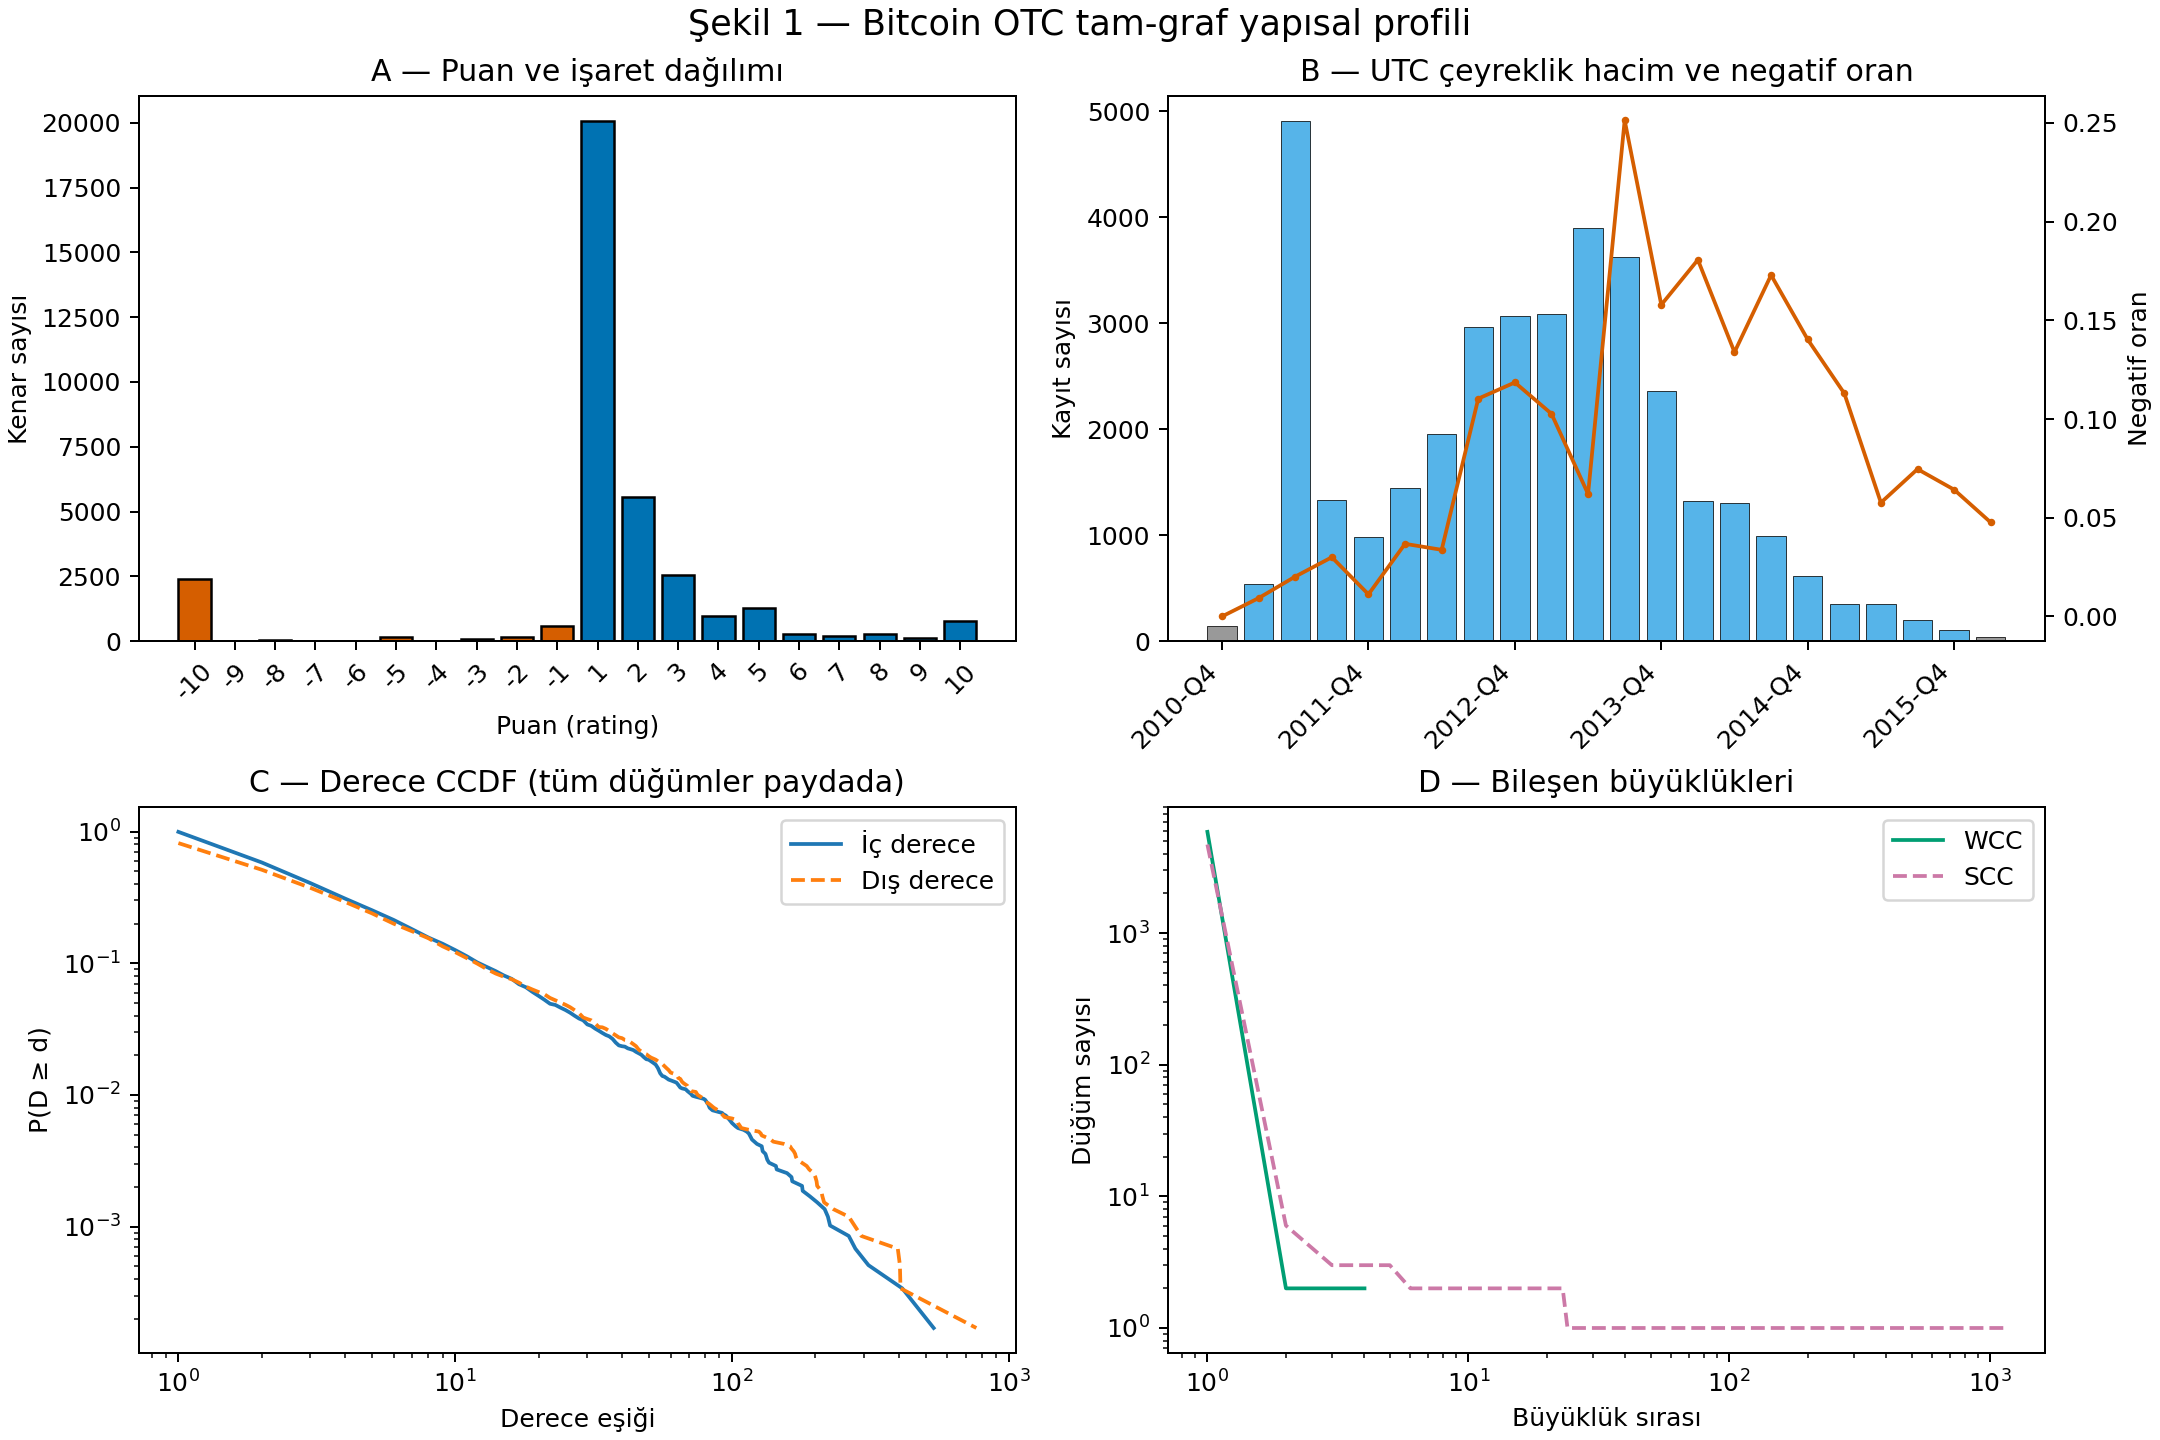

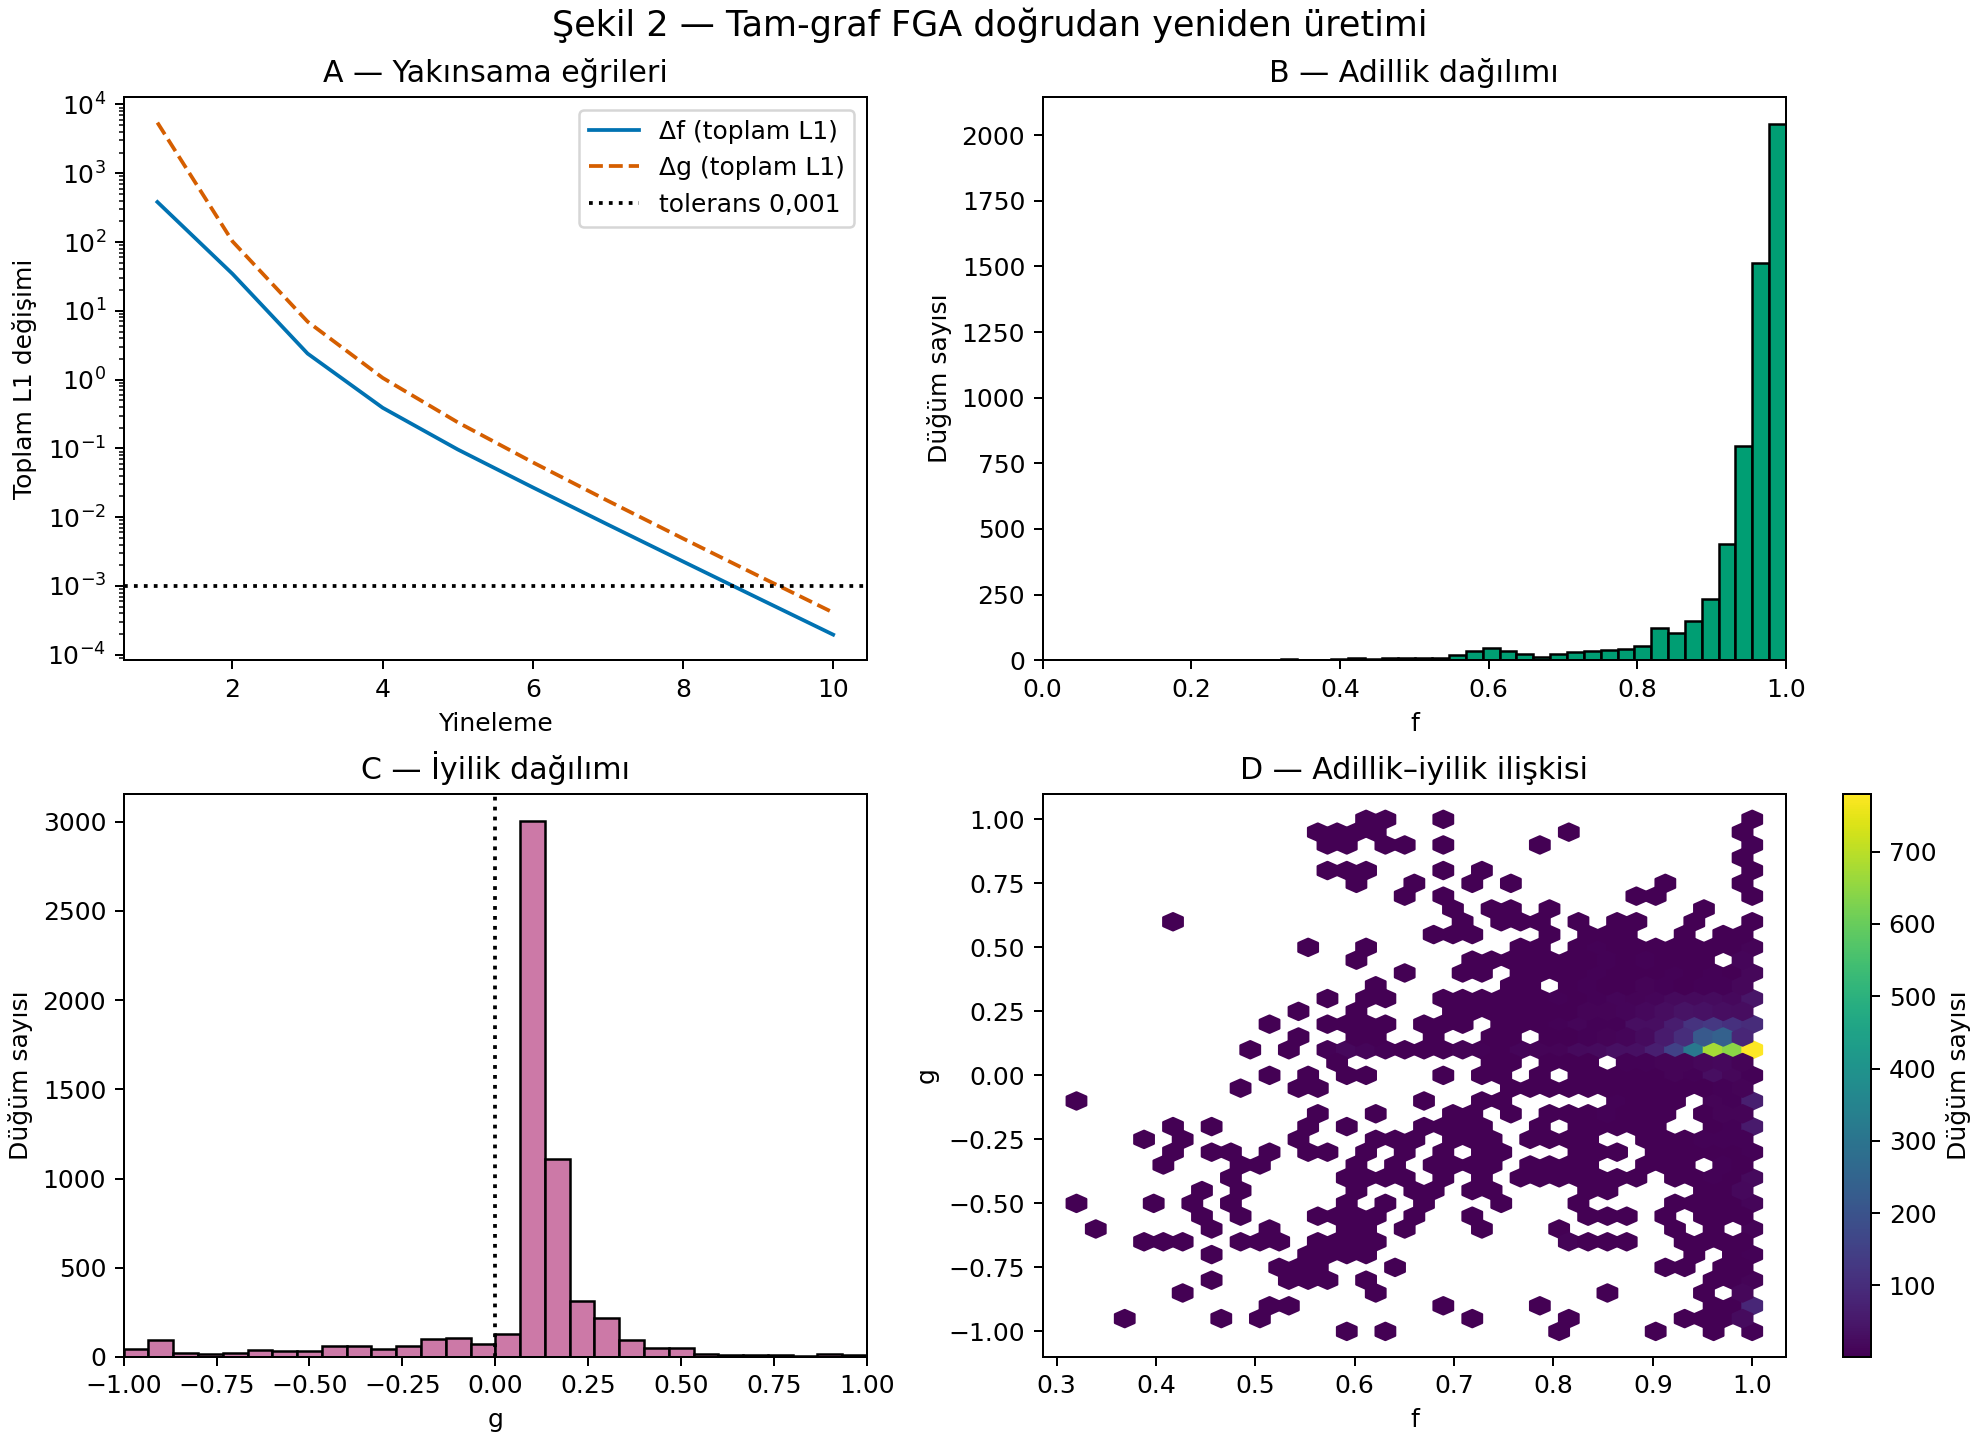

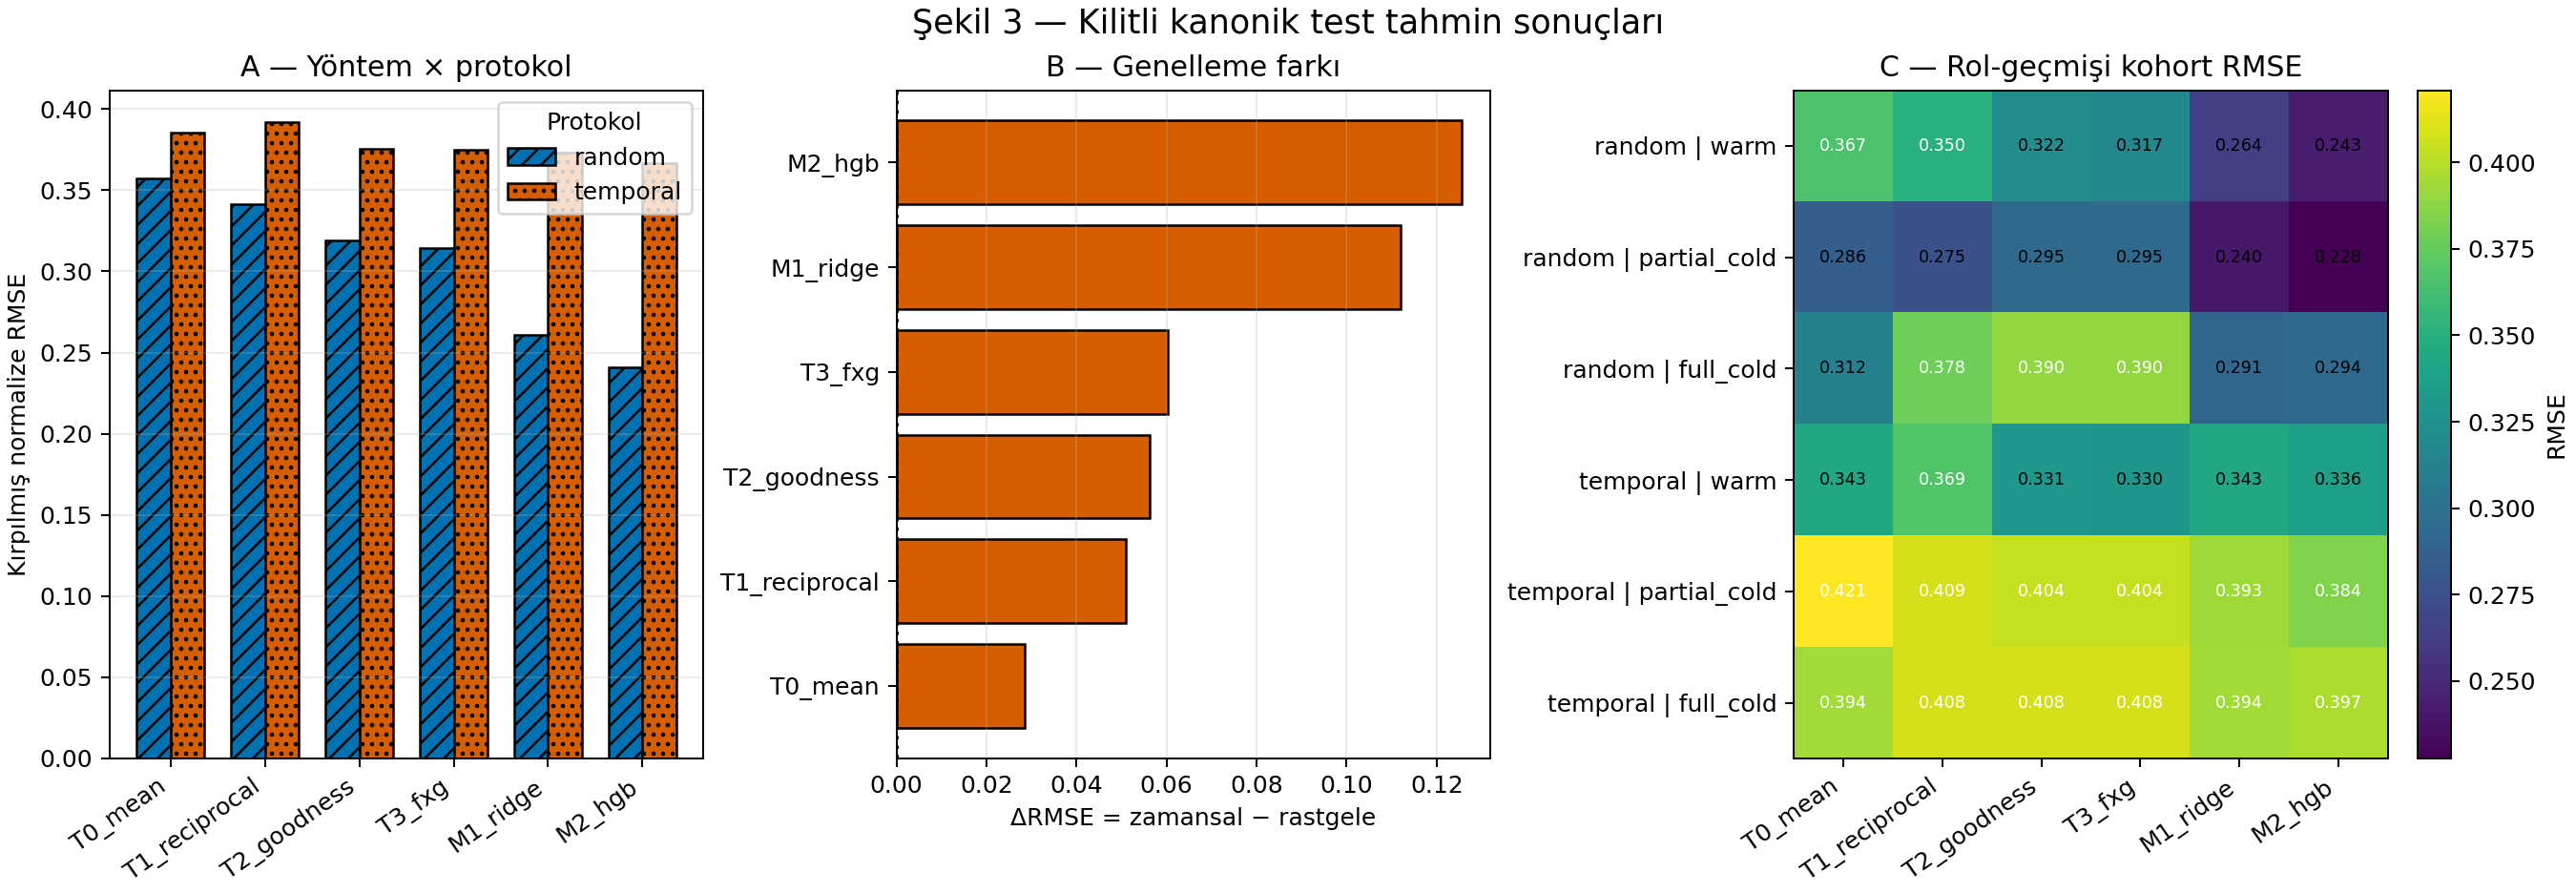

,metric,value,graph_view
0,valid_records,35592.000000,event_table
1,quarantine_records,0.000000,data_quality
2,nodes,5881.000000,directed_topology
3,directed_edges,35592.000000,directed_topology
4,directed_density,0.001029,directed_topology
5,positive_edges,32029.000000,signed_layers
6,negative_edges,3563.000000,signed_layers
7,reciprocity,0.792313,directed_topology
8,undirected_edges,21492.000000,simple_undirected_projection
9,average_clustering,0.177504,simple_undirected_projection


,experiment,protocol,split,method,cohort,support,support_ratio,rmse,mae,pearson,spearman,rmse_rating_scale,mae_rating_scale,balanced_accuracy,clip_rate,rmse_unclipped,mae_unclipped,feature_seconds,fit_seconds,prediction_seconds
0,E30_R_TEST,random,test,M2_hgb,all,7119,1.0,0.240971,0.127283,0.739190,0.584691,2.409709,1.272826,0.877186,0.011238,0.241104,0.127819,None,0.377355,0.015158
1,E30_R_TEST,random,test,M1_ridge,all,7119,1.0,0.260972,0.154407,0.683791,0.490923,2.609724,1.544074,0.871946,0.008569,0.262473,0.156257,None,0.020283,0.000672
2,E30_R_TEST,random,test,T3_fxg,all,7119,1.0,0.314620,0.182040,0.474664,0.297278,3.146205,1.820399,0.748806,0.000000,NaN,NaN,None,0.000000,NaN
3,E30_R_TEST,random,test,T2_goodness,all,7119,1.0,0.318986,0.182840,0.461378,0.297065,3.189858,1.828400,0.748806,0.000000,NaN,NaN,None,0.000000,NaN
4,E30_R_TEST,random,test,T1_reciprocal,all,7119,1.0,0.341166,0.171218,0.374887,0.362965,3.411659,1.712179,0.567515,0.000000,NaN,NaN,None,0.000000,NaN
5,E30_R_TEST,random,test,T0_mean,all,7119,1.0,0.357176,0.173150,NaN,NaN,3.571765,1.731498,0.500000,0.000000,NaN,NaN,None,0.000000,NaN
6,E40_T_TEST,temporal,test,M2_hgb,all,7119,1.0,0.366635,0.223308,0.333706,0.265022,3.666352,2.233077,0.670462,0.000562,0.366643,0.223346,None,0.363459,0.017354
7,E40_T_TEST,temporal,test,M1_ridge,all,7119,1.0,0.372972,0.229494,0.265340,0.225735,3.729716,2.294938,0.664072,0.000140,0.373018,0.229564,None,0.021340,0.000712
8,E40_T_TEST,temporal,test,T3_fxg,all,7119,1.0,0.374897,0.228698,0.223233,0.207971,3.748969,2.286977,0.525946,0.000000,NaN,NaN,None,0.000000,NaN
9,E40_T_TEST,temporal,test,T2_goodness,all,7119,1.0,0.375248,0.229106,0.223952,0.209684,3.752482,2.291063,0.525946,0.000000,NaN,NaN,None,0.000000,NaN


In [19]:
# Bu hücre, raporda kullanılan gerçek şekilleri ve özet tabloları not defterinde gösterir.
figure_paths = [
    "artifacts/standard/figures/figure_1_structural_profile.png",
    "artifacts/standard/figures/figure_2_full_fga.png",
]
if TEST_ACCESS_ALLOWED:
    figure_paths.append("artifacts/standard/figures/figure_3_prediction_results.png")
for relative in figure_paths:
    assert project_path(relative).is_file(), relative
    display(Image(filename=str(project_path(relative)), width=780))

# Test yetkisi yoksa yalnız doğrulama tablosu, varsa kilitli test sonuçlarıyla birleşik tablo gösterilir.
table_1 = pd.read_parquet(project_path("artifacts/standard/tables/table_1_data_quality_graph_summary.parquet"))
display(table_1)
if TEST_ACCESS_ALLOWED and project_path("artifacts/standard/tables/table_2_validation_test_metrics.parquet").is_file():
    display(pd.read_parquet(project_path("artifacts/standard/tables/table_2_validation_test_metrics.parquet")))
elif project_path("artifacts/standard/tables/table_2_validation_metrics.parquet").is_file():
    display(pd.read_parquet(project_path("artifacts/standard/tables/table_2_validation_metrics.parquet")))


## 16. Canlı gösterim hücreleri

Bu hücreler 4–5 dakikalık gösterim için küçüktür; tam model uydurması veya ağır
özellik üretimi başlatmaz. Kanonik sayım, iki adımlı sentetik FGA, bir aday
özellik alt kümesi ve önceden üretilmiş metrik/fark tablosu gösterilir.


In [20]:
# Canlı gösterim 1: doğrulanmış kanonik sayımlar ve güvenli eğitim/doğrulama örnekleri.
demo_labels = validation_labels["random_train"].head(3)
display(pd.DataFrame({
    "kanıt": ["kayıt", "düğüm", "pozitif", "negatif", "karantina"],
    "değer": [35_592, 5_881, 32_029, 3_563, 0],
}))
display(demo_labels)

# Canlı gösterim 2: A→B=+1, C→B=-1 yapay FGA sabit noktası.
demo_edges = pd.DataFrame({
    "source_id_raw": [1, 3], "target_id_raw": [2, 2],
    "weight_norm": [1.0, -1.0],
})
demo_snapshot = ReferenceSnapshot.from_frame(demo_edges, all_nodes=[1, 2, 3])
demo_fga = compute_fga(demo_snapshot)
demo_scores = pd.DataFrame({
    "node": demo_fga.node_ids, "fairness": demo_fga.fairness, "goodness": demo_fga.goodness,
})
display(demo_scores)

# Canlı gösterim 3: bir aday kenarın anlamlı özellik alt kümesi.
demo_feature = validation_features["random_validation"].loc[:, [
    "row_id", "f_source", "g_target", "fxg", "reciprocal_exists",
    "reciprocal_rating", "log_two_path_count", "source_has_out_history",
    "target_has_in_history",
]].head(1)
display(demo_feature)

# Canlı gösterim 4: önceden hesaplanmış metrik ve genelleme farkı; model uydurma çağrısı yoktur.
if TEST_ACCESS_ALLOWED and project_path("artifacts/standard/metrics/g9_generalization_gaps.parquet").is_file():
    display(pd.read_parquet(project_path("artifacts/standard/metrics/g9_generalization_gaps.parquet")))
else:
    display(pd.read_parquet(project_path("artifacts/standard/metrics/g7_validation_baseline_metrics.parquet")).query("cohort == 'all'"))


,kanıt,değer
0,kayıt,35592
1,düğüm,5881
2,pozitif,32029
3,negatif,3563
4,karantina,0


,row_id,weight_norm
0,0,0.4
1,1,0.2
2,2,0.1


,node,fairness,goodness
0,1,0.5,0.0
1,2,1.0,0.0
2,3,0.5,0.0


,row_id,f_source,g_target,fxg,reciprocal_exists,reciprocal_rating,log_two_path_count,source_has_out_history,target_has_in_history
0,4,0.952042,0.0,0.0,0.0,0.0,0.0,1.0,0.0


,method,random_rmse,temporal_rmse,delta_rmse,percent_delta_rmse
0,T0_mean,0.357176,0.385728,0.028551,7.993552
1,T1_reciprocal,0.341166,0.392040,0.050875,14.911986
2,T2_goodness,0.318986,0.375248,0.056262,17.637915
3,T3_fxg,0.314620,0.374897,0.060276,19.158468
4,M1_ridge,0.260972,0.372972,0.111999,42.916133
5,M2_hgb,0.240971,0.366635,0.125664,52.149149


In [21]:
# Son hücre, çalışmanın kipini ve tamamlanan denetimleri makinece okunabilir bir sonuçta özetler.
if MODE == "pretest":
    NOTEBOOK_RESULT = {
        "status": "passed",
        "mode": MODE,
        "safe_direct_run": SAFE_DIRECT_RUN,
        "validation_fit_count": len(validation_fit_evidence),
        "test_cells_executed": 0,
        "test_access": "not_accessed",
        "test_section": globals().get(
            "TEST_SECTION_RESULT",
            {"status": "physically_skipped_by_pretest_executor"},
        ),
        "feature_tables_validated": len(validation_features),
        "duration_seconds": time.perf_counter() - RUN_STARTED,
    }
    result_path = project_path(
        "artifacts/standard/g8/notebook_internal_pretest.json"
        if ORCHESTRATED_RUN
        else "artifacts/standard/notebook_rebuild/direct_pretest_result.json"
    )
else:
    NOTEBOOK_RESULT = {
        **VERIFICATION_RESULT,
        "mode": MODE,
        "safe_direct_run": SAFE_DIRECT_RUN,
        "test_access": "verification_rerun",
        "duration_seconds": time.perf_counter() - RUN_STARTED,
    }
    result_path = project_path(
        "artifacts/standard/g10/notebook_verification_results.json"
        if ORCHESTRATED_RUN
        else "artifacts/standard/notebook_rebuild/direct_verification_result.json"
    )

# Yeniden üretilen ve kullanılan dosyalar, teslimin izlenebilirliği için ayrı bir kayıtta listelenir.
rebuild_manifest = {
    "status": "passed" if NOTEBOOK_RESULT["status"] == "passed" else "rebuild_only",
    "mode": MODE,
    "safe_direct_run": SAFE_DIRECT_RUN,
    "canonical_csv_sha256": CSV_DATA_SHA256,
    "reports_found": sorted(gate_reports),
    "reports_missing": sorted(set(GATE_REPORT_PATHS) - set(gate_reports)),
    "generated_artifacts": sorted(set(REBUILT_ARTIFACTS)),
    "reused_artifacts": sorted(set(REUSED_ARTIFACTS)),
    "validation_supervised_fits": len(validation_fit_evidence),
    "final_supervised_fits": len(globals().get("final_fit_evidence", [])),
    "test_access_allowed": TEST_ACCESS_ALLOWED,
    "notebook_result_status": NOTEBOOK_RESULT["status"],
}
rebuild_manifest_path = project_path(
    "artifacts/standard/notebook_rebuild/rebuild_manifest.json"
)
# Sonuç dosyaları güvenli biçimde yazılır ve kısa özet ekrana basılır.
atomic_write_json(rebuild_manifest_path, rebuild_manifest)
atomic_write_json(result_path, NOTEBOOK_RESULT)
print(json.dumps(NOTEBOOK_RESULT, ensure_ascii=False, indent=2))


{
  "status": "passed",
  "canonical_evidence_available": true,
  "missing_canonical_evidence": [],
  "comparison_count": 4,
  "comparisons": [
    {
      "name": "E30_R_TEST_predictions",
      "rows": 42714,
      "max_abs_float_difference": 0.0,
      "status": "passed"
    },
    {
      "name": "E40_T_TEST_predictions",
      "rows": 42714,
      "max_abs_float_difference": 0.0,
      "status": "passed"
    },
    {
      "name": "g9_test_metrics",
      "rows": 72,
      "max_abs_float_difference": 0.0,
      "status": "passed"
    },
    {
      "name": "g9_generalization_gaps",
      "rows": 6,
      "max_abs_float_difference": 0.0,
      "status": "passed"
    }
  ],
  "validation_fits": 4,
  "final_fits": 4,
  "verification_fit_count": 8,
  "test_prediction_rows": 85428,
  "test_metric_rows": 72,
  "max_abs_float_difference": 0.0,
  "rtol": 1e-12,
  "atol": 1e-12,
  "mode": "verification_rerun",
  "safe_direct_run": false,
  "test_access": "verification_rerun",
  "duration_s